# Unified Analysis Notebook

This notebook orchestrates compute-only pipeline modules in `analysis_pipeline`.
Heavy computations live in `.py` files; this notebook focuses on configuration, execution, validation, and plotting.

## 1. Set Up Environment and Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis_pipeline.config import load_analysis_config, merge_overrides
from analysis_pipeline.comparison import (
    ComparisonSpec,
    apply_common_limits,
    build_comparison_specs,
    comparison_export_paths,
    comparison_output_dir,
    comparison_palette,
    comparison_style_context,
    shared_axis_limit,
    ATP_COMPARISON_COLORS,
    PRC_COMPARISON_COLORS,
 )
from analysis_pipeline.pipeline import run_bead_core, run_autocorr_core
from tomsUtilities import tum_colors

plt.style.use('./science.mplstyle.txt')
plt.style.use('dark_background')
pd.set_option('display.max_columns', 200)

ROOT = Path('.')
print('Workspace:', ROOT.resolve())

Workspace: /Users/tom/Uni_local/master_local/analysis


## 2. Define Project Configuration

In [16]:
config_path = ROOT / 'config' / 'analysis_default.yaml'
base_config = load_analysis_config(str(config_path))

# Notebook overrides for rapid iteration.
quick_test_mode = False
quick_test_frames = 10

overrides = {
    'dataset': {
        'dataset_id': 'AMF_106_002__C640_C470',
        'base_dir': '/Volumes/Tom_Data',
    },
    'runtime': {
        'skip_existing': not quick_test_mode,
        'verbose': True,
    },
    'beads': {
        'parallel_workers': 0,
        'angular_mode': False,
        # 'channel_to_use': 1,
    },
    'autocorr': {
        'parallel_workers': 0,
        # 'single_frame_3d': 0,
    },
    'image_corr': {
        'enabled': True,
        'channel': 0,
        'middle_z_for_2d': 'middle',
        'frame_step': 1,
        'lag_step': 1,
        'max_lag_frames': None,
    },
}

# Fast subset mode for parameter tuning before full runs.
if quick_test_mode:
    overrides.setdefault('dataset', {})['tstop'] = int(quick_test_frames)

pipeline_run_mode = 'test' if quick_test_mode else 'full'

config = merge_overrides(base_config, overrides)
config['beads']['compute_angular_speed'] = bool(config['beads'].get('angular_mode', False))

## 3. Load and Validate Input Data

In [17]:
from analysis_pipeline.io_dataset import load_dataset_state

dataset_id = config['dataset']['dataset_id']
assert isinstance(dataset_id, str) and len(dataset_id) > 0, 'dataset.dataset_id must be non-empty'

base_dir = Path(config['dataset']['base_dir'])
if not base_dir.exists():
    print('Warning: base_dir does not exist locally:', base_dir)

data_state = load_dataset_state(config['dataset'], verbose=True)

print('Config validation passed')
print('Bead stage enabled:', bool(config['beads']['enabled']))
print('Angular mode enabled:', bool(config['beads'].get('angular_mode', False)))
print('Autocorr stage enabled:', bool(config['autocorr']['enabled']))
print('First data load mode:', 'test' if quick_test_mode else 'full')
print('Frame subset (tstop):', config['dataset'].get('tstop'))

Loaded dataset
  id: AMF_106_002__C640_C470
  name: AMF_106_002__C640_C470
  variation: -
  base_dir: /Volumes/Tom_Data
  shape (T,C,Z,Y,X): (164, 2, 27, 2818, 2829)
  chunks: (1, 1, 27, 2818, 2829)
  size_gb: 134.66
  channels: 2
  px_per_micron: 3.846
  px_per_micron_z: 0.6667
  fps: 0.04068
  mask channel loaded: False
Config validation passed
Bead stage enabled: True
Angular mode enabled: False
Autocorr stage enabled: True
First data load mode: full
Frame subset (tstop): -1


## 4. Preprocess Data for Implementation

In [18]:
# Pipeline modules handle heavy preprocessing internally.
# This cell prepares notebook-level runtime toggles and expected output paths.

derived_dir = Path('data') / dataset_id / 'derived'
derived_dir.mkdir(parents=True, exist_ok=True)

expected_outputs = {
    'detections': derived_dir / 'beads_detections.parquet',
    'tracks': derived_dir / 'beads_tracks.parquet',
    'tracks_vel': derived_dir / 'beads_tracks_with_velocity.parquet',
    'tracks_ang': derived_dir / 'beads_tracks_with_angular_speed.parquet',
    'ac3d_single': derived_dir / 'autocorr_3d_single_frame.parquet',
    'ac3d_sampled': derived_dir / 'autocorr_3d_sampled.parquet',
    'ac2d_sampled': derived_dir / 'autocorr_2d_sampled.parquet',
    'ac2d_radial': derived_dir / 'autocorr_2d_radial_single.parquet',
    'image_corr': derived_dir / 'image_time_correlation_raw.parquet',
    'image_corr_fit': derived_dir / 'image_time_correlation_fit.parquet',
}

pd.DataFrame({'artifact': list(expected_outputs.keys()), 'path': [str(v) for v in expected_outputs.values()]})

,artifact,path
0,detections,data/AMF_106_002__C640_C470/derived/beads_dete...
1,tracks,data/AMF_106_002__C640_C470/derived/beads_trac...
2,tracks_vel,data/AMF_106_002__C640_C470/derived/beads_trac...
3,tracks_ang,data/AMF_106_002__C640_C470/derived/beads_trac...
4,ac3d_single,data/AMF_106_002__C640_C470/derived/autocorr_3...
5,ac3d_sampled,data/AMF_106_002__C640_C470/derived/autocorr_3...
6,ac2d_sampled,data/AMF_106_002__C640_C470/derived/autocorr_2...
7,ac2d_radial,data/AMF_106_002__C640_C470/derived/autocorr_2...
8,image_corr,data/AMF_106_002__C640_C470/derived/image_time...
9,image_corr_fit,data/AMF_106_002__C640_C470/derived/image_time...


## 5. Implement Core Functions

In [5]:
# Core reusable functions are implemented in analysis_pipeline/*.py.
# Here we add minimal notebook-side wrappers for convenience.

def summarize_track_table(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame({'metric': ['rows', 'particles'], 'value': [0, 0]})
    n_particles = int(df['particle'].nunique()) if 'particle' in df.columns else 0
    return pd.DataFrame({'metric': ['rows', 'particles'], 'value': [int(len(df)), n_particles]})


def summarize_autocorr_table(df: pd.DataFrame, corr_col: str = 'corr') -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame({'metric': ['rows', 'finite_corr'], 'value': [0, 0]})
    finite_corr = int(np.isfinite(df[corr_col]).sum()) if corr_col in df.columns else 0
    return pd.DataFrame({'metric': ['rows', 'finite_corr'], 'value': [int(len(df)), finite_corr]})

print('Notebook helper functions ready')

Notebook helper functions ready


## 6. Assemble and Run Initial Pipeline

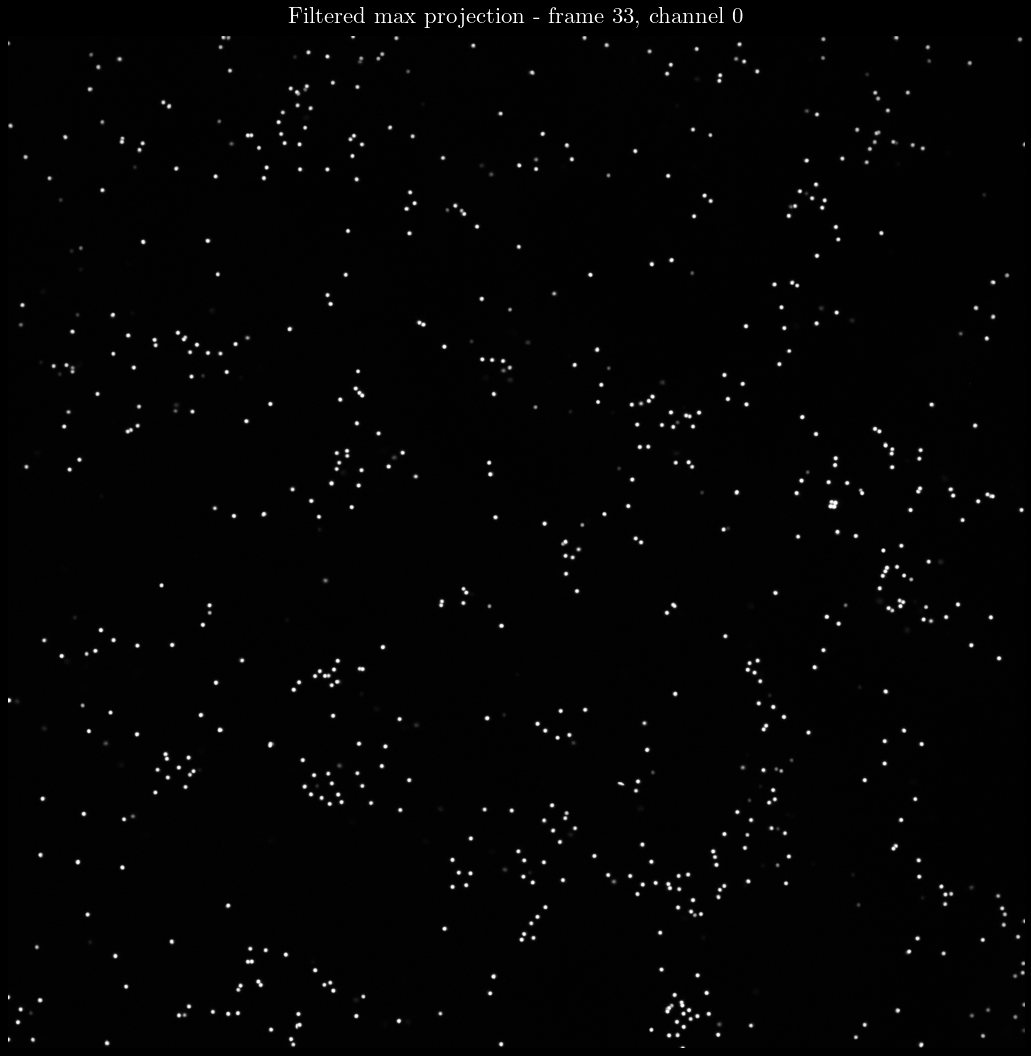

In [ ]:
frame_idx = 33
channel_idx = int(config.get('image_corr', {}).get('channel', 1))

frame = data_state['images'][frame_idx]
frame = np.asarray(frame.compute() if hasattr(frame, 'compute') else frame)

# Resolve channel/Z layout
if frame.ndim == 4:
    frame = frame[np.clip(channel_idx, 1, frame.shape[0] - 1)]
elif frame.ndim == 3 and frame.shape[0] <= 4 and frame.shape[-1] != frame.shape[-2]:
    frame = frame[np.clip(channel_idx, 1, frame.shape[0] - 1)]

# Max projection
if frame.ndim == 3:
    max_proj = frame.max(axis=0)
elif frame.ndim == 2:
    max_proj = frame
else:
    raise ValueError(f"Unexpected frame shape: {frame.shape}")

# Simple intensity filtering (robust contrast)
lo, hi = np.nanpercentile(max_proj, [1, 99.8])
filtered_proj = np.clip((max_proj - lo) / (hi - lo + 1e-12), 0, 1)

plt.figure(figsize=(7, 7), dpi=150)
plt.imshow(filtered_proj, cmap="gray")
plt.title(f"Filtered max projection - frame {frame_idx}, channel {channel_idx}")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
bead_out = None
autocorr_out = None
image_corr_out = None
image_corr_fit_out = None
state_for_autocorr = None

print('Pipeline execution mode:', 'test' if quick_test_mode else 'full')

if bool(config['beads']['enabled']):
    bead_out = run_bead_core(config)
    state_for_autocorr = bead_out['state'] if bead_out is not None else None

if bool(config['autocorr']['enabled']) and not bool(config['beads'].get('angular_mode', False)):
    autocorr_out = run_autocorr_core(config, state=state_for_autocorr)
elif bool(config['beads'].get('angular_mode', False)):
    print('Angular mode enabled: skipping autocorr stage')

if bool(config.get('image_corr', {}).get('enabled', True)):
    image_corr_out = run_image_correlation_core(config, state=state_for_autocorr)
    image_corr_fit_out = run_image_correlation_fit_core(
        config,
        state=state_for_autocorr,
        raw_df=image_corr_out.get('image_corr_df') if image_corr_out is not None else None,
    )
elif 'image_corr' in config:
    print('Image correlation stage disabled: skipping time-correlation compute and fit')

print('Pipeline run complete')

Frame 221: 784 trajectories present.
trackpy link_df succeeded (strategy=auto, adaptive_stop=7.5 um)
Saved detections to data/AMF_107_002__C640_C470/derived/beads_detections.parquet | rows=153905
Saved tracks to data/AMF_107_002__C640_C470/derived/beads_tracks.parquet | rows=152695
FOV shape yx=(2818,2829)
Saved tracks+velocity to data/AMF_107_002__C640_C470/derived/beads_tracks_with_velocity.parquet | rows=152695
Saved single-frame 3D autocorr to data/AMF_107_002__C640_C470/derived/autocorr_3d_single_frame.parquet
Saved sampled 3D autocorr to data/AMF_107_002__C640_C470/derived/autocorr_3d_sampled.parquet
Saved sampled 2D autocorr to data/AMF_107_002__C640_C470/derived/autocorr_2d_sampled.parquet
Saved radial 2D autocorr to data/AMF_107_002__C640_C470/derived/autocorr_2d_radial_single.parquet
Computing time correlation (frames=222, channel=0, z_mode=middle, dt=24.59 s)


compute lags: 100%|██████████| 222/222 [05:12<00:00,  1.41s/it]


Saved raw image-time correlation to data/AMF_107_002__C640_C470/derived/image_time_correlation_raw.parquet
Saved image-time correlation fit to data/AMF_107_002__C640_C470/derived/image_time_correlation_fit.parquet
Fit summary: tau_str=865 s beta=0.2631 R^2=0.8697
Pipeline run complete


## 7. Compute Evaluation Metrics

In [22]:
# Reload artifacts from disk to keep notebook state independent of in-memory objects.
tracks_vel_df = pd.read_parquet(expected_outputs['tracks_vel']) if expected_outputs['tracks_vel'].exists() else pd.DataFrame()
ac3d_sampled_df = pd.read_parquet(expected_outputs['ac3d_sampled']) if expected_outputs['ac3d_sampled'].exists() else pd.DataFrame()
ac2d_sampled_df = pd.read_parquet(expected_outputs['ac2d_sampled']) if expected_outputs['ac2d_sampled'].exists() else pd.DataFrame()

metrics_rows = []
metrics_rows.append({'metric': 'tracks_vel_rows', 'value': int(len(tracks_vel_df))})
metrics_rows.append({'metric': 'tracks_vel_particles', 'value': int(tracks_vel_df['particle'].nunique()) if 'particle' in tracks_vel_df.columns and len(tracks_vel_df) else 0})
metrics_rows.append({'metric': 'tracks_vel_speed_finite', 'value': int(np.isfinite(tracks_vel_df['speed_um_s']).sum()) if 'speed_um_s' in tracks_vel_df.columns and len(tracks_vel_df) else 0})
metrics_rows.append({'metric': 'ac3d_sampled_rows', 'value': int(len(ac3d_sampled_df))})
metrics_rows.append({'metric': 'ac3d_finite_xi', 'value': int(np.isfinite(ac3d_sampled_df['xi_um']).sum()) if 'xi_um' in ac3d_sampled_df.columns and len(ac3d_sampled_df) else 0})
metrics_rows.append({'metric': 'ac2d_sampled_rows', 'value': int(len(ac2d_sampled_df))})
metrics_rows.append({'metric': 'ac2d_finite_xi', 'value': int(np.isfinite(ac2d_sampled_df['xi_um']).sum()) if 'xi_um' in ac2d_sampled_df.columns and len(ac2d_sampled_df) else 0})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,metric,value
0,tracks_vel_rows,89414
1,tracks_vel_particles,2176
2,tracks_vel_speed_finite,87238
3,ac3d_sampled_rows,1200
4,ac3d_finite_xi,1200
5,ac2d_sampled_rows,2400
6,ac2d_finite_xi,2400


## 9. Plot Results for Quick Validation

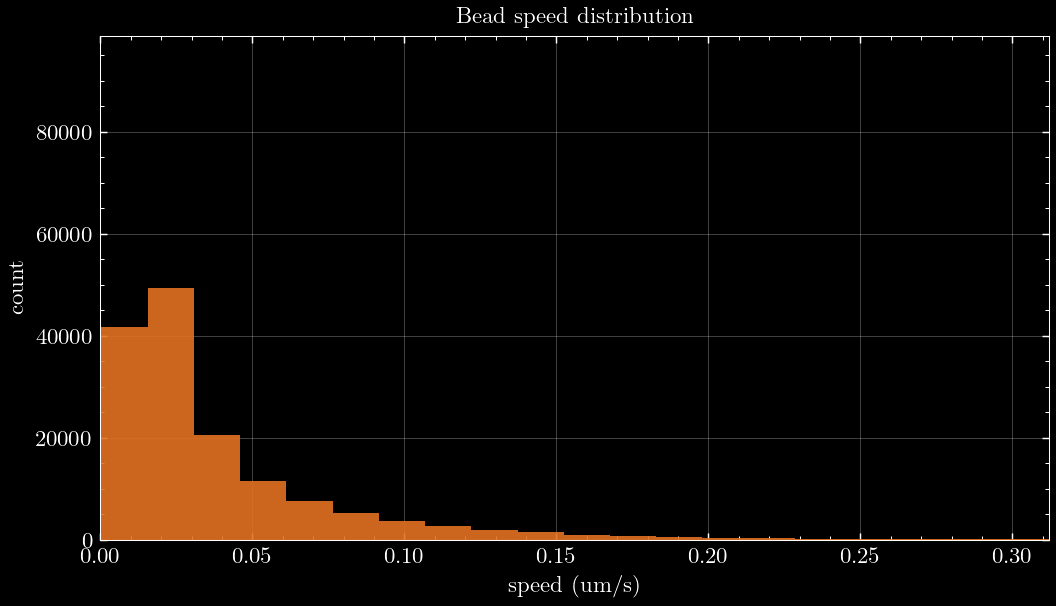

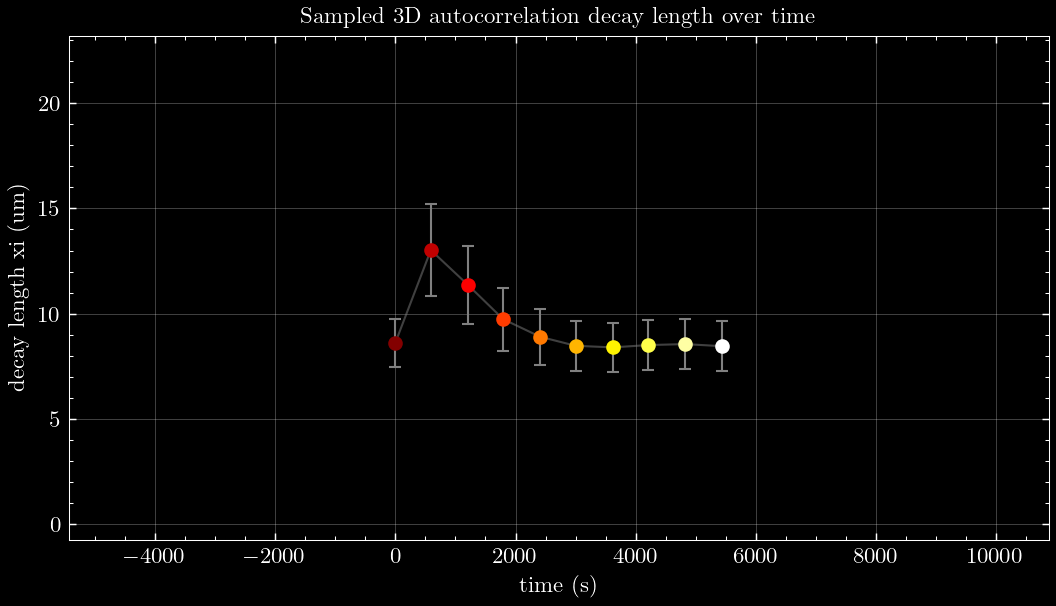

In [ ]:
plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
plot_dir.mkdir(parents=True, exist_ok=True)


def _save_dual_pdf(fig, stem: str):
    # Save dark version exactly as rendered in notebook.
    out_dark = plot_dir / f"{stem}_black.pdf"
    fig.savefig(out_dark, dpi=150, bbox_inches='tight')


def _white_style_context():
    return plt.style.context([
        './science.mplstyle.txt',
        {
            'figure.facecolor': 'white',
            'axes.facecolor': 'white',
            'savefig.facecolor': 'white',
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'axes.edgecolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'grid.color': '0.8',
            'legend.edgecolor': '0.5',
        },
    ])


def _save_dual_replot(stem: str, plot_fn):
    # Re-plot with the science style on a white background for paper-ready output.
    with _white_style_context():
        fig_w, ax_w = plt.subplots(figsize=(7, 4), dpi=150)
        plot_fn(ax_w)
        fig_w.savefig(plot_dir / f"{stem}_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w)


def _ordered_hot_colors(n: int):
    if n <= 1:
        return np.array([tum_colors[0]])
    cmap = plt.get_cmap('hot')
    values = np.linspace(0.18, 1.0, n)
    return np.array([cmap(v) for v in values])


def _legend_scale(fig):
    width, height = fig.get_size_inches()
    base = min(width, height)
    fontsize = max(10, min(16, int(round(base * 1.4))))
    return {
        'fontsize': fontsize,
        'title_fontsize': fontsize,
        'handlelength': 2.2,
        'labelspacing': 0.6,
        'borderpad': 0.8,
        'handletextpad': 0.7,
        'columnspacing': 1.2,
    }


# Plot A: speed distribution
if len(tracks_vel_df) and 'speed_um_s' in tracks_vel_df.columns:
    speed_vals = tracks_vel_df['speed_um_s'].to_numpy(dtype=float)
    speed_vals = speed_vals[np.isfinite(speed_vals)]
else:
    speed_vals = np.array([])

if speed_vals.size > 0:
    fig_speed, ax_speed = plt.subplots(figsize=(7, 4), dpi=150)
    ax_speed.hist(speed_vals, bins=40, color=tum_colors[0], alpha=0.9)
    ax_speed.set_xlabel('speed (um/s)')
    ax_speed.set_ylabel('count')
    ax_speed.set_title('Bead speed distribution')
    ax_speed.grid(True, alpha=0.25)
    ax_speed.set_xlim(left=0, right=np.percentile(speed_vals, 99.5) * 1.2)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_speed, f"{dataset_id}_speed_distribution")

    def _speed_plot_white(ax):
        ax.hist(speed_vals, bins=40, color=tum_colors[0], alpha=0.9)
        ax.set_xlabel('speed (um/s)')
        ax.set_ylabel('count')
        ax.set_title('Bead speed distribution')
        ax.grid(True, alpha=0.25)
        ax.set_xlim(left=0, right=np.percentile(speed_vals, 99.5) * 1.2)
    _save_dual_replot(f"{dataset_id}_speed_distribution", _speed_plot_white)
else:
    print('No finite speed values to plot')


# Plot B: sampled 3D decay length vs time (parity with old notebooks)
if len(ac3d_sampled_df) and {'time_s', 'xi_um'}.issubset(ac3d_sampled_df.columns):
    xi_3d = (
        ac3d_sampled_df[['time_s', 'frame', 'xi_um', 'xi_err_um']]
        .drop_duplicates(subset=['frame'])
        .sort_values('time_s')
    )
else:
    xi_3d = pd.DataFrame()

if len(xi_3d):
    x_3d = xi_3d['time_s'].to_numpy(dtype=float)
    y_3d = xi_3d['xi_um'].to_numpy(dtype=float)
    yerr_3d = xi_3d['xi_err_um'].to_numpy(dtype=float) if 'xi_err_um' in xi_3d.columns else None
    colors_3d = _ordered_hot_colors(len(x_3d))

    fig_decay3d, ax_decay3d = plt.subplots(figsize=(7, 4), dpi=150)
    for idx in range(len(x_3d)):
        ax_decay3d.errorbar(
            x_3d[idx],
            y_3d[idx],
            yerr=None if yerr_3d is None else yerr_3d[idx],
            fmt='o',
            color=colors_3d[idx],
            ecolor='gray',
            capsize=3,
        )
    ax_decay3d.plot(x_3d, y_3d, color='gray', alpha=0.5)
    ax_decay3d.set_xlabel('time (s)')
    ax_decay3d.set_ylabel('decay length xi (um)')
    ax_decay3d.set_title('Sampled 3D autocorrelation decay length over time')
    ax_decay3d.grid(True, alpha=0.25)
    # ax_decay3d.set_xlim(left=0)
    # ax_decay3d.set_ylim(0,y_3d.max() * 1.2)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_decay3d, f"{dataset_id}_ac3d_decay_over_time")

    def _decay3d_plot_white(ax):
        for idx in range(len(x_3d)):
            ax.errorbar(
                x_3d[idx],
                y_3d[idx],
                yerr=None if yerr_3d is None else yerr_3d[idx],
                fmt='o',
                color=colors_3d[idx],
                ecolor='gray',
                capsize=3,
            )
        ax.plot(x_3d, y_3d, color='gray', alpha=0.5)
        ax.set_xlabel('time (s)')
        ax.set_ylabel('decay length xi (um)')
        ax.set_title('Sampled 3D autocorrelation decay length over time')
        ax.grid(True, alpha=0.25)

    _save_dual_replot(f"{dataset_id}_ac3d_decay_over_time", _decay3d_plot_white)
else:
    print('No sampled 3D decay data to plot')

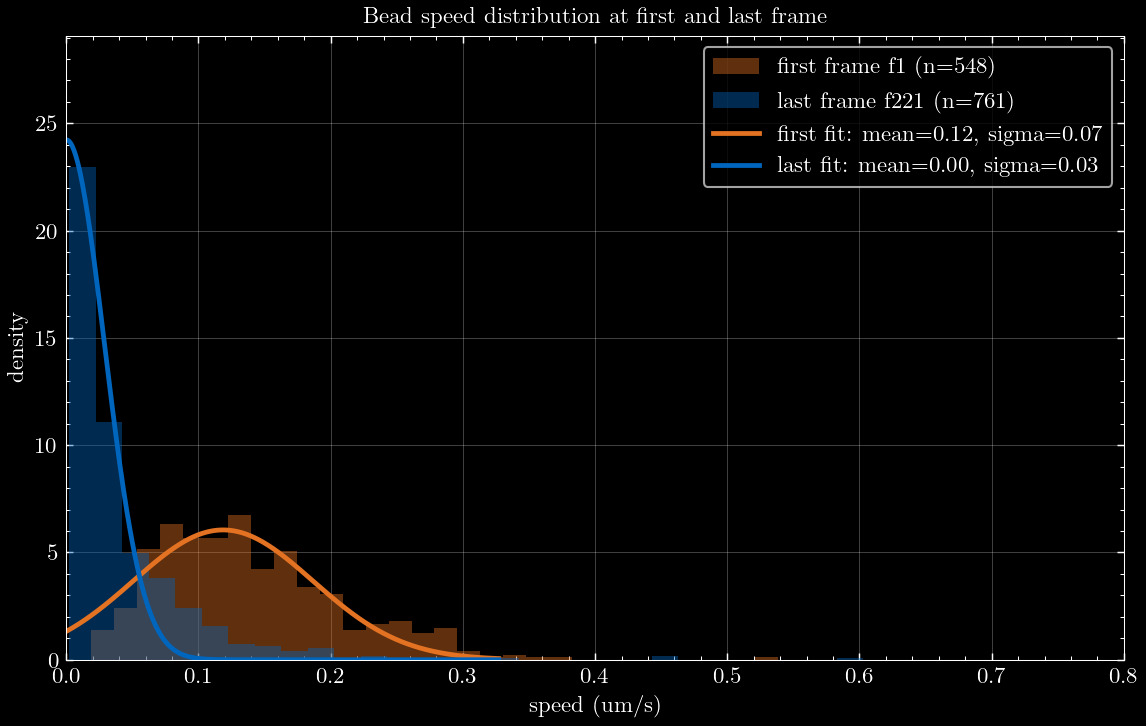

Saved speed summary to plots/AMF_107_002__C640_C470/AMF_107_002__C640_C470_speed_distribution_first_last_summary.parquet
Saved speed distribution plot to plots/AMF_107_002__C640_C470/AMF_107_002__C640_C470_speed_distribution_first_last_gaussian_black.pdf


In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import norm

# Speed distribution at the first and last frame with Gaussian fits.
if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0:
    print('No velocity tracks available for first/last speed distributions')
elif not {'frame', 'speed_um_s'}.issubset(tracks_vel_df.columns):
    print('Velocity table does not contain the required frame and speed_um_s columns')
else:
    speed_df = tracks_vel_df[['frame', 'speed_um_s']].copy()
    speed_df = speed_df[np.isfinite(speed_df['frame']) & np.isfinite(speed_df['speed_um_s'])].copy()
    speed_df['frame'] = speed_df['frame'].astype(int)

    frame_values = sorted(speed_df['frame'].unique().tolist())
    if not frame_values:
        print('No finite frame values available for speed distributions')
    else:
        first_frame = int(frame_values[0])
        last_frame = int(frame_values[-1])

        first_speeds = speed_df.loc[speed_df['frame'] == first_frame, 'speed_um_s'].to_numpy(dtype=float)
        last_speeds = speed_df.loc[speed_df['frame'] == last_frame, 'speed_um_s'].to_numpy(dtype=float)
        first_speeds = first_speeds[np.isfinite(first_speeds)]
        last_speeds = last_speeds[np.isfinite(last_speeds)]

        if first_speeds.size == 0 or last_speeds.size == 0:
            print('No finite speeds found in the first or last frame')
        else:
            def _gaussian(x, amplitude, mean, sigma):
                return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

            def _fit_gaussian(values: np.ndarray):
                values = np.asarray(values, dtype=float)
                values = values[np.isfinite(values)]
                if values.size < 5:
                    return {'amplitude': np.nan, 'mean': np.nan, 'sigma': np.nan}
                mean_guess, sigma_guess = norm.fit(values)
                sigma_guess = max(float(sigma_guess), 1e-3)
                counts, edges = np.histogram(values, bins=30, density=True)
                centers = 0.5 * (edges[:-1] + edges[1:])
                valid = np.isfinite(counts) & np.isfinite(centers)
                if int(valid.sum()) < 3:
                    return {'amplitude': np.nan, 'mean': float(mean_guess), 'sigma': float(sigma_guess)}
                amp_guess = float(np.nanmax(counts))
                try:
                    popt, _ = curve_fit(
                        _gaussian,
                        centers[valid],
                        counts[valid],
                        p0=[amp_guess, mean_guess, sigma_guess],
                        bounds=([0.0, 0.0, 1e-3], [np.inf, np.inf, np.inf]),
                        maxfev=10000,
                    )
                    return {'amplitude': float(popt[0]), 'mean': float(popt[1]), 'sigma': float(popt[2])}
                except Exception:
                    return {'amplitude': float(amp_guess), 'mean': float(mean_guess), 'sigma': float(sigma_guess)}

            first_fit = _fit_gaussian(first_speeds)
            last_fit = _fit_gaussian(last_speeds)

            first_max = float(np.nanpercentile(first_speeds, 99)) if first_speeds.size else 0.0
            last_max = float(np.nanpercentile(last_speeds, 99)) if last_speeds.size else 0.0
            x_max = max(first_max, last_max)
            x_grid = np.linspace(0.0, x_max * 1.05 if x_max > 0 else 1.0, 500)

            speed_plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
            speed_plot_dir.mkdir(parents=True, exist_ok=True)

            fig_speed_cmp, ax_speed_cmp = plt.subplots(figsize=(7.6, 4.8), dpi=150)
            ax_speed_cmp.hist(first_speeds, bins=30, density=True, alpha=0.42, color=tum_colors[0], label=f'first frame f{first_frame} (n={len(first_speeds)})')
            ax_speed_cmp.hist(last_speeds, bins=30, density=True, alpha=0.42, color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', label=f'last frame f{last_frame} (n={len(last_speeds)})')
            ax_speed_cmp.plot(x_grid, _gaussian(x_grid, first_fit['amplitude'], first_fit['mean'], first_fit['sigma']), color=tum_colors[0], lw=2.3, label=f'first fit: mean={first_fit["mean"]:.2f}, sigma={first_fit["sigma"]:.2f}')
            ax_speed_cmp.plot(x_grid, _gaussian(x_grid, last_fit['amplitude'], last_fit['mean'], last_fit['sigma']), color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', lw=2.3, label=f'last fit: mean={last_fit["mean"]:.2f}, sigma={last_fit["sigma"]:.2f}')
            ax_speed_cmp.set_xlabel('speed (um/s)')
            ax_speed_cmp.set_ylabel('density')
            ax_speed_cmp.set_title('Bead speed distribution at first and last frame')
            ax_speed_cmp.set_xlim(0.0, 0.8)
            ax_speed_cmp.set_ylim(0.0, _gaussian(x_grid, last_fit['amplitude'], last_fit['mean'], last_fit['sigma']).max() * 1.2)
            ax_speed_cmp.grid(True, alpha=0.25)
            ax_speed_cmp.legend(frameon=True)
            plt.tight_layout()
            plt.show()

            speed_profile_path = speed_plot_dir / f'{dataset_id}_speed_distribution_first_last_summary.parquet'
            speed_summary_df = pd.DataFrame([
                {'frame': first_frame, 'label': 'first', 'count': int(first_speeds.size), 'mean_um_s': float(np.mean(first_speeds)), 'std_um_s': float(np.std(first_speeds, ddof=1)) if first_speeds.size > 1 else np.nan, 'fit_mean_um_s': first_fit['mean'], 'fit_sigma_um_s': first_fit['sigma']},
                {'frame': last_frame, 'label': 'last', 'count': int(last_speeds.size), 'mean_um_s': float(np.mean(last_speeds)), 'std_um_s': float(np.std(last_speeds, ddof=1)) if last_speeds.size > 1 else np.nan, 'fit_mean_um_s': last_fit['mean'], 'fit_sigma_um_s': last_fit['sigma']},
            ])
            speed_summary_df.to_parquet(speed_profile_path, index=False)
            print('Saved speed summary to', speed_profile_path)

            black_path = speed_plot_dir / f'{dataset_id}_speed_distribution_first_last_gaussian_black.pdf'
            fig_speed_cmp.savefig(black_path, dpi=150, bbox_inches='tight')

            white_path = speed_plot_dir / f'{dataset_id}_speed_distribution_first_last_gaussian_white.pdf'
            with plt.style.context([
                './science.mplstyle.txt',
                {
                    'figure.facecolor': 'white',
                    'axes.facecolor': 'white',
                    'savefig.facecolor': 'white',
                    'text.color': 'black',
                    'axes.labelcolor': 'black',
                    'axes.edgecolor': 'black',
                    'xtick.color': 'black',
                    'ytick.color': 'black',
                    'grid.color': '0.8',
                    'legend.edgecolor': '0.5',
                },
            ]):
                fig_white, ax_white = plt.subplots(figsize=(7.6, 4.8), dpi=150)
                ax_white.hist(first_speeds, bins=30, density=True, alpha=0.42, color=tum_colors[0], label=f'first frame f{first_frame} (n={len(first_speeds)})')
                ax_white.hist(last_speeds, bins=30, density=True, alpha=0.42, color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', label=f'last frame f{last_frame} (n={len(last_speeds)})')
                ax_white.plot(x_grid, _gaussian(x_grid, first_fit['amplitude'], first_fit['mean'], first_fit['sigma']), color=tum_colors[0], lw=2.3, label=f'first fit: mean={first_fit["mean"]:.2f}, sigma={first_fit["sigma"]:.2f}')
                ax_white.plot(x_grid, _gaussian(x_grid, last_fit['amplitude'], last_fit['mean'], last_fit['sigma']), color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', lw=2.3, label=f'last fit: mean={last_fit["mean"]:.2f}, sigma={last_fit["sigma"]:.2f}')
                ax_white.set_xlabel('speed (um/s)')
                ax_white.set_ylabel('density')
                ax_white.set_title('Bead speed distribution at first and last frame')
                ax_white.set_xlim(0.0, 0.8)
                ax_white.set_ylim(0.0, _gaussian(x_grid, last_fit['amplitude'], last_fit['mean'], last_fit['sigma']).max() * 1.2)
                ax_white.grid(True, alpha=0.25)
                ax_white.legend(frameon=True)
                plt.tight_layout()
                fig_white.savefig(white_path, dpi=150, bbox_inches='tight')
                plt.close(fig_white)

            print('Saved speed distribution plot to', black_path)


In [23]:
tracks_vel_df

,dataset_id,frame,z,y,x,area_vox,mean_intensity,max_intensity,bbox_ratio,inertia_ratio,x_um,y_um,z_um,t_s,particle,dframe,dt_s,dx_um,dy_um,dz_um,disp_um,vx_um_s,vy_um_s,vz_um_s,speed_um_s,ux,uy,uz
0,AMF_106_002__C640_C470,0,5.223118,9.168683,90.277554,1488,300.504032,1139.0,1.583333,1.785587,23.472164,2.383858,7.834677,0.000000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMF_106_002__C640_C470,1,5.448130,12.745942,80.674665,1417,313.378970,1207.0,1.545455,1.457488,20.975413,3.313945,8.172195,24.583693,0,1.0,24.583693,-2.496751,0.930087,0.337517,2.685656,-0.101561,0.037834,0.013729,0.109245,-0.929662,0.346317,0.125674
2,AMF_106_002__C640_C470,2,6.106176,16.103400,72.629424,1441,294.524636,1099.0,1.384615,1.452291,18.883650,4.186884,9.159264,49.167386,0,1.0,24.583693,-2.091763,0.872939,0.987070,2.472205,-0.085087,0.035509,0.040151,0.100563,-0.846112,0.353101,0.399267
3,AMF_106_002__C640_C470,3,6.477077,19.932665,63.864613,1396,288.454871,1008.0,1.583333,1.420100,16.604799,5.182493,9.715616,73.751079,0,1.0,24.583693,-2.278851,0.995609,0.556352,2.548318,-0.092698,0.040499,0.022631,0.103659,-0.894257,0.390692,0.218321
4,AMF_106_002__C640_C470,4,6.817293,26.724812,56.969173,1330,287.198496,972.0,1.727273,1.461442,14.811985,6.948451,10.225940,98.334772,0,1.0,24.583693,-1.792814,1.765958,0.510324,2.567727,-0.072927,0.071835,0.020759,0.104448,-0.698211,0.687752,0.198745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89409,AMF_106_002__C640_C470,161,25.833333,982.166667,472.500000,6,76.833333,83.0,1.500000,2.153846,122.850000,255.363333,38.750000,3957.974573,2638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89410,AMF_106_002__C640_C470,162,26.000000,980.444444,476.888889,9,72.888889,86.0,5.000000,5.009875,123.991111,254.915556,39.000000,3982.558266,2638,1.0,24.583693,1.141111,-0.447778,0.250000,1.251055,0.046417,-0.018214,0.010169,0.050890,0.912119,-0.357920,0.199831
89411,AMF_106_002__C640_C470,163,25.906977,976.976744,475.906977,43,80.116279,131.0,5.500000,3.073774,123.735814,254.013953,38.860465,4007.141959,2638,1.0,24.583693,-0.255297,-0.901602,-0.139535,0.947382,-0.010385,-0.036675,-0.005676,0.038537,-0.269476,-0.951677,-0.147285
89412,AMF_106_002__C640_C470,161,26.000000,1080.555556,1085.666667,9,74.444444,84.0,4.000000,5.354322,282.273333,280.944444,39.000000,3957.974573,2640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Sampling 30 frames for intensity coupling: [0, 5, 11, 16, 22, 28, 33, 39, 44, 50, 56, 61, 67, 73, 78, 84, 89, 95, 101, 106, 112, 118, 123, 129, 134, 140, 146, 151, 157, 163]


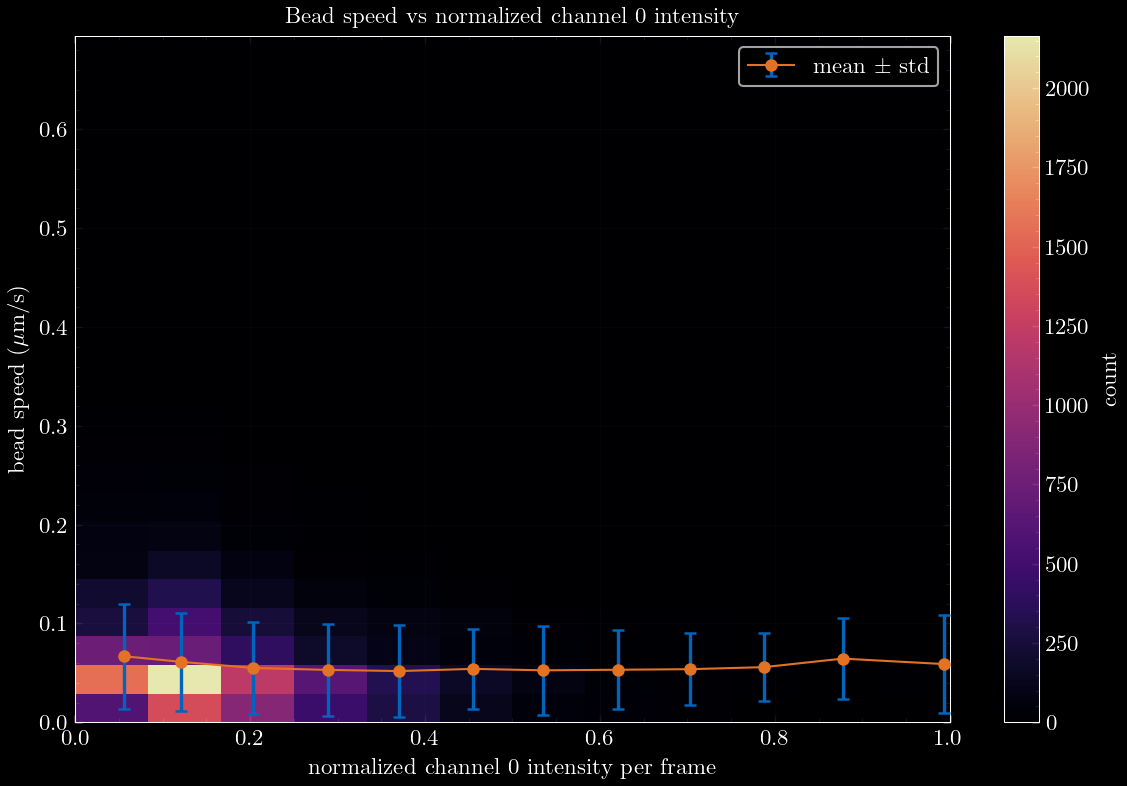

Saved bead-speed vs normalized channel 0 intensity plot to plots/AMF_106_002__C640_C470/AMF_106_002__C640_C470_bead_speed_vs_channel0_intensity_10frames_black.pdf
Saved white-background version to plots/AMF_106_002__C640_C470/AMF_106_002__C640_C470_bead_speed_vs_channel0_intensity_10frames_white.pdf
 intensity_mean  speed_mean  speed_std    n
       0.056151    0.066809   0.053024 3661
       0.121008    0.061163   0.049468 5467
       0.203525    0.054970   0.046560 3050
       0.288647    0.053007   0.046440 1503
       0.370778    0.051836   0.046950  864
       0.455254    0.054057   0.040713  437
       0.535304    0.052571   0.044886  206
       0.620468    0.053164   0.039763  104
       0.702774    0.053738   0.036202   72
       0.787583    0.055812   0.034150   31
       0.877525    0.064433   0.041083   23
       0.993439    0.058915   0.049972   35


In [25]:
# Bead speed vs channel 0 intensity over 10 frames
from pathlib import Path

if 'data_state' not in globals() or data_state is None:
    data_state = load_dataset_state(config['dataset'], verbose=True)

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0:
    print('No velocity tracks available for the intensity coupling plot')
elif 'frame' not in tracks_vel_df.columns:
    print('Velocity table does not contain a frame column')
elif 'speed_um_s' not in tracks_vel_df.columns and not {'vx_um_s', 'vy_um_s'}.issubset(tracks_vel_df.columns) and not {'vx', 'vy'}.issubset(tracks_vel_df.columns):
    print('Velocity table does not contain speed_um_s or vx/vy columns')
else:
    velocity_df = tracks_vel_df.copy()
    if 'speed_um_s' not in velocity_df.columns:
        if {'vx_um_s', 'vy_um_s'}.issubset(velocity_df.columns):
            velocity_df['speed_um_s'] = np.sqrt(velocity_df['vx_um_s'] ** 2 + velocity_df['vy_um_s'] ** 2)
        elif {'vx', 'vy'}.issubset(velocity_df.columns):
            velocity_df['speed_um_s'] = np.sqrt(velocity_df['vx'] ** 2 + velocity_df['vy'] ** 2)

    images = data_state['images']
    px_per_micron = float(data_state['calibration']['px_per_micron'])
    patch_radius_px = int(config['beads'].get('intensity_patch_radius_px', 2))
    patch_radius_px = max(1, patch_radius_px)
    intensity_bins = int(config['beads'].get('intensity_bins', 12))
    intensity_bins = max(4, intensity_bins)

    frame_values = np.array(sorted(velocity_df['frame'].dropna().astype(int).unique()), dtype=int)
    if frame_values.size == 0:
        print('No finite frame values available for intensity coupling')
    else:
        sample_count = min(30, frame_values.size)
        sample_indices = np.unique(np.linspace(0, frame_values.size - 1, num=sample_count, dtype=int))
        selected_frames = frame_values[sample_indices].tolist()
        print(f'Sampling {len(selected_frames)} frames for intensity coupling: {selected_frames}')

        if {'x_um', 'y_um'}.issubset(velocity_df.columns):
            x_col, y_col = 'x_um', 'y_um'
            position_scale = 1.0
        elif {'x', 'y'}.issubset(velocity_df.columns):
            x_col, y_col = 'x', 'y'
            position_scale = 1.0 / px_per_micron
        else:
            print('Velocity table does not contain x/y or x_um/y_um columns for intensity sampling')
            x_col = y_col = None
            position_scale = 1.0

        def _project_channel0_frame(frame_idx):
            if images.ndim >= 5:
                frame = images[frame_idx, 0]
            elif images.ndim == 4:
                frame = images[frame_idx]
            else:
                frame = images[frame_idx]
            frame = frame.compute() if hasattr(frame, 'compute') else frame
            frame = np.asarray(frame, dtype=float)
            if frame.ndim == 3:
                frame = frame.max(axis=0)
            if frame.ndim != 2:
                raise ValueError(f'Unexpected channel 0 frame shape: {frame.shape}')
            return frame

        def _local_mean_intensity(frame_2d, x_px, y_px, radius_px):
            x0 = int(np.round(x_px))
            y0 = int(np.round(y_px))
            x1 = max(0, x0 - radius_px)
            x2 = min(frame_2d.shape[1], x0 + radius_px + 1)
            y1 = max(0, y0 - radius_px)
            y2 = min(frame_2d.shape[0], y0 + radius_px + 1)
            if x1 >= x2 or y1 >= y2:
                return np.nan
            patch = frame_2d[y1:y2, x1:x2]
            return float(np.nanmean(patch)) if patch.size else np.nan

        if x_col is not None:
            obs_rows = []
            for frame_idx in selected_frames:
                frame_df = velocity_df.loc[velocity_df['frame'].astype(int) == int(frame_idx), [x_col, y_col, 'speed_um_s']].copy()
                if frame_df.empty:
                    continue

                frame_df = frame_df[np.isfinite(frame_df[x_col]) & np.isfinite(frame_df[y_col]) & np.isfinite(frame_df['speed_um_s'])].copy()
                if frame_df.empty:
                    continue

                frame_image = _project_channel0_frame(int(frame_idx))
                x_um = frame_df[x_col].to_numpy(dtype=float) * position_scale
                y_um = frame_df[y_col].to_numpy(dtype=float) * position_scale
                x_px = x_um * px_per_micron
                y_px = y_um * px_per_micron
                intensities = np.array([
                    _local_mean_intensity(frame_image, xi, yi, patch_radius_px)
                    for xi, yi in zip(x_px, y_px)
                ], dtype=float)
                speeds = frame_df['speed_um_s'].to_numpy(dtype=float)
                valid = np.isfinite(intensities) & np.isfinite(speeds)
                if not np.any(valid):
                    continue

                frame_intensities = intensities[valid]
                frame_speeds = speeds[valid]
                frame_min = float(np.nanmin(frame_intensities))
                frame_max = float(np.nanmax(frame_intensities))
                if not np.isfinite(frame_min) or not np.isfinite(frame_max):
                    continue
                if frame_max <= frame_min:
                    frame_norm = np.full_like(frame_intensities, 0.5, dtype=float)
                else:
                    frame_norm = (frame_intensities - frame_min) / (frame_max - frame_min)
                frame_norm = np.clip(frame_norm, 0.0, 1.0)

                obs_rows.append(pd.DataFrame({
                    'frame': int(frame_idx),
                    'intensity_raw': frame_intensities,
                    'intensity_norm': frame_norm,
                    'speed_um_s': frame_speeds,
                }))

            if not obs_rows:
                print('No valid bead/intensity observations found for the sampled frames')
            else:
                obs_df = pd.concat(obs_rows, ignore_index=True)
                bin_edges = np.linspace(0.0, 1.0, intensity_bins + 1)
                obs_df['intensity_bin'] = np.clip(np.digitize(obs_df['intensity_norm'], bin_edges) - 1, 0, intensity_bins - 1)
                summary_df = (
                    obs_df.groupby('intensity_bin', as_index=False)
                    .agg(
                        intensity_mean=('intensity_norm', 'mean'),
                        speed_mean=('speed_um_s', 'mean'),
                        speed_std=('speed_um_s', 'std'),
                        n=('speed_um_s', 'size'),
                    )
                    .sort_values('intensity_mean')
                    .reset_index(drop=True)
                )
                summary_df['speed_std'] = summary_df['speed_std'].fillna(0.0)

                speed_candidates = np.concatenate([
                    obs_df['speed_um_s'].to_numpy(dtype=float),
                    (summary_df['speed_mean'] + summary_df['speed_std']).to_numpy(dtype=float),
                ])
                speed_candidates = speed_candidates[np.isfinite(speed_candidates)]
                speed_upper = float(np.nanmax(speed_candidates)) if speed_candidates.size else 1.0
                speed_upper = max(speed_upper, 1e-6)
                speed_upper *= 1.15

                def _plot_intensity_speed(ax, show_title: bool = True):
                    hist = ax.hist2d(
                        obs_df['intensity_norm'],
                        obs_df['speed_um_s'],
                        bins=[bin_edges, 24],
                        range=[[0.0, 1.0], [0.0, speed_upper]],
                        cmap='magma',
                        alpha=0.92,
                    )
                    cbar = plt.colorbar(hist[3], ax=ax)
                    cbar.set_label('count')
                    ax.errorbar(
                        summary_df['intensity_mean'],
                        summary_df['speed_mean'],
                        yerr=summary_df['speed_std'],
                        fmt='o-',
                        color=tum_colors[0],
                        ecolor=tum_colors[1] if len(tum_colors) > 1 else 'white',
                        elinewidth=1.6,
                        capsize=3,
                        capthick=1.2,
                        markersize=5,
                        label='mean ± std',
                        zorder=4,
                    )
                    ax.set_xlabel(r'normalized channel 0 intensity per frame')
                    ax.set_ylabel(r'bead speed ($\mu$m/s)')
                    if show_title:
                        ax.set_title('Bead speed vs normalized channel 0 intensity')
                    ax.grid(True, alpha=0.2)
                    ax.legend(frameon=True)
                    ax.set_ylim(0, speed_upper)
                    ax.set_xlim(0.0, 1.0)
                    ax.set_xticks(np.linspace(0.0, 1.0, 6))

                fig_intensity, ax_intensity = plt.subplots(figsize=(7.8, 5.2), dpi=150)
                _plot_intensity_speed(ax_intensity, show_title=True)
                plt.tight_layout()
                plt.show()

                coupling_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
                coupling_dir.mkdir(parents=True, exist_ok=True)
                black_path = coupling_dir / f'{dataset_id}_bead_speed_vs_channel0_intensity_10frames_black.pdf'
                fig_intensity.savefig(black_path, dpi=150, bbox_inches='tight')

                white_path = coupling_dir / f'{dataset_id}_bead_speed_vs_channel0_intensity_10frames_white.pdf'
                with plt.style.context([
                    './science.mplstyle.txt',
                    {
                        'figure.facecolor': 'white',
                        'axes.facecolor': 'white',
                        'savefig.facecolor': 'white',
                        'text.color': 'black',
                        'axes.labelcolor': 'black',
                        'axes.edgecolor': 'black',
                        'xtick.color': 'black',
                        'ytick.color': 'black',
                        'grid.color': '0.85',
                        'legend.edgecolor': '0.5',
                    },
                ]):
                    fig_white, ax_white = plt.subplots(figsize=(7.8, 5.2), dpi=150)
                    _plot_intensity_speed(ax_white, show_title=False)
                    plt.tight_layout()
                    fig_white.savefig(white_path, dpi=150, bbox_inches='tight')
                    plt.close(fig_white)

                plt.close(fig_intensity)
                print('Saved bead-speed vs normalized channel 0 intensity plot to', black_path)
                print('Saved white-background version to', white_path)
                print(summary_df[['intensity_mean', 'speed_mean', 'speed_std', 'n']].to_string(index=False))


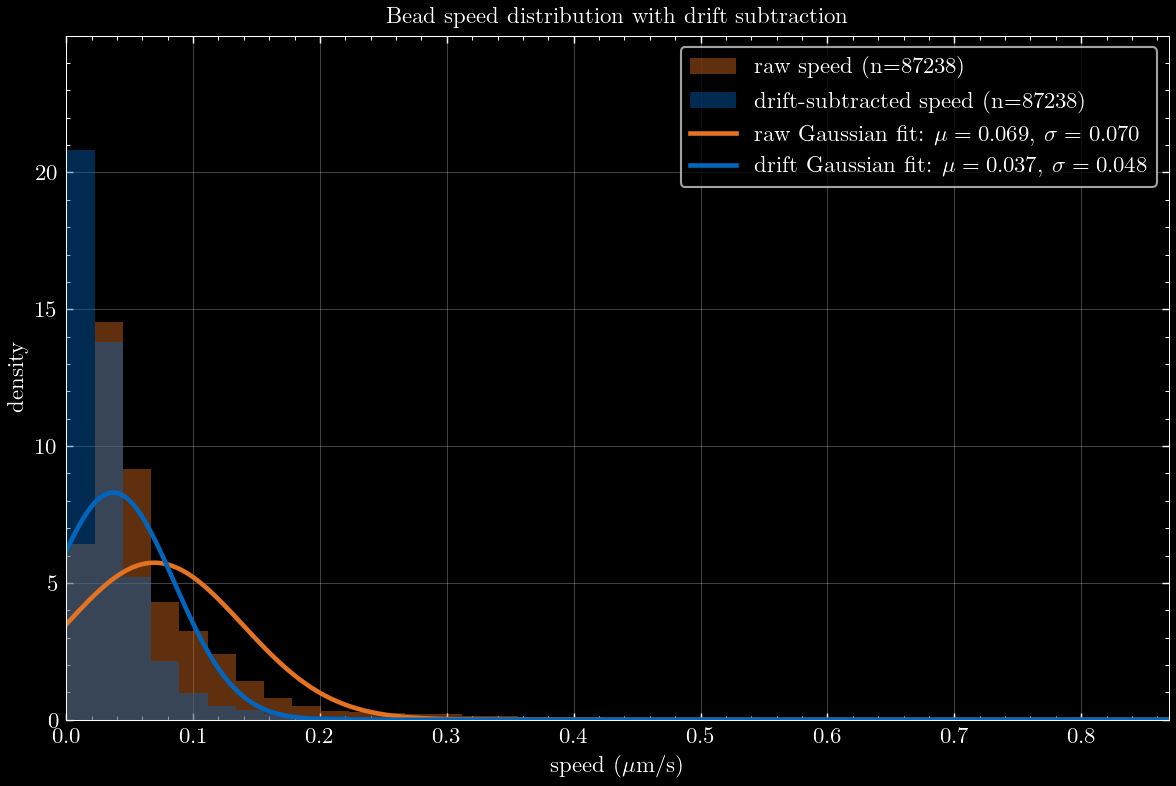

Saved drift-subtracted speed distribution plot to plots/AMF_106_002__C640_C470/AMF_106_002__C640_C470_speed_distribution_with_drift_subtraction_black.pdf
Saved white-background version to plots/AMF_106_002__C640_C470/AMF_106_002__C640_C470_speed_distribution_with_drift_subtraction_white.pdf
 raw_fit_mu_um_s  raw_fit_sigma_um_s  drift_fit_mu_um_s  drift_fit_sigma_um_s     n
        0.069402            0.069504           0.037036              0.048048 87238


In [24]:
# Bead speed distribution with drift subtraction
from pathlib import Path
from scipy.stats import norm as gaussian_dist

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0:
    print('No velocity tracks available for the drift-subtracted speed distribution')
elif 'frame' not in tracks_vel_df.columns:
    print('Velocity table does not contain a frame column')
else:
    velocity_df = tracks_vel_df.copy()
    component_cols = [col for col in ('vx_um_s', 'vy_um_s', 'vz_um_s') if col in velocity_df.columns]
    if len(component_cols) < 2:
        print('Velocity table does not contain enough velocity components for drift subtraction')
    else:
        if 'speed_um_s' not in velocity_df.columns:
            component_array = velocity_df[component_cols].to_numpy(dtype=float)
            velocity_df['speed_um_s'] = np.sqrt(np.sum(np.square(component_array), axis=1))

        required_cols = ['frame', 'speed_um_s'] + component_cols
        speed_df = velocity_df[required_cols].copy()
        finite_mask = np.isfinite(speed_df['frame'].to_numpy(dtype=float)) & np.isfinite(speed_df['speed_um_s'].to_numpy(dtype=float))
        finite_mask &= np.all(np.isfinite(speed_df[component_cols].to_numpy(dtype=float)), axis=1)
        speed_df = speed_df.loc[finite_mask].copy()

        if len(speed_df) == 0:
            print('No finite bead velocities available for drift subtraction')
        else:
                speed_df['frame'] = speed_df['frame'].astype(int)
                drift_means = speed_df.groupby('frame', sort=False)[component_cols].transform('mean')
                drift_components = speed_df[component_cols].to_numpy(dtype=float) - drift_means.to_numpy(dtype=float)
                speed_df['drift_subtracted_speed_um_s'] = np.sqrt(np.sum(np.square(drift_components), axis=1))

                raw_speeds = speed_df['speed_um_s'].to_numpy(dtype=float)
                drift_speeds = speed_df['drift_subtracted_speed_um_s'].to_numpy(dtype=float)
                raw_speeds = raw_speeds[np.isfinite(raw_speeds)]
                drift_speeds = drift_speeds[np.isfinite(drift_speeds)]

                if len(raw_speeds) == 0 or len(drift_speeds) == 0:
                    print('No finite raw or drift-subtracted speeds available for plotting')
                else:
                    raw_mu, raw_sigma = gaussian_dist.fit(raw_speeds)
                    drift_mu, drift_sigma = gaussian_dist.fit(drift_speeds)
                    raw_sigma = max(float(raw_sigma), 1e-12)
                    drift_sigma = max(float(drift_sigma), 1e-12)

                    speed_max = float(np.nanmax(np.concatenate([raw_speeds, drift_speeds])))
                    speed_max = max(speed_max, 1e-6)
                    speed_bins = np.linspace(0.0, speed_max * 1.05, 40)
                    x_grid = np.linspace(0.0, speed_max * 1.05, 500)
                    raw_fit = gaussian_dist.pdf(x_grid, loc=raw_mu, scale=raw_sigma)
                    drift_fit = gaussian_dist.pdf(x_grid, loc=drift_mu, scale=drift_sigma)
                    raw_hist = np.histogram(raw_speeds, bins=speed_bins, density=True)
                    drift_hist = np.histogram(drift_speeds, bins=speed_bins, density=True)
                    y_max = max(
                        float(np.nanmax(raw_hist[0])) if raw_hist[0].size else 0.0,
                        float(np.nanmax(drift_hist[0])) if drift_hist[0].size else 0.0,
                        float(np.nanmax(raw_fit)) if raw_fit.size else 0.0,
                        float(np.nanmax(drift_fit)) if drift_fit.size else 0.0,
                    )
                    y_max = max(y_max, 1e-6)

                    fig_speed_drift, ax_speed_drift = plt.subplots(figsize=(7.8, 5.2), dpi=150)
                    ax_speed_drift.hist(raw_speeds, bins=speed_bins, density=True, alpha=0.42, color=tum_colors[0], label=f'raw speed (n={len(raw_speeds)})')
                    ax_speed_drift.hist(drift_speeds, bins=speed_bins, density=True, alpha=0.42, color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', label=f'drift-subtracted speed (n={len(drift_speeds)})')
                    ax_speed_drift.plot(x_grid, raw_fit, color=tum_colors[0], lw=2.2, label=rf'raw Gaussian fit: $\mu={raw_mu:.3f}$, $\sigma={raw_sigma:.3f}$')
                    ax_speed_drift.plot(x_grid, drift_fit, color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', lw=2.2, label=rf'drift Gaussian fit: $\mu={drift_mu:.3f}$, $\sigma={drift_sigma:.3f}$')
                    ax_speed_drift.set_xlabel(r'speed ($\mu$m/s)')
                    ax_speed_drift.set_ylabel('density')
                    ax_speed_drift.set_title('Bead speed distribution with drift subtraction')
                    ax_speed_drift.set_xlim(0.0, speed_max * 1.05)
                    ax_speed_drift.set_ylim(0.0, y_max * 1.2)
                    ax_speed_drift.grid(True, alpha=0.25)
                    ax_speed_drift.legend(frameon=True)
                    plt.tight_layout()
                    plt.show()

                    speed_plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
                    speed_plot_dir.mkdir(parents=True, exist_ok=True)
                    black_path = speed_plot_dir / f'{dataset_id}_speed_distribution_with_drift_subtraction_black.pdf'
                    fig_speed_drift.savefig(black_path, dpi=150, bbox_inches='tight')

                    white_path = speed_plot_dir / f'{dataset_id}_speed_distribution_with_drift_subtraction_white.pdf'
                    with plt.style.context([
                        './science.mplstyle.txt',
                        {
                            'figure.facecolor': 'white',
                            'axes.facecolor': 'white',
                            'savefig.facecolor': 'white',
                            'text.color': 'black',
                            'axes.labelcolor': 'black',
                            'axes.edgecolor': 'black',
                            'xtick.color': 'black',
                            'ytick.color': 'black',
                            'grid.color': '0.85',
                            'legend.edgecolor': '0.5',
                        },
                    ]):
                        fig_white, ax_white = plt.subplots(figsize=(7.8, 5.2), dpi=150)
                        ax_white.hist(raw_speeds, bins=speed_bins, density=True, alpha=0.42, color=tum_colors[0], label=f'raw speed (n={len(raw_speeds)})')
                        ax_white.hist(drift_speeds, bins=speed_bins, density=True, alpha=0.42, color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', label=f'drift-subtracted speed (n={len(drift_speeds)})')
                        ax_white.plot(x_grid, raw_fit, color=tum_colors[0], lw=2.2, label=rf'raw Gaussian fit: $\mu={raw_mu:.3f}$, $\sigma={raw_sigma:.3f}$')
                        ax_white.plot(x_grid, drift_fit, color=tum_colors[1] if len(tum_colors) > 1 else 'tab:orange', lw=2.2, label=rf'drift Gaussian fit: $\mu={drift_mu:.3f}$, $\sigma={drift_sigma:.3f}$')
                        ax_white.set_xlabel(r'speed ($\mu$m/s)')
                        ax_white.set_ylabel('density')
                        ax_white.set_xlim(0.0, speed_max * 1.05)
                        ax_white.set_ylim(0.0, y_max * 1.2)
                        ax_white.grid(True, alpha=0.25)
                        ax_white.legend(frameon=True)
                        plt.tight_layout()
                        fig_white.savefig(white_path, dpi=150, bbox_inches='tight')
                        plt.close(fig_white)

                    plt.close(fig_speed_drift)
                    print('Saved drift-subtracted speed distribution plot to', black_path)
                    print('Saved white-background version to', white_path)
                    print(pd.DataFrame([{
                        'raw_fit_mu_um_s': float(raw_mu),
                        'raw_fit_sigma_um_s': float(raw_sigma),
                        'drift_fit_mu_um_s': float(drift_mu),
                        'drift_fit_sigma_um_s': float(drift_sigma),
                        'n': int(len(speed_df)),
                    }]).to_string(index=False))


In [ ]:
# Optional Plot C: bead displacement overlay animation (only if velocity tracks are available)
from tomsUtilities import animate_bead_displacement_per_frame_overlay

if 'data_state' not in globals() or data_state is None:
    data_state = load_dataset_state(config['dataset'], verbose=True)

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) > 0:
    bead_channel = int(config['beads'].get('channel_to_use', 1))
    px_per_micron = float(data_state['calibration']['px_per_micron'])
    out_overlay = plot_dir / f"{dataset_id}_beads_displacement_per_frame_overlay.mp4"
    animate_bead_displacement_per_frame_overlay(
        data_state['images'],
        tracks_vel_df,
        out_path=str(out_overlay),
        px_per_micron=px_per_micron,
        bead_channel=bead_channel,
        frame_step=1,
        vector_scale=2.0,
        max_vectors=3000,
        fps=10,
        dpi=150,
        show_title=True,
        verbose=True,
        progress_every=1,
    )
    print('Saved displacement overlay to', out_overlay)
else:
    print('No velocity tracks available for overlay animation')

Rendering displacement overlay animation: 221 frames (step=1)
  rendering frame 1/221 (t=1)
  rendering frame 1/221 (t=1)
  rendering frame 2/221 (t=2)
  rendering frame 3/221 (t=3)
  rendering frame 4/221 (t=4)
  rendering frame 5/221 (t=5)
  rendering frame 6/221 (t=6)
  rendering frame 7/221 (t=7)
  rendering frame 8/221 (t=8)
  rendering frame 9/221 (t=9)
  rendering frame 10/221 (t=10)
  rendering frame 11/221 (t=11)
  rendering frame 12/221 (t=12)
  rendering frame 13/221 (t=13)
  rendering frame 14/221 (t=14)
  rendering frame 15/221 (t=15)
  rendering frame 16/221 (t=16)
  rendering frame 17/221 (t=17)
  rendering frame 18/221 (t=18)
  rendering frame 19/221 (t=19)
  rendering frame 20/221 (t=20)
  rendering frame 21/221 (t=21)
  rendering frame 22/221 (t=22)
  rendering frame 23/221 (t=23)
  rendering frame 24/221 (t=24)
  rendering frame 25/221 (t=25)
  rendering frame 26/221 (t=26)
  rendering frame 27/221 (t=27)
  rendering frame 28/221 (t=28)
  rendering frame 29/221 (t=29

In [ ]:
dataset_id

'AMF_107_002__C640_C470'

Image-time correlation rows: 222
Image-time correlation fit rows: 1


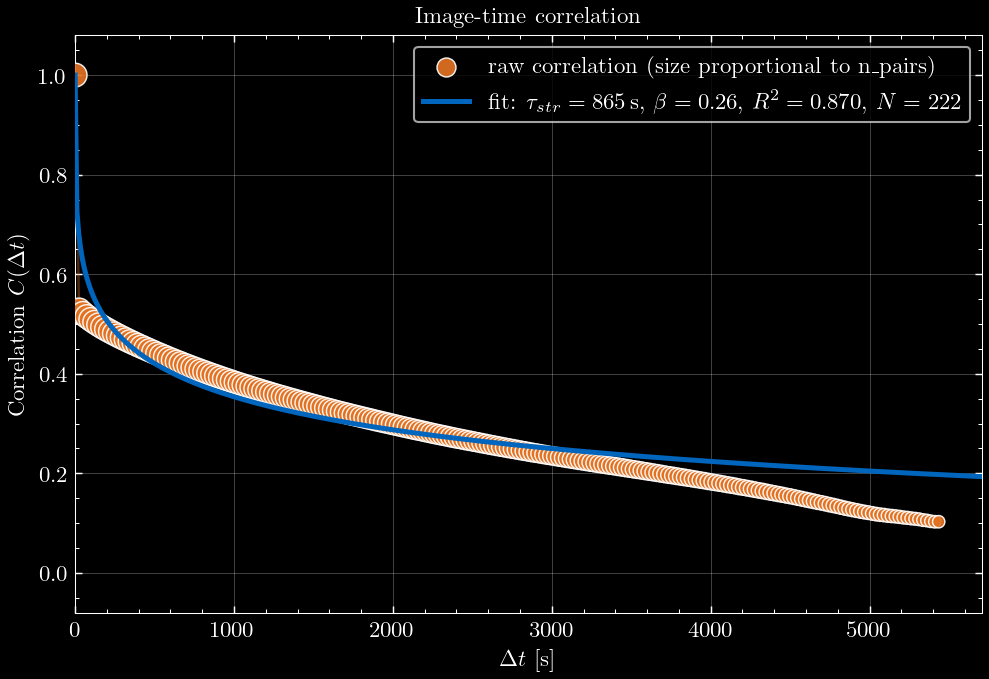

Saved image-time correlation plot to plots/AMF_107_002__C640_C470


In [ ]:
# Image-time correlation plot: raw lag correlation and stretched-exponential fit
image_corr_df = pd.read_parquet(expected_outputs['image_corr']) if expected_outputs['image_corr'].exists() else pd.DataFrame()
image_corr_fit_df = pd.read_parquet(expected_outputs['image_corr_fit']) if expected_outputs['image_corr_fit'].exists() else pd.DataFrame()

print('Image-time correlation rows:', len(image_corr_df))
print('Image-time correlation fit rows:', len(image_corr_fit_df))

if len(image_corr_df) == 0:
    print('No image-time correlation table found; skipping plot.')
else:
    corr_plot_dir = plot_dir
    corr_plot_dir.mkdir(parents=True, exist_ok=True)

    def _stretched_exponential(dt_s, tau_str_s, beta):
        """Evaluate the stretched exponential used for the image-time fit."""
        dt_s = np.asarray(dt_s, dtype=float)
        tau_str_s = max(float(tau_str_s), 1e-12)
        beta = max(float(beta), 1e-12)
        return np.exp(-np.power(np.clip(dt_s, 0.0, None) / tau_str_s, beta))

    def _plot_image_time_correlation(ax):
        """Draw the raw image-time correlation and its fit on the given axes."""
        corr_plot_df = image_corr_df.sort_values('dt_s').copy()
        x_vals = corr_plot_df['dt_s'].to_numpy(dtype=float)
        y_vals = corr_plot_df['corr'].to_numpy(dtype=float)
        sample_counts = corr_plot_df['n_pairs'].to_numpy(dtype=float) if 'n_pairs' in corr_plot_df.columns else np.ones_like(y_vals)

        if 'corr_sem' in corr_plot_df.columns and np.isfinite(corr_plot_df['corr_sem']).any():
            y_err = corr_plot_df['corr_sem'].to_numpy(dtype=float)
        elif 'corr_std' in corr_plot_df.columns and np.isfinite(corr_plot_df['corr_std']).any():
            y_err = corr_plot_df['corr_std'].to_numpy(dtype=float)
        else:
            y_err = None

        finite = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[finite]
        y_vals = y_vals[finite]
        sample_counts = sample_counts[finite]
        if y_err is not None:
            y_err = np.asarray(y_err, dtype=float)[finite]

        if x_vals.size == 0:
            ax.text(0.5, 0.5, 'No finite image-time correlation data', ha='center', va='center', transform=ax.transAxes)
            return

        min_pairs = float(np.nanmin(sample_counts)) if np.isfinite(sample_counts).any() else 1.0
        max_pairs = float(np.nanmax(sample_counts)) if np.isfinite(sample_counts).any() else 1.0
        if not np.isfinite(min_pairs) or min_pairs < 0.0:
            min_pairs = 0.0
        if not np.isfinite(max_pairs) or max_pairs <= min_pairs:
            marker_sizes = np.full_like(sample_counts, 70.0, dtype=float)
        else:
            marker_sizes = np.interp(sample_counts, (min_pairs, max_pairs), (35.0, 130.0))

        face_color = ax.get_facecolor()
        edge_color = 'black' if float(np.mean(face_color[:3])) > 0.5 else 'white'
        raw_color = tum_colors[0]
        fit_color = tum_colors[1] if len(tum_colors) > 1 else 'tab:orange'

        if y_err is not None:
            ax.errorbar(x_vals, y_vals, yerr=y_err, fmt='none', ecolor='0.65', elinewidth=1.0, capsize=2, alpha=0.9, zorder=1)

        ax.scatter(
            x_vals,
            y_vals,
            s=marker_sizes,
            color=raw_color,
            edgecolors=edge_color,
            linewidths=0.7,
            alpha=0.92,
            label='raw correlation (size proportional to n_pairs)',
            zorder=3,
        )
        ax.plot(x_vals, y_vals, color=raw_color, alpha=0.35, lw=1.2, zorder=2)

        fit_candidates = image_corr_fit_df.copy()
        if len(fit_candidates) > 0 and 'channel' in fit_candidates.columns and 'channel' in corr_plot_df.columns:
            fit_candidates = fit_candidates[fit_candidates['channel'] == corr_plot_df.iloc[0]['channel']]
        if len(fit_candidates) > 0 and 'projection' in fit_candidates.columns and 'projection' in corr_plot_df.columns:
            fit_candidates = fit_candidates[fit_candidates['projection'] == corr_plot_df.iloc[0]['projection']]

        fit_curve = None
        if len(fit_candidates) > 0:
            fit_row = fit_candidates.iloc[0]
            tau_str_s = fit_row.get('tau_str_s', np.nan)
            beta = fit_row.get('beta', np.nan)
            fit_r2 = fit_row.get('fit_r2', np.nan)
            fit_points = fit_row.get('fit_points', np.nan)
            if np.isfinite(tau_str_s) and np.isfinite(beta):
                x_fit = np.linspace(0.0, max(1e-12, float(np.nanmax(x_vals))) * 1.05, 500)
                fit_curve = _stretched_exponential(x_fit, tau_str_s, beta)
                fit_label = rf'fit: $\tau_{{str}}={tau_str_s:.3g}\,$s, $\beta={beta:.2f}$'
                if np.isfinite(fit_r2):
                    fit_label += rf', $R^2={fit_r2:.3f}$'
                if np.isfinite(fit_points):
                    fit_label += rf', $N={int(fit_points)}$'
                ax.plot(x_fit, fit_curve, color=fit_color, lw=2.4, label=fit_label, zorder=4)

        ax.set_xlabel(r'$\Delta t$ [s]')
        ax.set_ylabel(r'Correlation $C(\Delta t)$')
        ax.set_title('Image-time correlation')
        ax.grid(True, alpha=0.25)

        y_terms = [y_vals, np.array([0.0, 1.0], dtype=float)]
        if fit_curve is not None:
            y_terms.append(np.asarray(fit_curve, dtype=float))
        y_all = np.concatenate([np.asarray(term, dtype=float).ravel() for term in y_terms if np.size(term) > 0])
        y_all = y_all[np.isfinite(y_all)]
        if y_all.size > 0:
            y_min = float(np.nanmin(y_all))
            y_max = float(np.nanmax(y_all))
            y_pad = 0.08 * max(1e-6, y_max - y_min)
            ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_xlim(0.0, max(1e-12, float(np.nanmax(x_vals))) * 1.05)
        ax.legend(frameon=True)

    fig_corr, ax_corr = plt.subplots(figsize=(7.8, 5.0), dpi=150)
    _plot_image_time_correlation(ax_corr)
    image_corr_stem = f'{dataset_id}_image_time_correlation'
    save_comparison_dual_pdf(fig_corr, corr_plot_dir, image_corr_stem, white_plot_fn=_plot_image_time_correlation, dpi=150)
    plt.show()
    plt.close(fig_corr)
    print('Saved image-time correlation plot to', corr_plot_dir)

## 10. Parity Plots (3D/2D Autocorr Profiles)

This section reproduces the core profile-style validation plots from the previous notebooks using saved compute outputs.

data/AMF_107_002__C640_C470/derived


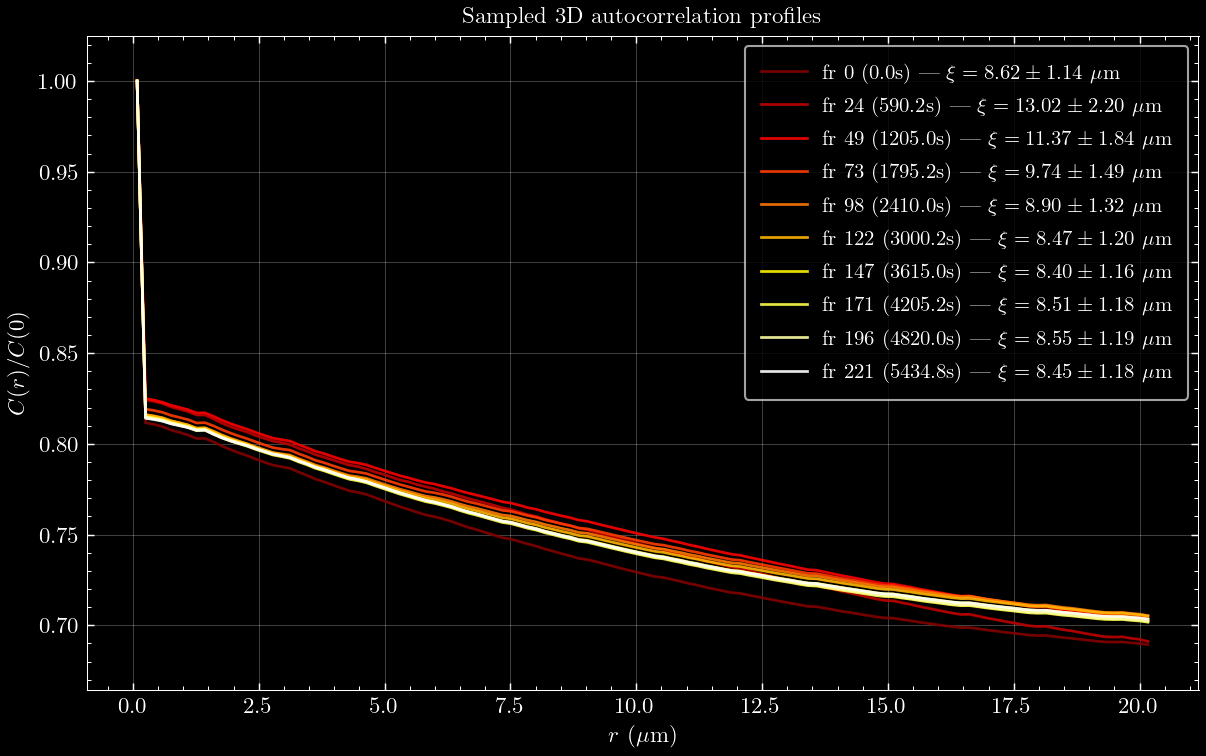

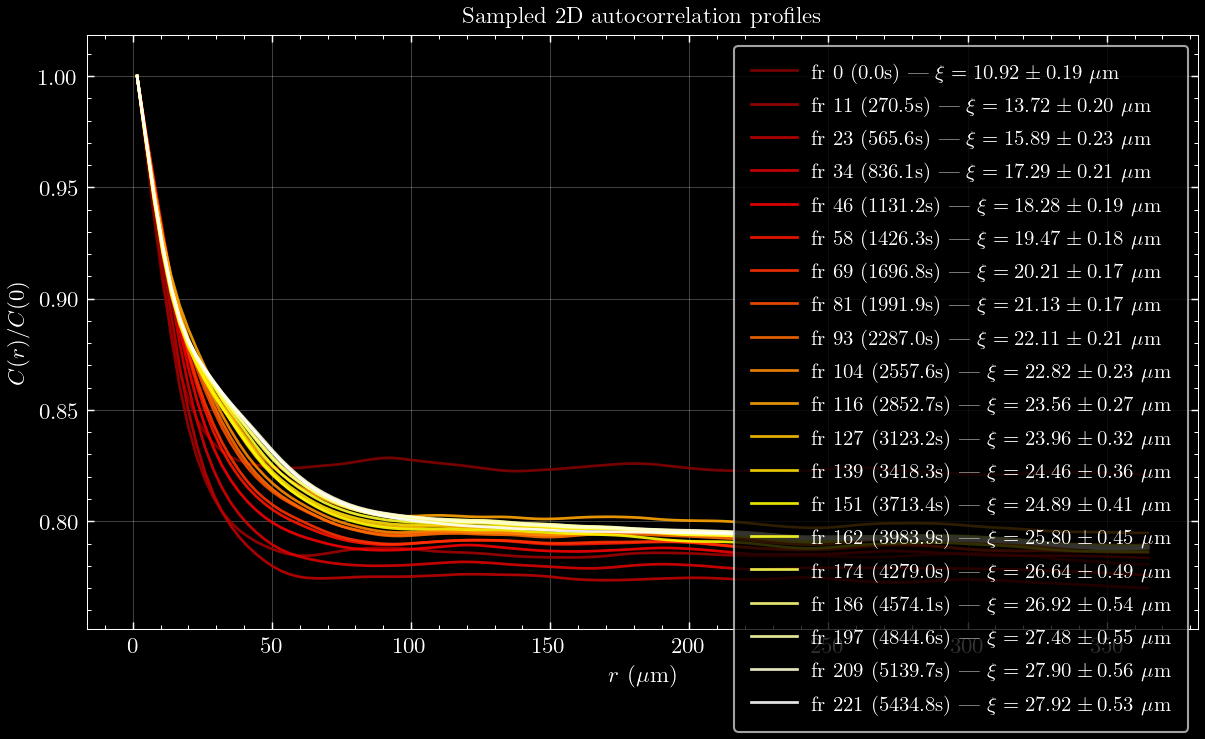

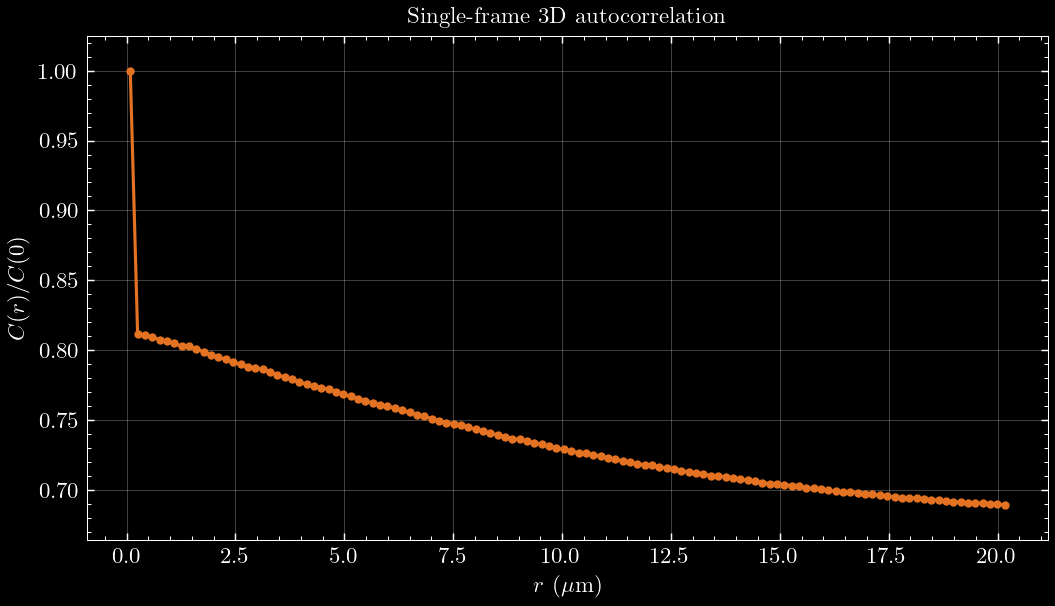

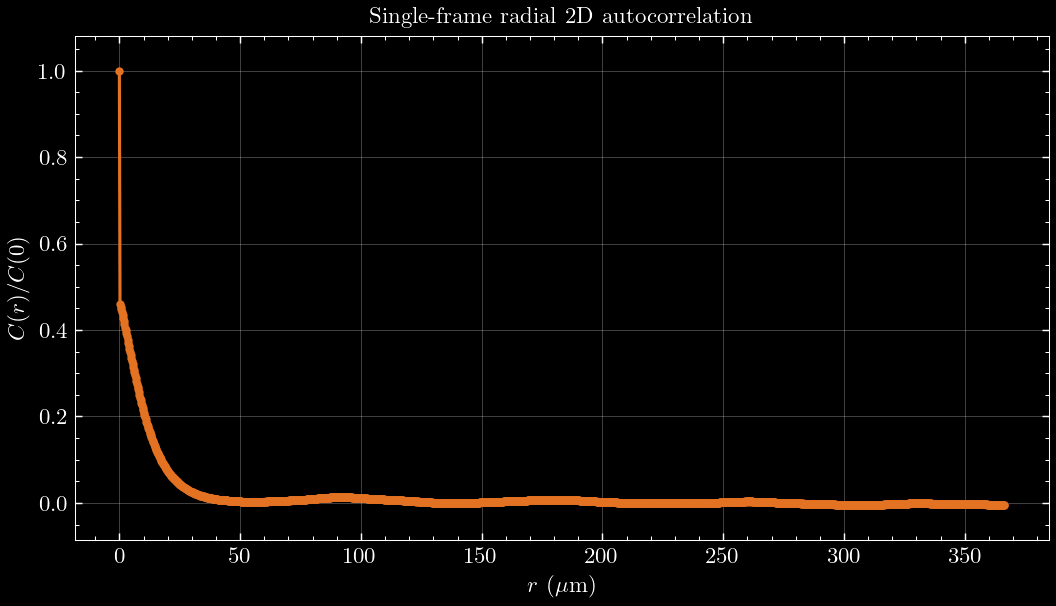

Saved metrics to data/AMF_107_002__C640_C470/derived/core_metrics_summary.parquet
Saved artifact manifest to data/AMF_107_002__C640_C470/derived/core_artifacts_manifest.parquet
Output directory: data/AMF_107_002__C640_C470/derived
Plot directory: plots/AMF_107_002__C640_C470


,artifact,exists,path
0,detections,True,data/AMF_107_002__C640_C470/derived/beads_dete...
1,tracks,True,data/AMF_107_002__C640_C470/derived/beads_trac...
2,tracks_vel,True,data/AMF_107_002__C640_C470/derived/beads_trac...
3,tracks_ang,False,data/AMF_107_002__C640_C470/derived/beads_trac...
4,ac3d_single,True,data/AMF_107_002__C640_C470/derived/autocorr_3...
5,ac3d_sampled,True,data/AMF_107_002__C640_C470/derived/autocorr_3...
6,ac2d_sampled,True,data/AMF_107_002__C640_C470/derived/autocorr_2...
7,ac2d_radial,True,data/AMF_107_002__C640_C470/derived/autocorr_2...
8,image_corr,True,data/AMF_107_002__C640_C470/derived/image_time...
9,image_corr_fit,True,data/AMF_107_002__C640_C470/derived/image_time...


In [ ]:
print(derived_dir)
ac3d_single_df = pd.read_parquet(expected_outputs['ac3d_single']) if expected_outputs['ac3d_single'].exists() else pd.DataFrame()
ac2d_radial_df = pd.read_parquet(expected_outputs['ac2d_radial']) if expected_outputs['ac2d_radial'].exists() else pd.DataFrame()


def _apply_data_limits(ax, x_vals, y_vals, x_pad_frac=0.05, y_pad_frac=0.08, x_lower=None, x_upper=None):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    if not np.any(valid):
        return
    x = x[valid]
    y = y[valid]
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))
    if x_max > x_min:
        x_pad = x_pad_frac * (x_max - x_min)
        left = x_min - x_pad if x_lower is None else max(x_lower, x_min - x_pad)
        right = x_max + x_pad if x_upper is None else min(x_upper, x_max + x_pad)
        ax.set_xlim(left, right)
    if y_max > y_min:
        y_pad = y_pad_frac * (y_max - y_min)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)


def _ordered_hot_colors(n: int):
    if n <= 1:
        return np.array([tum_colors[0]])
    cmap = plt.get_cmap('hot')
    values = np.linspace(0.18, 1.0, n)
    return np.array([cmap(v) for v in values])


def _legend_scale(fig):
    width, height = fig.get_size_inches()
    base = min(width, height)
    fontsize = max(10, min(16, int(round(base * 1.4))))
    return {
        'fontsize': fontsize,
        'title_fontsize': fontsize,
        'handlelength': 2.2,
        'labelspacing': 0.6,
        'borderpad': 0.8,
        'handletextpad': 0.7,
        'columnspacing': 1.2,
    }


def _format_decay_label(row, frame_label: str):
    parts = [frame_label]
    xi_value = row.get('xi_um', np.nan)
    xi_err = row.get('xi_err_um', np.nan)
    if np.isfinite(xi_value):
        if np.isfinite(xi_err):
            parts.append(rf'$\xi={xi_value:.2f}\pm{xi_err:.2f}$ $\mu$m')
        else:
            parts.append(rf'$\xi={xi_value:.2f}$ $\mu$m')
    tau_value = row.get('tau_s', np.nan)
    tau_err = row.get('tau_err_s', np.nan)
    if np.isfinite(tau_value):
        if np.isfinite(tau_err):
            parts.append(rf'$\tau={tau_value:.2f}\pm{tau_err:.2f}$ s')
        else:
            parts.append(rf'$\tau={tau_value:.2f}$ s')
    return ' | '.join(parts)


# 3D sampled autocorr profiles per sampled frame
if len(ac3d_sampled_df):
    fig_prof3d, ax_prof3d = plt.subplots(figsize=(8, 5), dpi=150)
    grouped_3d = list(ac3d_sampled_df.groupby('frame', sort=True))
    colors_3d = _ordered_hot_colors(len(grouped_3d))
    for (fr, g), color in zip(grouped_3d, colors_3d):
        g = g.sort_values('r_um')
        first_row = g.iloc[0]
        t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
        label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
        ax_prof3d.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
    ax_prof3d.set_xlabel(r'$r$ ($\mu$m)')
    ax_prof3d.set_ylabel(r'$C(r)/C(0)$')
    ax_prof3d.set_title(r'Sampled 3D autocorrelation profiles')
    ax_prof3d.grid(True, alpha=0.25)
    ax_prof3d.legend(loc='upper right', frameon=True, **_legend_scale(fig_prof3d))
    _apply_data_limits(ax_prof3d, ac3d_sampled_df['r_um'], ac3d_sampled_df['corr'])
    plt.tight_layout()
    plt.show()

    fig_prof3d.savefig(plot_dir / f"{dataset_id}_sampled_autocorr_profiles_black.pdf", dpi=150, bbox_inches='tight')
    with plt.style.context([
        './science.mplstyle.txt',
        {
            'figure.facecolor': 'white',
            'axes.facecolor': 'white',
            'savefig.facecolor': 'white',
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'axes.edgecolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'grid.color': '0.8',
            'legend.edgecolor': '0.5',
        },
    ]):
        fig_w, ax_w = plt.subplots(figsize=(8, 5), dpi=150)
        for (fr, g), color in zip(grouped_3d, colors_3d):
            g = g.sort_values('r_um')
            first_row = g.iloc[0]
            t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
            label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
            ax_w.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
        ax_w.set_xlabel(r'$r$ ($\mu$m)')
        ax_w.set_ylabel(r'$C(r)/C(0)$')
        ax_w.grid(True, alpha=0.25)
        ax_w.legend(loc='upper right', frameon=True, **_legend_scale(fig_w))
        _apply_data_limits(ax_w, ac3d_sampled_df['r_um'], ac3d_sampled_df['corr'])
        fig_w.savefig(plot_dir / f"{dataset_id}_sampled_autocorr_profiles_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w)
else:
    print('No sampled 3D profiles available')

# 2D sampled autocorr profiles per sampled frame
if len(ac2d_sampled_df):
    fig_prof2d, ax_prof2d = plt.subplots(figsize=(8, 5), dpi=150)
    grouped_2d = list(ac2d_sampled_df.groupby('frame', sort=True))
    colors_2d = _ordered_hot_colors(len(grouped_2d))
    for (fr, g), color in zip(grouped_2d, colors_2d):
        g = g.sort_values('r_um')
        first_row = g.iloc[0]
        t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
        label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
        ax_prof2d.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
    ax_prof2d.set_xlabel(r'$r$ ($\mu$m)')
    ax_prof2d.set_ylabel(r'$C(r)/C(0)$')
    ax_prof2d.set_title(r'Sampled 2D autocorrelation profiles')
    ax_prof2d.grid(True, alpha=0.25)
    ax_prof2d.legend(loc='upper right', frameon=True, **_legend_scale(fig_prof2d))
    _apply_data_limits(ax_prof2d, ac2d_sampled_df['r_um'], ac2d_sampled_df['corr'])
    plt.tight_layout()
    plt.show()

    fig_prof2d.savefig(plot_dir / f"{dataset_id}_sampled_2d_autocorr_profiles_black.pdf", dpi=150, bbox_inches='tight')
    with plt.style.context([
        './science.mplstyle.txt',
        {
            'figure.facecolor': 'white',
            'axes.facecolor': 'white',
            'savefig.facecolor': 'white',
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'axes.edgecolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'grid.color': '0.8',
            'legend.edgecolor': '0.5',
        },
    ]):
        fig_w2, ax_w2 = plt.subplots(figsize=(8, 5), dpi=150)
        for (fr, g), color in zip(grouped_2d, colors_2d):
            g = g.sort_values('r_um')
            first_row = g.iloc[0]
            t_label = first_row['time_s'] if 'time_s' in g.columns else float(fr)
            label = _format_decay_label(first_row, f'fr {fr} ({t_label:.1f}s)')
            ax_w2.plot(g['r_um'].to_numpy(), g['corr'].to_numpy(), lw=1.3, alpha=0.9, color=color, label=label)
        ax_w2.set_xlabel(r'$r$ ($\mu$m)')
        ax_w2.set_ylabel(r'$C(r)/C(0)$')
        ax_w2.grid(True, alpha=0.25)
        ax_w2.legend(loc='upper right', frameon=True, **_legend_scale(fig_w2))
        _apply_data_limits(ax_w2, ac2d_sampled_df['r_um'], ac2d_sampled_df['corr'])
        fig_w2.savefig(plot_dir / f"{dataset_id}_sampled_2d_autocorr_profiles_white.pdf", dpi=150, bbox_inches='tight')
        plt.close(fig_w2)
else:
    print('No sampled 2D profiles available')

# Single-frame 3D and radial 2D sanity curves
if len(ac3d_single_df):
    fig_s3d, ax_s3d = plt.subplots(figsize=(7, 4), dpi=150)
    g3 = ac3d_single_df.sort_values('r_um')
    ax_s3d.plot(g3['r_um'].to_numpy(), g3['corr'].to_numpy(), marker='.', lw=1.5, color=tum_colors[0])
    ax_s3d.set_xlabel(r'$r$ ($\mu$m)')
    ax_s3d.set_ylabel(r'$C(r)/C(0)$')
    ax_s3d.set_title(r'Single-frame 3D autocorrelation')
    ax_s3d.grid(True, alpha=0.25)
    _apply_data_limits(ax_s3d, g3['r_um'], g3['corr'])
    plt.tight_layout()
    plt.show()

if len(ac2d_radial_df):
    fig_r2d, ax_r2d = plt.subplots(figsize=(7, 4), dpi=150)
    g2 = ac2d_radial_df.sort_values('r_um')
    ax_r2d.plot(g2['r_um'].to_numpy(), g2['corr'].to_numpy(), marker='.', lw=1.5, color=tum_colors[0])
    ax_r2d.set_xlabel(r'$r$ ($\mu$m)')
    ax_r2d.set_ylabel(r'$C(r)/C(0)$')
    ax_r2d.set_title(r'Single-frame radial 2D autocorrelation')
    ax_r2d.grid(True, alpha=0.25)
    _apply_data_limits(ax_r2d, g2['r_um'], g2['corr'])
    plt.tight_layout()
    plt.show()

# Persist summary table and artifact manifest for reproducibility
metrics_out = derived_dir / 'core_metrics_summary.parquet'
metrics_df.to_parquet(metrics_out, index=False)

artifacts_df = pd.DataFrame(
    {
        'artifact': list(expected_outputs.keys()),
        'exists': [p.exists() for p in expected_outputs.values()],
        'path': [str(p) for p in expected_outputs.values()],
    }
)
artifacts_out = derived_dir / 'core_artifacts_manifest.parquet'
artifacts_df.to_parquet(artifacts_out, index=False)

print('Saved metrics to', metrics_out)
print('Saved artifact manifest to', artifacts_out)
print('Output directory:', derived_dir)
print('Plot directory:', plot_dir)
display(artifacts_df)

Angular mode disabled: skipping angular speed computation and distribution plot
No finite angular speed values available for plotting


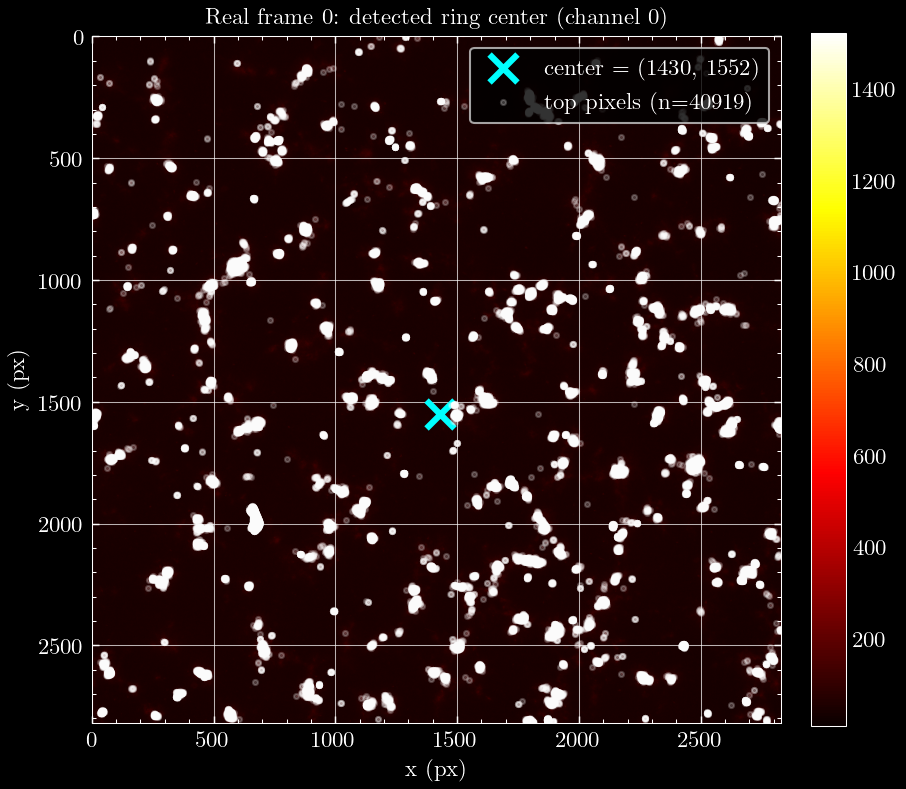

Real frame: 0
Real detected center (x, y): (1430, 1552)
Real bright-pixel threshold: 166
Angular speed sample size: 0
Gaussian center (mu): n/a
Gaussian variance: n/a


In [ ]:
from analysis_pipeline.beads_velocity import compute_angular_speed_xy
from analysis_pipeline.io_dataset import load_dataset_state
from scipy.optimize import minimize
from scipy.stats import norm

angular_mode = bool(config['beads'].get('angular_mode', False))
state_for_autocorr = (
    globals().get('state_for_autocorr')
    or (globals().get('autocorr_out') or {}).get('state')
    or (globals().get('bead_out') or {}).get('state')
    or load_dataset_state(config['dataset'], verbose=True)
)

if angular_mode:
    ang_df = compute_angular_speed_xy(state_for_autocorr, tracks_vel_df, config['beads'], skip_existing=True)
    omega = ang_df['omega_rad_s'].to_numpy(dtype=float) if 'omega_rad_s' in ang_df.columns else np.array([])
    omega = omega[np.isfinite(omega)]
else:
    ang_df = pd.DataFrame()
    omega = np.array([])
    print('Angular mode disabled: skipping angular speed computation and distribution plot')


def _detect_ring_center(frame_2d, percentile=99.5, min_pixels=80):
    frame_2d = np.asarray(frame_2d, dtype=float)
    finite = np.isfinite(frame_2d)
    if not np.any(finite):
        raise ValueError('Frame contains no finite pixels')

    values = frame_2d[finite]
    threshold = float(np.percentile(values, percentile))
    bright_mask = frame_2d >= threshold
    if int(bright_mask.sum()) < int(min_pixels):
        flat = frame_2d.ravel()
        k = min(int(min_pixels), flat.size)
        keep = np.argpartition(flat, -k)[-k:]
        bright_mask = np.zeros_like(frame_2d, dtype=bool)
        bright_mask.ravel()[keep] = True
        threshold = float(np.min(flat[keep]))

    coords = np.argwhere(bright_mask)
    weights = np.clip(frame_2d[bright_mask], a_min=0.0, a_max=None)
    if coords.size == 0:
        center_yx = np.array(np.unravel_index(int(np.nanargmax(frame_2d)), frame_2d.shape), dtype=float)
    elif np.all(weights == 0):
        center_yx = coords.mean(axis=0).astype(float)
    else:
        center_yx = np.average(coords, axis=0, weights=weights).astype(float)

    def _symmetry_cost(center_yx_candidate):
        cy, cx = center_yx_candidate
        distances = np.sqrt((coords[:, 0] - cy) ** 2 + (coords[:, 1] - cx) ** 2)
        if distances.size == 0:
            return np.inf
        distance_spread = np.average((distances - np.average(distances, weights=weights)) ** 2, weights=weights)
        radial_bias = -np.average(frame_2d[bright_mask], weights=weights)
        return float(distance_spread + 1e-6 * radial_bias)

    result = minimize(
        _symmetry_cost,
        x0=center_yx,
        method='Powell',
        options={'xtol': 1e-2, 'ftol': 1e-4, 'maxiter': 200},
    )
    if result.success and np.all(np.isfinite(result.x)):
        center_yx = np.asarray(result.x, dtype=float)

    center_yx[0] = float(np.clip(center_yx[0], 0, frame_2d.shape[0] - 1))
    center_yx[1] = float(np.clip(center_yx[1], 0, frame_2d.shape[1] - 1))
    return threshold, bright_mask, np.rint(center_yx).astype(int)


def _frame_to_2d_projection(images, frame_idx, channel_idx):
    frame = images[frame_idx]
    frame = np.asarray(frame.compute() if hasattr(frame, 'compute') else frame)
    if frame.ndim == 4:
        channel_idx = int(np.clip(channel_idx, 0, frame.shape[0] - 1))
        frame = frame[channel_idx]
    elif frame.ndim == 3 and frame.shape[0] <= 4 and frame.shape[-1] != frame.shape[-2]:
        channel_idx = int(np.clip(channel_idx, 0, frame.shape[0] - 1))
        frame = frame[channel_idx]
    if frame.ndim == 3:
        frame_2d = frame.max(axis=0)
    elif frame.ndim == 2:
        frame_2d = frame
    else:
        raise ValueError(f'Unexpected frame shape for center detection: {frame.shape}')
    return np.asarray(frame_2d, dtype=float)


def _set_hist_limits(ax, values, hist_peak=None, pad_frac=0.08, lower_pct=0.5, upper_pct=99.5):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return
    left, right = np.nanpercentile(values, [lower_pct, upper_pct])
    left = float(left)
    right = float(right)
    span = right - left
    if span > 0:
        pad = pad_frac * span
        ax.set_xlim(left - pad, right + pad)
    if hist_peak is not None and np.isfinite(hist_peak):
        ax.set_ylim(0.0, float(hist_peak) * 1.12)


channel_to_use = 0
frame_counts = ang_df['frame'].value_counts().sort_values(ascending=False) if len(ang_df) else pd.Series(dtype=int)
frame_to_show = int(frame_counts.index[0]) if len(frame_counts) else 0
frame_2d = _frame_to_2d_projection(state_for_autocorr['images'], frame_to_show, channel_to_use)
threshold_real, bright_mask_real, center_real = _detect_ring_center(frame_2d, percentile=99.5, min_pixels=80)

if omega.size > 0:
    omega_mu, omega_sigma = norm.fit(omega)
    omega_var = float(omega_sigma ** 2)
    omega_x = np.linspace(*np.nanpercentile(omega, [0.5, 99.5]), 400) if omega.size > 1 else np.array([omega_mu])
    omega_pdf = norm.pdf(omega_x, loc=omega_mu, scale=omega_sigma) if omega_sigma > 0 else np.zeros_like(omega_x)
    omega_ymax = float(max(np.nanmax(omega_pdf) if omega_pdf.size else 0.0, 1e-12))
    fig_omega, ax_omega = plt.subplots(figsize=(7, 4), dpi=150)
    hist_vals, hist_bins, _ = ax_omega.hist(
        omega,
        bins=40,
        density=True,
        color=tum_colors[1],
        alpha=0.9,
        label=rf'Histogram ($n={omega.size}$)',
    )
    if omega_sigma > 0:
        ax_omega.plot(
            omega_x,
            omega_pdf,
            color=tum_colors[0],
            lw=2.5,
            label=rf'Gaussian fit: center = {omega_mu:.4g} rad/s, variance = {omega_var:.4g} (rad/s)$^2$',
        )
        omega_ymax = max(omega_ymax, float(np.nanmax(omega_pdf)))
    ax_omega.set_xlabel(r'angular speed $\omega$ (rad/s)')
    ax_omega.set_ylabel('density')
    ax_omega.set_title('Angular speed distribution')
    ax_omega.grid(True, alpha=0.25)
    _set_hist_limits(ax_omega, omega, hist_peak=hist_vals.max() if hist_vals.size else None)
    omega_hist_ymax = float(hist_vals.max()) if hist_vals.size else 0.0
    omega_limit = max(float(omega_ymax), omega_hist_ymax)
    ax_omega.set_ylim(0.0, omega_limit * 1.15 if omega_limit > 0 else 1.0)
    ax_omega.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_omega, f'{dataset_id}_angular_speed_distribution')

    def _omega_plot_white(ax):
        ax.hist(
            omega,
            bins=40,
            density=True,
            color=tum_colors[1],
            alpha=0.9,
            label=rf'Histogram ($n={omega.size}$)',
        )
        if omega_sigma > 0:
            ax.plot(
                omega_x,
                omega_pdf,
                color=tum_colors[0],
                lw=2.5,
                label=rf'Gaussian fit: center = {omega_mu:.4g} rad/s, variance = {omega_var:.4g} (rad/s)$^2$',
            )
        ax.set_xlabel(r'angular speed $\omega$ (rad/s)')
        ax.set_ylabel('density')
        ax.set_title('Angular speed distribution')
        ax.grid(True, alpha=0.25)
        _set_hist_limits(ax, omega, hist_peak=hist_vals.max() if hist_vals.size else None)
        omega_hist_ymax = float(hist_vals.max()) if hist_vals.size else 0.0
        omega_limit = max(float(omega_ymax), omega_hist_ymax)
        ax.set_ylim(0.0, omega_limit * 1.15 if omega_limit > 0 else 1.0)
        ax.legend(loc='upper right', frameon=True)

    _save_dual_replot(f'{dataset_id}_angular_speed_distribution', _omega_plot_white)
else:
    print('No finite angular speed values available for plotting')

fig_center, ax_center = plt.subplots(figsize=(6, 6), dpi=150)
im = ax_center.imshow(frame_2d, cmap='hot')
ax_center.scatter(center_real[1], center_real[0], s=180, marker='x', color='cyan', linewidths=3, label=f'center = ({center_real[1]}, {center_real[0]})')
bright_yx = np.argwhere(bright_mask_real)
if bright_yx.size:
    ax_center.scatter(bright_yx[:, 1], bright_yx[:, 0], s=6, color='white', alpha=0.22, label=f'top pixels (n={len(bright_yx)})')
ax_center.set_title(f'Real frame {frame_to_show}: detected ring center (channel 0)')
ax_center.set_xlabel('x (px)')
ax_center.set_ylabel('y (px)')
ax_center.legend(loc='upper right', frameon=True)
fig_center.colorbar(im, ax=ax_center, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

_save_dual_pdf(fig_center, f'{dataset_id}_ring_center_validation_real')

print(f'Real frame: {frame_to_show}')
print(f'Real detected center (x, y): ({center_real[1]}, {center_real[0]})')
print(f'Real bright-pixel threshold: {threshold_real:.4g}')
print(f'Angular speed sample size: {omega.size}')
print(f'Gaussian center (mu): {omega_mu:.6g} rad/s' if omega.size > 0 else 'Gaussian center (mu): n/a')
print(f'Gaussian variance: {omega_var:.6g} (rad/s)^2' if omega.size > 0 else 'Gaussian variance: n/a')

## 10. Secondary Analyses

Use this section for comparison analyses that build on the saved compute outputs without breaking the notebook structure.

In [ ]:
# Comparison setup (config-driven)
comparison_cfg = dict(config.get('comparison', {}))

if not comparison_cfg.get('enabled', False):
    print('Comparison disabled in config. Enable via config["comparison"]["enabled"]=True or update your config file.')
else:
    try:
        comparison_specs = comparison_specs_from_config(comparison_cfg)
    except Exception as exc:
        print('Error building comparison specs:', exc)
        comparison_specs = []

    if not comparison_specs:
        print('No comparison datasets found in config["comparison"]["groups"]')
    else:
        comparison_name = str(comparison_cfg.get('name', 'concentration_comparison'))
        comparison_output_root = Path(comparison_cfg.get('output_root', 'plots/comparisons'))
        out_dir = comparison_output_dir(comparison_output_root, comparison_name)

        df = pd.DataFrame([
            {
                'dataset_id': s.dataset_id,
                'label': s.label,
                'color': s.color,
                'group': s.group,
                'variation': s.variation,
                'base_dir': s.base_dir,
            }
            for s in comparison_specs
        ])

        print(f'Comparison name: {comparison_name}')
        print(f'Output directory: {out_dir}')
        print(f'{len(comparison_specs)} datasets configured for comparison')
        display(df)

        # Group summary
        groups = {}
        for s in comparison_specs:
            g = s.group or s.variation or 'ungrouped'
            groups.setdefault(g, []).append(s)

        for g, specs in groups.items():
            colors = [sp.color for sp in specs]
            print(f"Group '{g}': {len(specs)} datasets, colors: {colors}")


Comparison name: concentration_comparison
Output directory: plots/comparisons/concentration_comparison
8 datasets configured for comparison


,dataset_id,label,color,group,variation,base_dir
0,AMF_088_002__C640_C470,2 mM ATP,#08306b,ATP,,data
1,AMF_101_002__C640_C470,0.6 mM ATP,#08519c,ATP,,data
2,AMF_089_003__C640_C470,0.2 mM ATP,#2171b5,ATP,,data
3,AMF_090_003__C640_C470,0.02 mM ATP,#6baed6,ATP,,data
4,AMF_092_002__C640_C470,0.1 µM PRC,#a6dba0,PRC,,data
5,AMF_088_002__C640_C470,0.3 µM PRC,#5aae61,PRC,,data
6,AMF_091_002__C640_C470,0.6 µM PRC,#1b7837,PRC,,data
7,AMF_093_002__C640_C470,2.0 µM PRC,#00441b,PRC,,data


Group 'ATP': 4 datasets, colors: ['#08306b', '#08519c', '#2171b5', '#6baed6']
Group 'PRC': 4 datasets, colors: ['#a6dba0', '#5aae61', '#1b7837', '#00441b']


## 10.1. Channel 1 z-Axis Autocorrelation

This subsection plots the 1D autocorrelation along the z axis for channel 1 on a single frame.

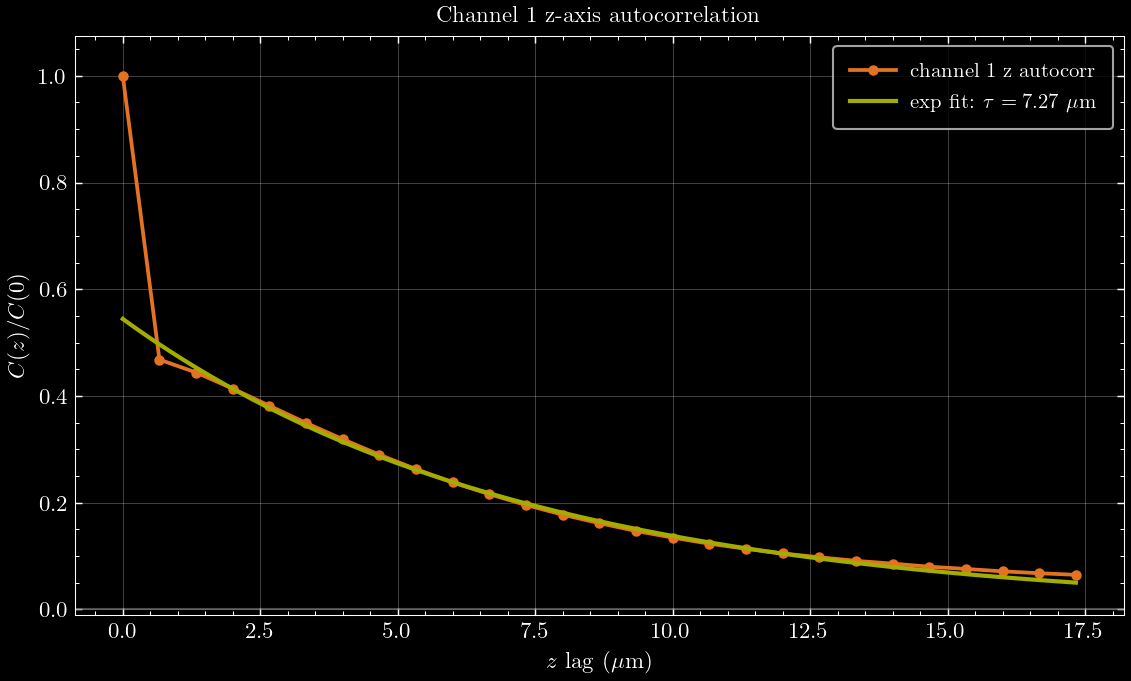

Channel: 0
Frame: 0
Volume shape: (27, 2818, 2829)
Z calibration: 0.6667 px/um
Lag count: 27
Exp fit tau: 7.27316 um


In [ ]:
from analysis_pipeline.io_dataset import load_dataset_state
from tomsUtilities import autocorr_1d_axis, fit_exp_decay

state_for_autocorr = (
    globals().get('state_for_autocorr')
    or (globals().get('autocorr_out') or {}).get('state')
    or (globals().get('bead_out') or {}).get('state')
    or load_dataset_state(config['dataset'], verbose=True)
)

images = state_for_autocorr['images']
calibration = state_for_autocorr['calibration']
px_z = float(calibration.get('px_per_micron_z', calibration['px_per_micron']))

frame_idx = 0
channel_idx = 0

volume = images[frame_idx, channel_idx].compute() if hasattr(images[frame_idx, channel_idx], 'compute') else images[frame_idx, channel_idx]
volume = np.asarray(volume, dtype=np.float32)
if volume.ndim != 3:
    raise ValueError(f'Expected a 3D volume for channel 1, got shape {volume.shape}')
if channel_idx > 0 and volume.size == 0:
    raise ValueError('Channel 1 volume is empty')

distances_z, corr_z = autocorr_1d_axis(volume, axis=0, px_scale=px_z)
corr_z = np.asarray(corr_z, dtype=float)
valid = np.isfinite(distances_z) & np.isfinite(corr_z)
distances_z = distances_z[valid]
corr_z = corr_z[valid]

def _apply_axis_limits(ax, x_vals, y_vals, x_pad_frac=0.05, y_pad_frac=0.08):
    """Set tight axis limits with a small padding around finite data."""
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if not np.any(finite):
        return
    x = x[finite]
    y = y[finite]
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    y_min = float(np.nanmin(y))
    y_max = float(np.nanmax(y))
    if x_max > x_min:
        x_pad = x_pad_frac * (x_max - x_min)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
    if y_max > y_min:
        y_pad = y_pad_frac * (y_max - y_min)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

fit_mask = (distances_z > 0) & np.isfinite(corr_z)
fit_fraction = 0.5
tau_fit = None
amp_fit = None
if np.count_nonzero(fit_mask) >= 2:
    amp_fit, tau_fit = fit_exp_decay(distances_z, corr_z, fit_fraction=fit_fraction)

fig_zcorr, ax_zcorr = plt.subplots(figsize=(7.5, 4.5), dpi=150)
ax_zcorr.plot(distances_z, corr_z, marker='o', ms=4, lw=1.8, color=tum_colors[0], label='channel 1 z autocorr')
ax_zcorr.axhline(0.0, color='gray', lw=1.0, alpha=0.6)
if tau_fit is not None and np.isfinite(tau_fit):
    fit_x = np.linspace(float(distances_z[0]), float(distances_z[-1]), 400)
    fit_y = amp_fit * np.exp(-fit_x / tau_fit) if amp_fit is not None else np.exp(-fit_x / tau_fit)
    ax_zcorr.plot(fit_x, fit_y, color=tum_colors[2], lw=2.0, label=rf'exp fit: $\tau = {tau_fit:.3g}$ $\mu$m')
ax_zcorr.set_xlabel(r'$z$ lag ($\mu$m)')
ax_zcorr.set_ylabel(r'$C(z)/C(0)$')
ax_zcorr.set_title('Channel 1 z-axis autocorrelation')
ax_zcorr.grid(True, alpha=0.25)
_apply_axis_limits(ax_zcorr, distances_z, corr_z)
ax_zcorr.legend(loc='upper right', frameon=True, **_legend_scale(fig_zcorr))
plt.tight_layout()
plt.show()

_save_dual_pdf(fig_zcorr, f'{dataset_id}_channel1_z_autocorr')

def _z_autocorr_white(ax):
    """Replot the channel 1 z-axis autocorrelation on a white background."""
    ax.plot(distances_z, corr_z, marker='o', ms=4, lw=1.8, color=tum_colors[0], label='channel 1 z autocorr')
    ax.axhline(0.0, color='gray', lw=1.0, alpha=0.6)
    if tau_fit is not None and np.isfinite(tau_fit):
        fit_x = np.linspace(float(distances_z[0]), float(distances_z[-1]), 400)
        fit_y = amp_fit * np.exp(-fit_x / tau_fit) if amp_fit is not None else np.exp(-fit_x / tau_fit)
        ax.plot(fit_x, fit_y, color=tum_colors[2], lw=2.0, label=rf'exp fit: $\tau = {tau_fit:.3g}$ $\mu$m')
    ax.set_xlabel(r'$z$ lag ($\mu$m)')
    ax.set_ylabel(r'$C(z)/C(0)$')
    ax.grid(True, alpha=0.25)
    _apply_axis_limits(ax, distances_z, corr_z)
    ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_zcorr))

_save_dual_replot(f'{dataset_id}_channel1_z_autocorr', _z_autocorr_white)

print(f'Channel: {channel_idx}')
print(f'Frame: {frame_idx}')
print(f'Volume shape: {volume.shape}')
print(f'Z calibration: {px_z:.4g} px/um')
print(f'Lag count: {distances_z.size}')
print(f'Exp fit tau: {tau_fit:.6g} um' if tau_fit is not None else 'Exp fit tau: n/a')

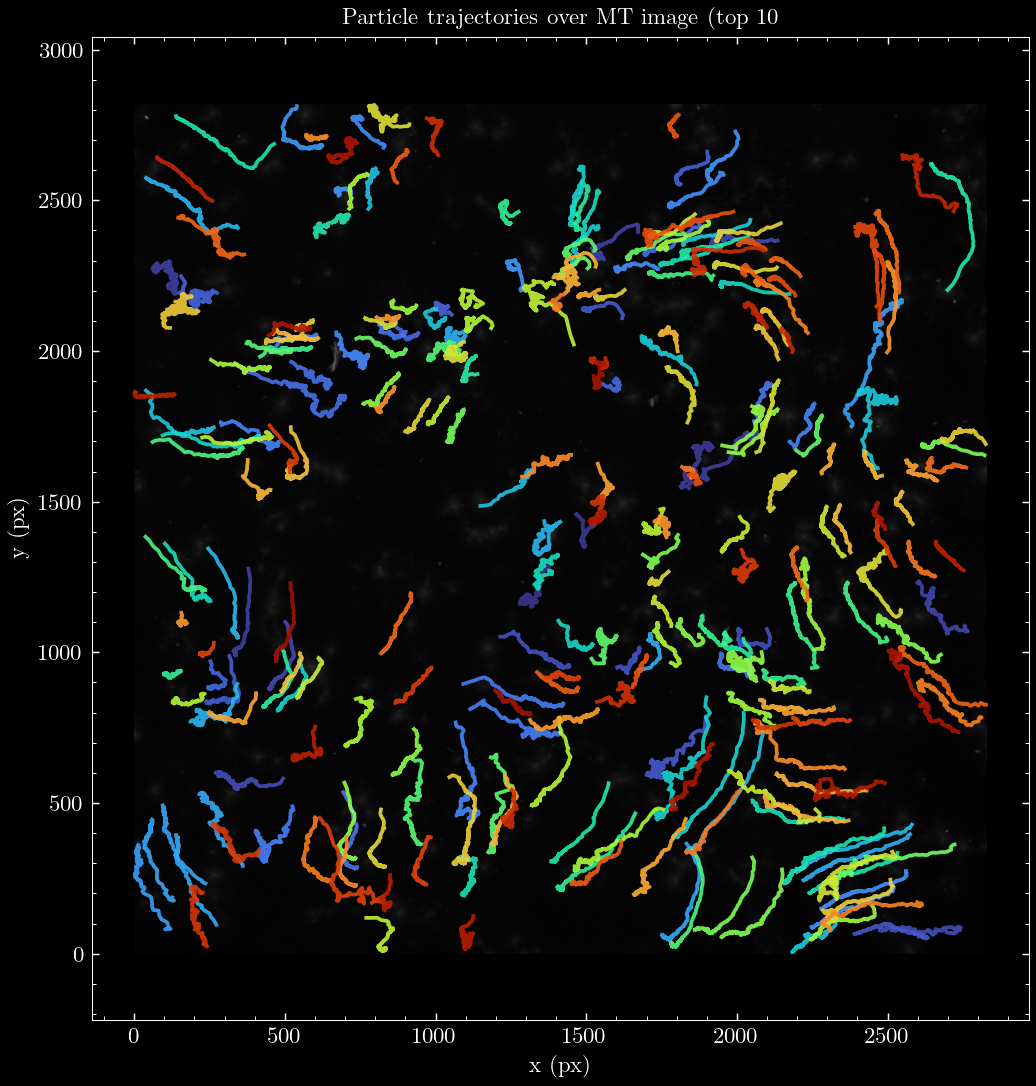

Plotted all particle trajectories: 277
Kept the longest tracks for the top 11 % of particles
Saved trajectory overlay to plots/AMF_107_002__C640_C470/AMF_107_002__C640_C470_all_particle_trajectories_over_mt_black.pdf


In [ ]:
if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0 or 'particle' not in tracks_vel_df.columns or not {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
    print('No particle trajectories available for plotting')
else:
    if 'data_state' not in globals() or data_state is None:
        data_state = load_dataset_state(config['dataset'], verbose=True)

    bead_channel = int(config['beads'].get('channel_to_use', 1))
    mt_channel = 0 if bead_channel != 0 else 1
    frame_to_show = 0
    mt_image = data_state['images'][frame_to_show, mt_channel]
    mt_image = mt_image.compute() if hasattr(mt_image, 'compute') else mt_image
    mt_image = np.asarray(mt_image, dtype=float)
    if mt_image.ndim == 3:
        mt_image = mt_image.max(axis=0)
    elif mt_image.ndim != 2:
        raise ValueError(f'Unexpected mt image shape: {mt_image.shape}')

    trajectory_counts = tracks_vel_df.groupby('particle').size().sort_values(ascending=False)
    n_particles_total = int(len(trajectory_counts))
    n_particles_keep = max(1, int(np.ceil(n_particles_total * 0.10)))
    selected_particles = trajectory_counts.index[:n_particles_keep].tolist()
    traj_df = tracks_vel_df[tracks_vel_df['particle'].isin(selected_particles)].copy()
    traj_df = traj_df.sort_values(['particle', 'frame'])

    fig_traj, ax_traj = plt.subplots(figsize=(8.4, 7.2), dpi=150)
    ax_traj.imshow(mt_image, cmap='gray', alpha=0.95)

    particles = selected_particles
    colors = plt.get_cmap('turbo')(np.linspace(0.05, 0.95, max(len(particles), 2))) if len(particles) > 1 else np.array([tum_colors[0]])

    for idx, particle_id in enumerate(particles):
        particle_df = traj_df[traj_df['particle'] == particle_id].sort_values('frame')
        if len(particle_df) == 0:
            continue

        x_vals = particle_df['x_um'].to_numpy(dtype=float) * px_per_micron
        y_vals = particle_df['y_um'].to_numpy(dtype=float) * px_per_micron
        valid = np.isfinite(x_vals) & np.isfinite(y_vals)
        x_vals = x_vals[valid]
        y_vals = y_vals[valid]
        if len(x_vals) < 2:
            continue

        color = colors[idx % len(colors)]
        ax_traj.plot(x_vals, y_vals, lw=1.8, color=color, alpha=0.9, zorder=3)

    ax_traj.set_xlabel('x (px)')
    ax_traj.set_ylabel('y (px)')
    ax_traj.set_title(f'Particle trajectories over MT image (top {int(np.round(100 * n_particles_keep / n_particles_total))}% longest tracks)')
    ax_traj.set_aspect('equal', adjustable='box')
    ax_traj.grid(False)
    _apply_data_limits(ax_traj, traj_df['x_um'] * px_per_micron, traj_df['y_um'] * px_per_micron)
    plt.tight_layout()
    plt.show()

    _save_dual_pdf(fig_traj, f'{dataset_id}_all_particle_trajectories_over_mt')

    def _trajectories_white(ax):
        ax.imshow(mt_image, cmap='gray', alpha=0.95)
        for idx, particle_id in enumerate(particles):
            particle_df = traj_df[traj_df['particle'] == particle_id].sort_values('frame')
            if len(particle_df) == 0:
                continue
            x_vals = particle_df['x_um'].to_numpy(dtype=float) * px_per_micron
            y_vals = particle_df['y_um'].to_numpy(dtype=float) * px_per_micron
            valid = np.isfinite(x_vals) & np.isfinite(y_vals)
            x_vals = x_vals[valid]
            y_vals = y_vals[valid]
            if len(x_vals) < 2:
                continue
            color = colors[idx % len(colors)]
            ax.plot(x_vals, y_vals, lw=1.8, color=color, alpha=0.9)
        ax.set_xlabel('x (px)')
        ax.set_ylabel('y (px)')
        ax.set_aspect('equal', adjustable='box')
        ax.grid(False)
        _apply_data_limits(ax, traj_df['x_um'] * px_per_micron, traj_df['y_um'] * px_per_micron)

    _save_dual_replot(f'{dataset_id}_all_particle_trajectories_over_mt', _trajectories_white)

    print('Plotted all particle trajectories:', len(particles))
    print('Kept the longest tracks for the top', int(np.ceil(100 * n_particles_keep / n_particles_total)), '% of particles')
    print('Saved trajectory overlay to', plot_dir / f'{dataset_id}_all_particle_trajectories_over_mt_black.pdf')

## 10.3. Trajectory Alignment with Theta vs Radius

This subsection measures how strongly the selected trajectories align with the tangential theta direction as a function of radius.

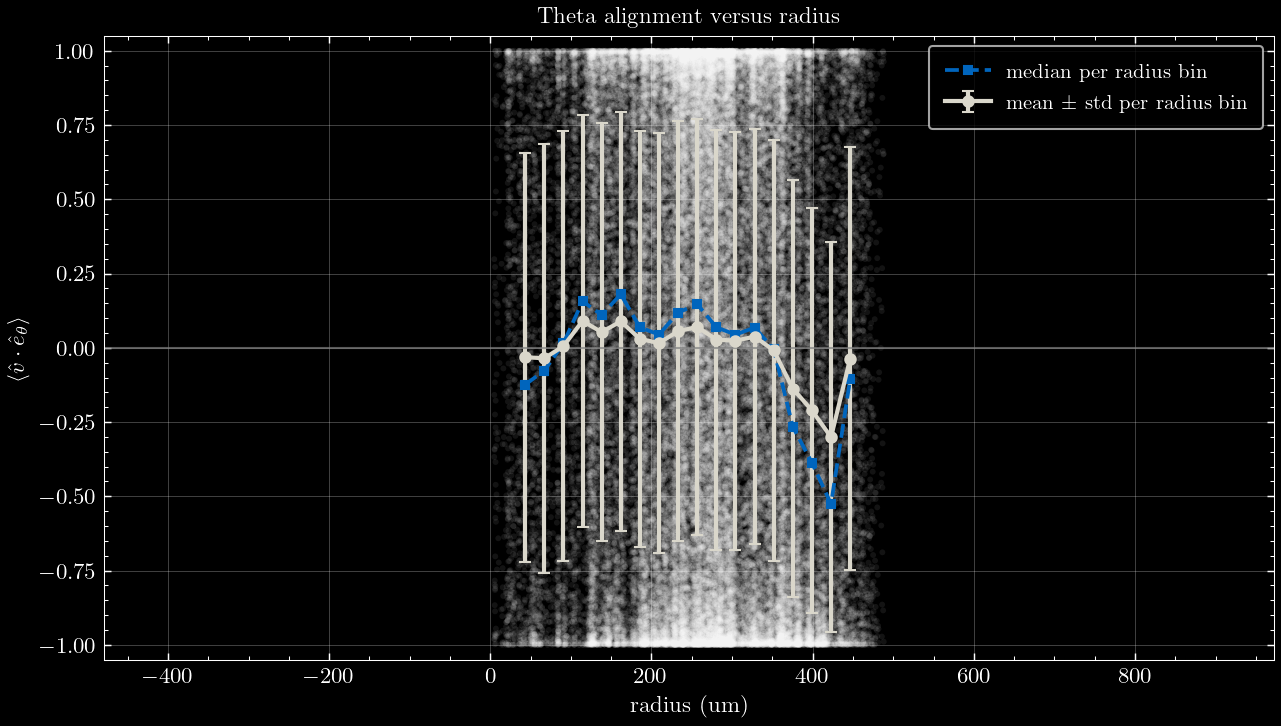

,radius_bin,mean_alignment,median_alignment,std_alignment,n_points,radius_bin_center_um
0,"(31.465, 55.188]",-0.031662,-0.123811,0.688133,810,43.3265
1,"(55.188, 78.909]",-0.035285,-0.077040,0.721656,642,67.0485
2,"(78.909, 102.631]",0.005418,0.014843,0.724100,966,90.7700
3,"(102.631, 126.352]",0.090424,0.156869,0.694422,1546,114.4915
4,"(126.352, 150.074]",0.052642,0.110700,0.703096,2724,138.2130
5,"(150.074, 173.795]",0.089192,0.180139,0.705468,2094,161.9345
6,"(173.795, 197.517]",0.029759,0.069112,0.700750,3611,185.6560
7,"(197.517, 221.238]",0.016113,0.044273,0.705465,4013,209.3775
8,"(221.238, 244.96]",0.055689,0.118587,0.707657,6028,233.0990
9,"(244.96, 268.681]",0.070187,0.146594,0.698851,6460,256.8205


Theta-alignment radius points: 59501
Theta-alignment radius bins: 18
Mean theta alignment: 0.004919751671734811
Median theta alignment: 0.019871586346911607


In [ ]:
from analysis_pipeline.io_dataset import load_dataset_state

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0 or 'particle' not in tracks_vel_df.columns or not {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
    print('No particle trajectories available for radius-alignment plotting')
else:
    if 'data_state' not in globals() or data_state is None:
        data_state = load_dataset_state(config['dataset'], verbose=True)

    px_per_micron = float(data_state['calibration']['px_per_micron'])
    fps = float(data_state['calibration'].get('fps', config.get('dataset', {}).get('fps', 1.0)) or 1.0)
    origin_x_um = config['beads'].get('origin_x_um', None)
    origin_y_um = config['beads'].get('origin_y_um', None)
    if origin_x_um is None:
        origin_x_um = (float(data_state['dims']['X']) - 1.0) / (2.0 * px_per_micron)
    if origin_y_um is None:
        origin_y_um = (float(data_state['dims']['Y']) - 1.0) / (2.0 * px_per_micron)

    trajectory_counts = tracks_vel_df.groupby('particle').size().sort_values(ascending=False)
    n_particles_total = int(len(trajectory_counts))
    n_particles_keep = max(1, int(np.ceil(n_particles_total * 0.10)))
    selected_particles = trajectory_counts.index[:n_particles_keep].tolist()
    traj_df = tracks_vel_df[tracks_vel_df['particle'].isin(selected_particles)].copy()
    traj_df = traj_df.sort_values(['particle', 'frame'])

    if not {'vx_um_s', 'vy_um_s'}.issubset(traj_df.columns):
        print('Trajectory table is missing velocity components required for theta alignment')
    else:
        x_um = traj_df['x_um'].to_numpy(dtype=float)
        y_um = traj_df['y_um'].to_numpy(dtype=float)
        vx_um_s = traj_df['vx_um_s'].to_numpy(dtype=float)
        vy_um_s = traj_df['vy_um_s'].to_numpy(dtype=float)
        finite = np.isfinite(x_um) & np.isfinite(y_um) & np.isfinite(vx_um_s) & np.isfinite(vy_um_s)
        x_um = x_um[finite]
        y_um = y_um[finite]
        vx_um_s = vx_um_s[finite]
        vy_um_s = vy_um_s[finite]

        speed_xy = np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
        moving = speed_xy > 0
        x_um = x_um[moving]
        y_um = y_um[moving]
        vx_um_s = vx_um_s[moving]
        vy_um_s = vy_um_s[moving]

        if len(x_um) == 0:
            print('No moving trajectories available for theta alignment versus radius')
        else:
            theta_rad = np.arctan2(y_um - float(origin_y_um), x_um - float(origin_x_um))
            theta_hat_x = -np.sin(theta_rad)
            theta_hat_y = np.cos(theta_rad)
            v_hat_x = vx_um_s / np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
            v_hat_y = vy_um_s / np.sqrt(vx_um_s ** 2 + vy_um_s ** 2)
            theta_alignment = v_hat_x * theta_hat_x + v_hat_y * theta_hat_y
            radius_um = np.sqrt((x_um - float(origin_x_um)) ** 2 + (y_um - float(origin_y_um)) ** 2)

            radius_alignment_df = pd.DataFrame(
                {
                    'radius_um': radius_um,
                    'theta_alignment': theta_alignment,
                }
            ).replace([np.inf, -np.inf], np.nan).dropna()

            if len(radius_alignment_df) == 0:
                print('No finite values available for theta alignment versus radius')
            else:
                n_bins = min(18, max(8, int(np.ceil(np.sqrt(len(radius_alignment_df))))))
                radius_min = float(np.nanpercentile(radius_alignment_df['radius_um'], 1))
                radius_max = float(np.nanpercentile(radius_alignment_df['radius_um'], 99))
                if not np.isfinite(radius_min) or not np.isfinite(radius_max) or radius_max <= radius_min:
                    radius_min = float(np.nanmin(radius_alignment_df['radius_um']))
                    radius_max = float(np.nanmax(radius_alignment_df['radius_um']))

                if radius_max <= radius_min:
                    print('Radius range is too small to bin')
                else:
                    bin_edges = np.linspace(radius_min, radius_max, n_bins + 1)
                    radius_alignment_df['radius_bin'] = pd.cut(
                        radius_alignment_df['radius_um'],
                        bins=bin_edges,
                        include_lowest=True,
                        duplicates='drop',
                    )
                    radius_alignment_summary = (
                        radius_alignment_df.groupby('radius_bin', observed=True)
                        .agg(
                            mean_alignment=('theta_alignment', 'mean'),
                            median_alignment=('theta_alignment', 'median'),
                            std_alignment=('theta_alignment', 'std'),
                            n_points=('theta_alignment', 'size'),
                        )
                        .reset_index()
                    )
                    radius_alignment_summary['radius_bin_center_um'] = radius_alignment_summary['radius_bin'].apply(lambda interval: float(interval.mid))
                    radius_alignment_summary['std_alignment'] = radius_alignment_summary['std_alignment'].fillna(0.0)
                    radius_alignment_summary = radius_alignment_summary.sort_values('radius_bin_center_um').reset_index(drop=True)

                    fig_radius, ax_radius = plt.subplots(figsize=(8.5, 4.8), dpi=150)
                    ax_radius.scatter(
                        radius_alignment_df['radius_um'],
                        radius_alignment_df['theta_alignment'],
                        s=8,
                        color='white',
                        alpha=0.08,
                        edgecolors='none',
                        rasterized=True,
                    )
                    ax_radius.errorbar(
                        radius_alignment_summary['radius_bin_center_um'],
                        radius_alignment_summary['mean_alignment'],
                        yerr=radius_alignment_summary['std_alignment'],
                        fmt='o-',
                        color=tum_colors[4],
                        ecolor=tum_colors[4],
                        capsize=3,
                        lw=2.0,
                        ms=5,
                        label='mean ± std per radius bin',
                    )
                    ax_radius.plot(
                        radius_alignment_summary['radius_bin_center_um'],
                        radius_alignment_summary['median_alignment'],
                        color=tum_colors[1],
                        lw=1.8,
                        ls='--',
                        marker='s',
                        ms=4,
                        label='median per radius bin',
                    )
                    ax_radius.axhline(0.0, color='gray', lw=1.0, alpha=0.7)
                    ax_radius.set_xlabel('radius (um)')
                    ax_radius.set_ylabel(r'$\langle \hat{v} \cdot \hat{e}_\theta \rangle$')
                    ax_radius.set_title('Theta alignment versus radius')
                    ax_radius.set_ylim(-1.05, 1.05)
                    ax_radius.grid(True, alpha=0.25)
                    ax_radius.legend(loc='upper right', frameon=True, **_legend_scale(fig_radius))
                    plt.tight_layout()
                    plt.show()

                    _save_dual_pdf(fig_radius, f'{dataset_id}_trajectory_theta_alignment_by_radius')

                    def _radius_alignment_white(ax):
                        ax.scatter(
                            radius_alignment_df['radius_um'],
                            radius_alignment_df['theta_alignment'],
                            s=8,
                            color='0.3',
                            alpha=0.12,
                            edgecolors='none',
                            rasterized=True,
                        )
                        ax.errorbar(
                            radius_alignment_summary['radius_bin_center_um'],
                            radius_alignment_summary['mean_alignment'],
                            yerr=radius_alignment_summary['std_alignment'],
                            fmt='o-',
                            color=tum_colors[4],
                            ecolor=tum_colors[4],
                            capsize=3,
                            lw=2.0,
                            ms=5,
                            label='mean ± std per radius bin',
                        )
                        ax.plot(
                            radius_alignment_summary['radius_bin_center_um'],
                            radius_alignment_summary['median_alignment'],
                            color=tum_colors[1],
                            lw=1.8,
                            ls='--',
                            marker='s',
                            ms=4,
                            label='median per radius bin',
                        )
                        ax.axhline(0.0, color='gray', lw=1.0, alpha=0.7)
                        ax.set_xlabel('radius (um)')
                        ax.set_ylabel(r'$\langle \hat{v} \cdot \hat{e}_\theta \rangle$')
                        ax.set_ylim(-1.05, 1.05)
                        ax.grid(True, alpha=0.25)
                        ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_radius))

                    _save_dual_replot(f'{dataset_id}_trajectory_theta_alignment_by_radius', _radius_alignment_white)

                    display(radius_alignment_summary)
                    print('Theta-alignment radius points:', len(radius_alignment_df))
                    print('Theta-alignment radius bins:', len(radius_alignment_summary))
                    print('Mean theta alignment:', float(radius_alignment_df['theta_alignment'].mean()))
                    print('Median theta alignment:', float(radius_alignment_df['theta_alignment'].median()))

## 10.4. Endpoint-Based Angular Speed Distribution

This subsection uses only the 10% longest tracks and estimates the angular speed from each trajectory's start-to-end displacement.

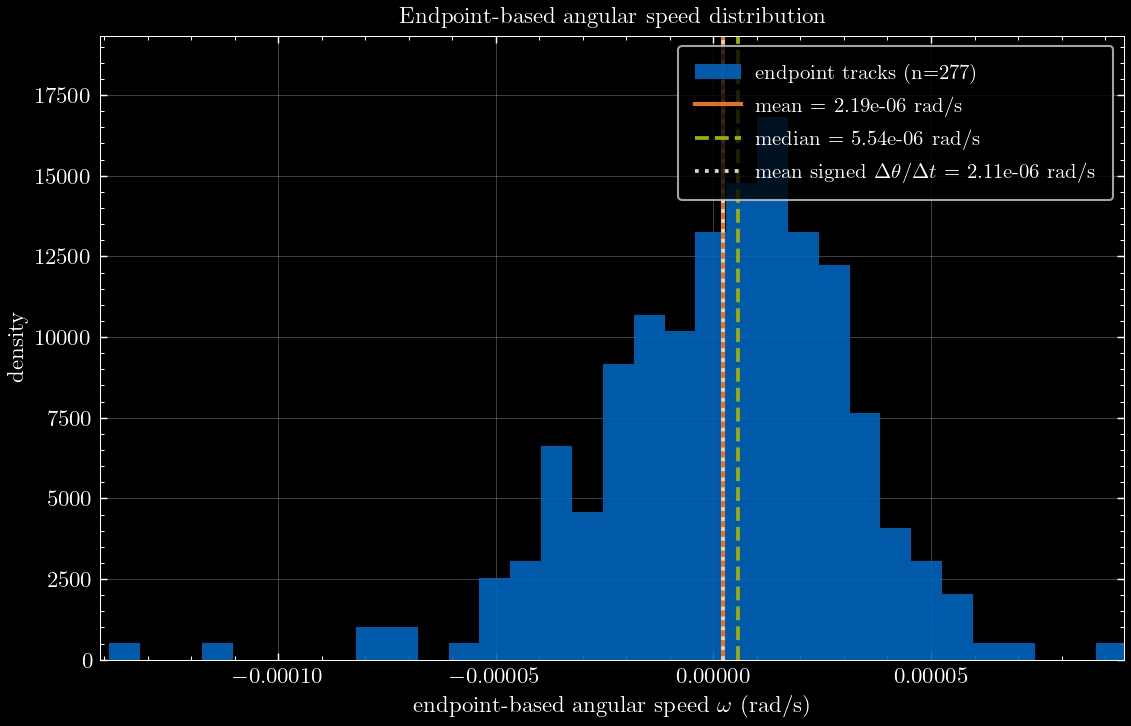

,particle,n_points,start_frame,end_frame,duration_s,trajectory_length_um,radius_mid_um,start_theta_rad,end_theta_rad,signed_angular_displacement_rad,tangential_displacement_um,omega_endpoint_rad_s,mean_angular_speed_from_displacement_rad_s,linear_speed_um_s
0,25,199,0,206,5065.92110,179.586754,285.700054,-2.464281,-2.436163,0.028118,8.013864,5.536983e-06,5.550384e-06,0.005836
1,29,222,0,221,5434.79885,108.515725,228.974448,-0.578842,-0.605491,-0.026649,-6.072613,-4.879835e-06,-4.903356e-06,0.005978
2,32,222,0,221,5434.79885,76.669815,360.203205,-2.777401,-2.780929,-0.003528,-1.270917,-6.492112e-07,-6.492124e-07,0.000322
3,33,219,0,221,5434.79885,121.048426,132.693276,-0.879032,-0.766919,0.112113,14.661515,2.033043e-05,2.062869e-05,0.006658
4,42,219,0,221,5434.79885,205.090854,224.617160,-0.441684,-0.125235,0.316449,71.354053,5.845104e-05,5.822644e-05,0.014288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,1060,199,22,221,4893.77815,207.541679,350.171093,-1.792394,-1.789783,0.002612,0.914051,5.333913e-07,5.336773e-07,0.003320
273,1062,199,22,221,4893.77815,217.163908,339.911520,-0.664238,-0.759695,-0.095457,-32.407667,-1.948218e-05,-1.950587e-05,0.009056
274,1070,199,23,221,4869.18630,84.832765,369.206523,2.829063,2.805351,-0.023713,-8.737906,-4.860508e-06,-4.869948e-06,0.006992
275,1083,198,24,221,4844.59445,174.946470,241.684819,-0.956650,-1.195882,-0.239232,-57.841295,-4.940048e-05,-4.938126e-05,0.013669


Endpoint tracks used: 277
Endpoint angular speed sample size: 277
Endpoint angular speed mean: 2.193781571668145e-06
Endpoint angular speed median: 5.5369831765017066e-06
Endpoint angular speed std: 3.347237026426697e-05
Mean signed angular displacement: 0.010697358571213933
Median signed angular displacement: 0.028117807618714963
Mean signed tangential displacement: 2.6128494657905743
Median signed tangential displacement: 6.491552791925168
Mean trajectory length: 140.03847474714192
Median trajectory length: 121.32671734755465
Mean signed angular speed from displacement: 2.1127475195079786e-06
Longest-track fraction used: 277 / 2761
Saved endpoint-based angular speed plot to plots/AMF_107_002__C640_C470/AMF_107_002__C640_C470_endpoint_based_angular_speed_distribution_black.pdf


In [ ]:
from analysis_pipeline.io_dataset import load_dataset_state

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if len(tracks_vel_df) == 0 or 'particle' not in tracks_vel_df.columns or not {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
    print('No particle trajectories available for endpoint-based angular speed plotting')
else:
    if 'data_state' not in globals() or data_state is None:
        data_state = load_dataset_state(config['dataset'], verbose=True)

    px_per_micron = float(data_state['calibration']['px_per_micron'])
    fps = float(data_state['calibration'].get('fps', config.get('dataset', {}).get('fps', 1.0)) or 1.0)
    origin_x_um = config['beads'].get('origin_x_um', None)
    origin_y_um = config['beads'].get('origin_y_um', None)
    if origin_x_um is None:
        origin_x_um = (float(data_state['dims']['X']) - 1.0) / (2.0 * px_per_micron)
    if origin_y_um is None:
        origin_y_um = (float(data_state['dims']['Y']) - 1.0) / (2.0 * px_per_micron)

    trajectory_counts = tracks_vel_df.groupby('particle').size().sort_values(ascending=False)
    n_particles_total = int(len(trajectory_counts))
    n_particles_keep = max(1, int(np.ceil(n_particles_total * 0.10)))
    selected_particles = trajectory_counts.index[:n_particles_keep].tolist()
    traj_df = tracks_vel_df[tracks_vel_df['particle'].isin(selected_particles)].copy()
    traj_df = traj_df.sort_values(['particle', 'frame'])

    endpoint_rows = []
    for particle_id, particle_df in traj_df.groupby('particle', sort=False):
        particle_df = particle_df.sort_values('frame')
        particle_df = particle_df[np.isfinite(particle_df['x_um']) & np.isfinite(particle_df['y_um']) & np.isfinite(particle_df['frame'])]
        if len(particle_df) < 2:
            continue

        start_row = particle_df.iloc[0]
        end_row = particle_df.iloc[-1]
        duration_s = (float(end_row['frame']) - float(start_row['frame'])) / fps if fps > 0 else np.nan
        if not np.isfinite(duration_s) or duration_s <= 0:
            continue

        start_xy = np.array([float(start_row['x_um']), float(start_row['y_um'])], dtype=float)
        end_xy = np.array([float(end_row['x_um']), float(end_row['y_um'])], dtype=float)
        displacement_xy = end_xy - start_xy
        midpoint_xy = 0.5 * (start_xy + end_xy)
        midpoint_radius = float(np.hypot(midpoint_xy[0] - float(origin_x_um), midpoint_xy[1] - float(origin_y_um)))
        if not np.isfinite(midpoint_radius) or midpoint_radius <= 0:
            continue

        start_theta = float(np.arctan2(start_xy[1] - float(origin_y_um), start_xy[0] - float(origin_x_um)))
        end_theta = float(np.arctan2(end_xy[1] - float(origin_y_um), end_xy[0] - float(origin_x_um)))
        signed_angular_displacement_rad = float(np.arctan2(np.sin(end_theta - start_theta), np.cos(end_theta - start_theta)))
        midpoint_theta = float(np.arctan2(midpoint_xy[1] - float(origin_y_um), midpoint_xy[0] - float(origin_x_um)))
        theta_hat_xy = np.array([-np.sin(midpoint_theta), np.cos(midpoint_theta)], dtype=float)
        tangential_displacement_um = float(np.dot(displacement_xy, theta_hat_xy))
        omega_endpoint_rad_s = tangential_displacement_um / (midpoint_radius * duration_s)
        mean_angular_speed_from_displacement_rad_s = signed_angular_displacement_rad / duration_s
        linear_speed_um_s = float(np.linalg.norm(displacement_xy) / duration_s)

        trajectory_length_um = 0.0
        if len(particle_df) >= 2:
            particle_xy = particle_df[['x_um', 'y_um']].to_numpy(dtype=float)
            diffs = np.diff(particle_xy, axis=0)
            segment_lengths = np.linalg.norm(diffs, axis=1)
            trajectory_length_um = float(np.nansum(segment_lengths))

        endpoint_rows.append(
            {
                'particle': int(particle_id),
                'n_points': int(len(particle_df)),
                'start_frame': int(start_row['frame']),
                'end_frame': int(end_row['frame']),
                'duration_s': float(duration_s),
                'trajectory_length_um': trajectory_length_um,
                'radius_mid_um': midpoint_radius,
                'start_theta_rad': start_theta,
                'end_theta_rad': end_theta,
                'signed_angular_displacement_rad': signed_angular_displacement_rad,
                'tangential_displacement_um': tangential_displacement_um,
                'omega_endpoint_rad_s': omega_endpoint_rad_s,
                'mean_angular_speed_from_displacement_rad_s': mean_angular_speed_from_displacement_rad_s,
                'linear_speed_um_s': linear_speed_um_s,
            }
        )

    endpoint_df = pd.DataFrame(endpoint_rows)
    if len(endpoint_df) == 0:
        print('No valid endpoint-based angular speeds could be computed')
    else:
        omega_vals = endpoint_df['omega_endpoint_rad_s'].to_numpy(dtype=float)
        omega_vals = omega_vals[np.isfinite(omega_vals)]
        if omega_vals.size == 0:
            print('No finite endpoint-based angular speeds available for plotting')
        else:
            omega_mean = float(np.mean(omega_vals))
            omega_median = float(np.median(omega_vals))
            omega_std = float(np.std(omega_vals, ddof=1)) if omega_vals.size > 1 else 0.0
            signed_displacement_vals = endpoint_df['signed_angular_displacement_rad'].to_numpy(dtype=float)
            signed_displacement_vals = signed_displacement_vals[np.isfinite(signed_displacement_vals)]
            tangential_displacement_vals = endpoint_df['tangential_displacement_um'].to_numpy(dtype=float)
            tangential_displacement_vals = tangential_displacement_vals[np.isfinite(tangential_displacement_vals)]
            trajectory_length_vals = endpoint_df['trajectory_length_um'].to_numpy(dtype=float)
            trajectory_length_vals = trajectory_length_vals[np.isfinite(trajectory_length_vals)]
            mean_signed_displacement_rad = float(np.mean(signed_displacement_vals)) if signed_displacement_vals.size > 0 else np.nan
            median_signed_displacement_rad = float(np.median(signed_displacement_vals)) if signed_displacement_vals.size > 0 else np.nan
            mean_signed_tangential_displacement_um = float(np.mean(tangential_displacement_vals)) if tangential_displacement_vals.size > 0 else np.nan
            median_signed_tangential_displacement_um = float(np.median(tangential_displacement_vals)) if tangential_displacement_vals.size > 0 else np.nan
            mean_trajectory_length_um = float(np.mean(trajectory_length_vals)) if trajectory_length_vals.size > 0 else np.nan
            median_trajectory_length_um = float(np.median(trajectory_length_vals)) if trajectory_length_vals.size > 0 else np.nan
            mean_signed_angular_speed_rad_s = float(np.mean(endpoint_df['mean_angular_speed_from_displacement_rad_s'].to_numpy(dtype=float))) if 'mean_angular_speed_from_displacement_rad_s' in endpoint_df.columns else np.nan

            fig_omega_endpoint, ax_omega_endpoint = plt.subplots(figsize=(7.5, 4.8), dpi=150)
            hist_vals, hist_bins, _ = ax_omega_endpoint.hist(
                omega_vals,
                bins=40,
                density=True,
                color=tum_colors[1],
                alpha=0.9,
                label=f'endpoint tracks (n={omega_vals.size})',
            )
            ax_omega_endpoint.axvline(
                omega_mean,
                color=tum_colors[0],
                lw=2.0,
                label=rf'mean = {omega_mean:.3g} rad/s',
            )
            ax_omega_endpoint.axvline(
                omega_median,
                color=tum_colors[2],
                lw=1.8,
                ls='--',
                label=rf'median = {omega_median:.3g} rad/s',
            )
            if np.isfinite(mean_signed_angular_speed_rad_s):
                ax_omega_endpoint.axvline(
                    mean_signed_angular_speed_rad_s,
                    color=tum_colors[4],
                    lw=1.8,
                    ls=':',
                    label=rf'mean signed $\Delta\theta/\Delta t$ = {mean_signed_angular_speed_rad_s:.3g} rad/s',
                )
            ax_omega_endpoint.set_xlabel(r'endpoint-based angular speed $\omega$ (rad/s)')
            ax_omega_endpoint.set_ylabel('density')
            ax_omega_endpoint.set_title('Endpoint-based angular speed distribution')
            ax_omega_endpoint.grid(True, alpha=0.25)
            if omega_vals.size > 1:
                x_min, x_max = np.nanpercentile(omega_vals, [1, 99])
                if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
                    pad = 0.1 * (x_max - x_min)
                    ax_omega_endpoint.set_xlim(x_min - pad, x_max + pad)
            if hist_vals.size > 0:
                ax_omega_endpoint.set_ylim(0.0, max(float(hist_vals.max()) * 1.15, 1e-6))
            ax_omega_endpoint.legend(loc='upper right', frameon=True, **_legend_scale(fig_omega_endpoint))
            plt.tight_layout()
            plt.show()

            _save_dual_pdf(fig_omega_endpoint, f'{dataset_id}_endpoint_based_angular_speed_distribution')

            def _endpoint_omega_white(ax):
                ax.hist(
                    omega_vals,
                    bins=40,
                    density=True,
                    color=tum_colors[1],
                    alpha=0.9,
                    label=f'endpoint tracks (n={omega_vals.size})',
                )
                ax.axvline(
                    omega_mean,
                    color=tum_colors[0],
                    lw=2.0,
                    label=rf'mean = {omega_mean:.3g} rad/s',
                )
                ax.axvline(
                    omega_median,
                    color=tum_colors[2],
                    lw=1.8,
                    ls='--',
                    label=rf'median = {omega_median:.3g} rad/s',
                )
                if np.isfinite(mean_signed_angular_speed_rad_s):
                    ax.axvline(
                        mean_signed_angular_speed_rad_s,
                        color=tum_colors[4],
                        lw=1.8,
                        ls=':',
                        label=rf'mean signed $\Delta\theta/\Delta t$ = {mean_signed_angular_speed_rad_s:.3g} rad/s',
                    )
                ax.set_xlabel(r'endpoint-based angular speed $\omega$ (rad/s)')
                ax.set_ylabel('density')
                ax.grid(True, alpha=0.25)
                if omega_vals.size > 1:
                    x_min, x_max = np.nanpercentile(omega_vals, [1, 99])
                    if np.isfinite(x_min) and np.isfinite(x_max) and x_max > x_min:
                        pad = 0.1 * (x_max - x_min)
                        ax.set_xlim(x_min - pad, x_max + pad)
                if hist_vals.size > 0:
                    ax.set_ylim(0.0, max(float(hist_vals.max()) * 1.15, 1e-6))
                ax.legend(loc='upper right', frameon=True, **_legend_scale(fig_omega_endpoint))

            _save_dual_replot(f'{dataset_id}_endpoint_based_angular_speed_distribution', _endpoint_omega_white)

            display(endpoint_df)
            print('Endpoint tracks used:', len(endpoint_df))
            print('Endpoint angular speed sample size:', omega_vals.size)
            print('Endpoint angular speed mean:', omega_mean)
            print('Endpoint angular speed median:', omega_median)
            print('Endpoint angular speed std:', omega_std)
            print('Mean signed angular displacement:', mean_signed_displacement_rad)
            print('Median signed angular displacement:', median_signed_displacement_rad)
            print('Mean signed tangential displacement:', mean_signed_tangential_displacement_um)
            print('Median signed tangential displacement:', median_signed_tangential_displacement_um)
            print('Mean trajectory length:', mean_trajectory_length_um)
            print('Median trajectory length:', median_trajectory_length_um)
            print('Mean signed angular speed from displacement:', mean_signed_angular_speed_rad_s)
            print('Longest-track fraction used:', n_particles_keep, '/', n_particles_total)
            print('Saved endpoint-based angular speed plot to', plot_dir / f'{dataset_id}_endpoint_based_angular_speed_distribution_black.pdf')

## 10.5. Concentration Comparison

This section uses a config-driven registry to compare concentration runs with shared styling, normalized summary tables, and dual black/white exports.

In [ ]:
comparison_cfg = dict(config.get('comparison', {}))
comparison_enabled = bool(comparison_cfg.get('enabled', False))
comparison_name = str(comparison_cfg.get('name', 'concentration_comparison')).strip() or 'concentration_comparison'
comparison_variation = str(comparison_cfg.get('variation', config['dataset'].get('variation', ''))).strip()
comparison_output_root = Path(comparison_cfg.get('output_root', 'plots/comparisons'))
comparison_dir = comparison_output_dir(comparison_output_root, comparison_name, comparison_variation)
comparison_tables_dir = comparison_dir / 'tables'
comparison_tables_dir.mkdir(parents=True, exist_ok=True)

comparison_specs = comparison_registry_from_config(comparison_cfg) if comparison_enabled else []
comparison_registry_df = pd.DataFrame(
    [
        {
            'dataset_id': spec.dataset_id,
            'label': spec.label,
            'color': spec.color,
            'group': spec.group,
            'replicate': spec.replicate,
            'variation': spec.variation,
            'base_dir': spec.base_dir,
        }
        for spec in comparison_specs
    ]
) if comparison_specs else pd.DataFrame(
    columns=['dataset_id', 'label', 'color', 'group', 'replicate', 'variation', 'base_dir']
)

def _comparison_run_dir(spec: ComparisonSpec) -> Path:
    base_dir = Path(spec.base_dir) if spec.base_dir else Path('data')
    return base_dir / spec.dataset_id / 'derived'


def _comparison_artifact_path(spec: ComparisonSpec, filename: str) -> Path:
    return _comparison_run_dir(spec) / filename

print('Comparison enabled:', comparison_enabled)
print('Comparison name:', comparison_name)
print('Comparison output dir:', comparison_dir)
print('Comparison datasets:', len(comparison_specs))
if len(comparison_registry_df):
    display(comparison_registry_df)
else:
    print('No comparison registry entries configured')

Comparison enabled: True
Comparison name: concentration_comparison
Comparison output dir: plots/comparisons/concentration_comparison
Comparison datasets: 8


,dataset_id,label,color,group,replicate,variation,base_dir
0,AMF_088_002__C640_C470,2 mM ATP,#08306b,ATP,r1,,data
1,AMF_101_002__C640_C470,0.6 mM ATP,#08519c,ATP,r2,,data
2,AMF_089_003__C640_C470,0.2 mM ATP,#2171b5,ATP,r3,,data
3,AMF_090_003__C640_C470,0.02 mM ATP,#6baed6,ATP,r4,,data
4,AMF_092_002__C640_C470,0.1 µM PRC,#a6dba0,PRC,r1,,data
5,AMF_088_002__C640_C470,0.3 µM PRC,#5aae61,PRC,r2,,data
6,AMF_091_002__C640_C470,0.6 µM PRC,#1b7837,PRC,r3,,data
7,AMF_093_002__C640_C470,2.0 µM PRC,#00441b,PRC,r4,,data


In [ ]:
comparison_tables = []
comparison_table_map = {}
comparison_payload_map = {}
comparison_summary_df = pd.DataFrame()


def _finite_values(frame: pd.DataFrame, column: str) -> np.ndarray:
    if len(frame) == 0 or column not in frame.columns:
        return np.array([])
    values = frame[column].to_numpy(dtype=float)
    return values[np.isfinite(values)]


def _summary_stats(values: np.ndarray) -> dict[str, float | int]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {
            'n': 0,
            'mean': np.nan,
            'median': np.nan,
            'std': np.nan,
            'min': np.nan,
            'max': np.nan,
        }
    return {
        'n': int(values.size),
        'mean': float(np.mean(values)),
        'median': float(np.median(values)),
        'std': float(np.std(values, ddof=1)) if values.size > 1 else 0.0,
        'min': float(np.min(values)),
        'max': float(np.max(values)),
    }


if not comparison_enabled or not comparison_specs:
    print('Comparison is disabled or the registry is empty; skipping comparison compute.')
else:
    for idx, spec in enumerate(comparison_specs, start=1):
        run_dir = _comparison_run_dir(spec)
        tracks_path = _comparison_artifact_path(spec, 'beads_tracks_with_velocity.parquet')
        ac3d_path = _comparison_artifact_path(spec, 'autocorr_3d_sampled.parquet')

        tracks_df = pd.read_parquet(tracks_path) if tracks_path.exists() else pd.DataFrame()
        ac3d_df = pd.read_parquet(ac3d_path) if ac3d_path.exists() else pd.DataFrame()

        speed_vals = _finite_values(tracks_df, 'speed_um_s')
        xi_vals = _finite_values(ac3d_df, 'xi_um')

        speed_stats = _summary_stats(speed_vals)
        xi_stats = _summary_stats(xi_vals)
        comparison_key = f"{(spec.group or spec.variation or 'ungrouped').upper()}::{spec.dataset_id}"

        table_row = {
            'comparison_key': comparison_key,
            'dataset_id': spec.dataset_id,
            'label': spec.label,
            'color': spec.color,
            'group': spec.group,
            'replicate': spec.replicate,
            'variation': spec.variation,
            'base_dir': spec.base_dir,
            'derived_dir': str(run_dir),
            'speed_n': speed_stats['n'],
            'speed_mean': speed_stats['mean'],
            'speed_median': speed_stats['median'],
            'speed_std': speed_stats['std'],
            'speed_min': speed_stats['min'],
            'speed_max': speed_stats['max'],
            'xi3d_n': xi_stats['n'],
            'xi3d_mean': xi_stats['mean'],
            'xi3d_median': xi_stats['median'],
            'xi3d_std': xi_stats['std'],
            'xi3d_min': xi_stats['min'],
            'xi3d_max': xi_stats['max'],
        }
        table = pd.DataFrame([table_row])
        comparison_tables.append(table)
        comparison_table_map[comparison_key] = table
        comparison_payload_map[comparison_key] = {
            'spec': spec,
            'speed_vals': speed_vals,
            'xi_vals': xi_vals,
            'comparison_key': comparison_key,
        }
        print(
            f'[{idx}/{len(comparison_specs)}] {comparison_key}: '
            f'speed n={speed_stats["n"]}, xi n={xi_stats["n"]}'
        )

    comparison_summary_df = pd.concat(comparison_tables, ignore_index=True) if comparison_tables else pd.DataFrame()
    display(comparison_summary_df)
    print('Comparison summary rows:', len(comparison_summary_df))

[1/8] ATP::AMF_088_002__C640_C470: speed n=54134, xi n=0
[2/8] ATP::AMF_101_002__C640_C470: speed n=109557, xi n=0
[3/8] ATP::AMF_089_003__C640_C470: speed n=66826, xi n=0
[4/8] ATP::AMF_090_003__C640_C470: speed n=55928, xi n=0
[5/8] PRC::AMF_092_002__C640_C470: speed n=71263, xi n=0
[6/8] PRC::AMF_088_002__C640_C470: speed n=54134, xi n=0
[7/8] PRC::AMF_091_002__C640_C470: speed n=85470, xi n=0
[8/8] PRC::AMF_093_002__C640_C470: speed n=123311, xi n=0


,comparison_key,dataset_id,label,color,group,replicate,variation,base_dir,derived_dir,speed_n,speed_mean,speed_median,speed_std,speed_min,speed_max,xi3d_n,xi3d_mean,xi3d_median,xi3d_std,xi3d_min,xi3d_max
0,ATP::AMF_088_002__C640_C470,AMF_088_002__C640_C470,2 mM ATP,#08306b,ATP,r1,,data,data/AMF_088_002__C640_C470/derived,54134,0.299626,0.292462,0.123255,0.006482,0.809384,0,NaN,NaN,NaN,NaN,NaN
1,ATP::AMF_101_002__C640_C470,AMF_101_002__C640_C470,0.6 mM ATP,#08519c,ATP,r2,,data,data/AMF_101_002__C640_C470/derived,109557,0.123169,0.117086,0.055752,0.001522,0.392565,0,NaN,NaN,NaN,NaN,NaN
2,ATP::AMF_089_003__C640_C470,AMF_089_003__C640_C470,0.2 mM ATP,#2171b5,ATP,r3,,data,data/AMF_089_003__C640_C470/derived,66826,0.182444,0.176864,0.076970,0.005871,0.405232,0,NaN,NaN,NaN,NaN,NaN
3,ATP::AMF_090_003__C640_C470,AMF_090_003__C640_C470,0.02 mM ATP,#6baed6,ATP,r4,,data,data/AMF_090_003__C640_C470/derived,55928,0.195544,0.190737,0.080435,0.005577,0.405098,0,NaN,NaN,NaN,NaN,NaN
4,PRC::AMF_092_002__C640_C470,AMF_092_002__C640_C470,0.1 µM PRC,#a6dba0,PRC,r1,,data,data/AMF_092_002__C640_C470/derived,71263,0.292266,0.282643,0.124465,0.005964,0.812772,0,NaN,NaN,NaN,NaN,NaN
5,PRC::AMF_088_002__C640_C470,AMF_088_002__C640_C470,0.3 µM PRC,#5aae61,PRC,r2,,data,data/AMF_088_002__C640_C470/derived,54134,0.299626,0.292462,0.123255,0.006482,0.809384,0,NaN,NaN,NaN,NaN,NaN
6,PRC::AMF_091_002__C640_C470,AMF_091_002__C640_C470,0.6 µM PRC,#1b7837,PRC,r3,,data,data/AMF_091_002__C640_C470/derived,85470,0.223585,0.221620,0.090633,0.004038,0.406889,0,NaN,NaN,NaN,NaN,NaN
7,PRC::AMF_093_002__C640_C470,AMF_093_002__C640_C470,2.0 µM PRC,#00441b,PRC,r4,,data,data/AMF_093_002__C640_C470/derived,123311,0.012800,0.010716,0.013839,0.000000,0.798024,0,NaN,NaN,NaN,NaN,NaN


Comparison summary rows: 8


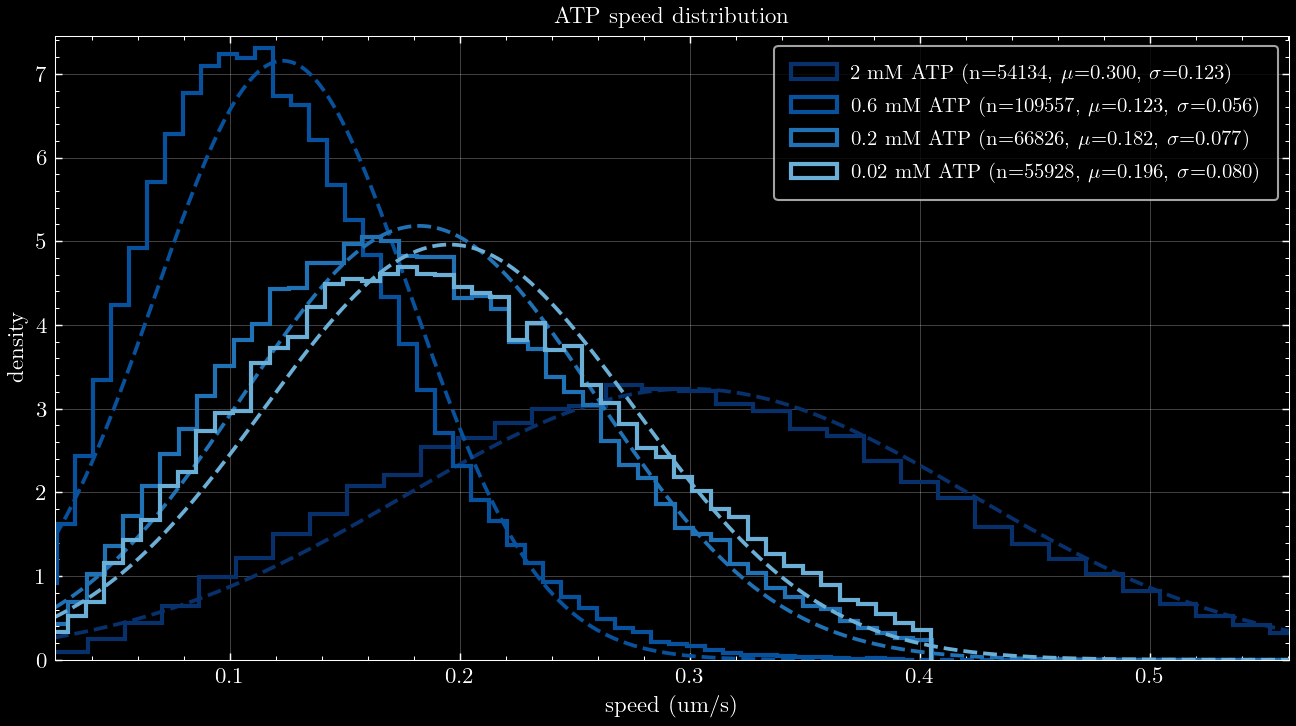

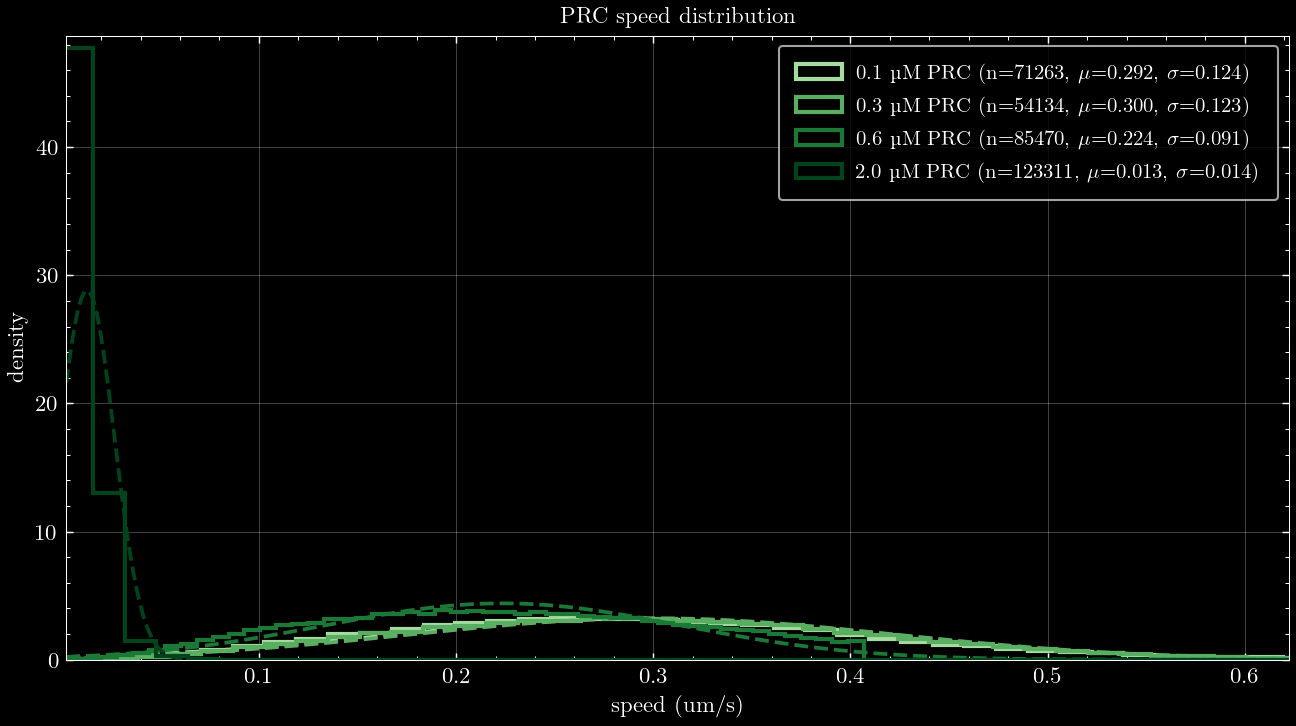

No finite xi values available for the sampled 3D decay length comparison; skipping that plot.
Saved comparison plots to plots/comparisons/concentration_comparison/plots


In [ ]:
comparison_plot_dir = comparison_dir / 'plots'
comparison_plot_dir.mkdir(parents=True, exist_ok=True)


def _shared_percentile_limits(arrays, lower=1.0, upper=99.0):
    values = [np.asarray(array, dtype=float).ravel() for array in arrays if array is not None]
    values = [array[np.isfinite(array)] for array in values if array.size]
    if not values:
        return None
    merged = np.concatenate(values)
    if merged.size == 0:
        return None
    lo, hi = np.nanpercentile(merged, [lower, upper])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None
    return float(lo), float(hi)


if not comparison_enabled or not comparison_specs or comparison_summary_df.empty:
    print('No comparison summary available for plotting')
else:
    comparison_order = [
        f"{str(row.group).upper()}::{row.dataset_id}"
        for row in comparison_summary_df.itertuples(index=False)
        if isinstance(row.dataset_id, str)
    ]
    comparison_plot_df = comparison_summary_df.set_index('comparison_key').loc[comparison_order].reset_index()
    comparison_colors = comparison_plot_df['color'].tolist()
    comparison_labels = comparison_plot_df['label'].tolist()

    xi_errors = comparison_plot_df['xi3d_std'].fillna(0.0).to_numpy(dtype=float)

    for group_name in [group for group in ('ATP', 'PRC') if group in set(comparison_plot_df['group'].astype(str).str.upper())]:
        group_df = comparison_plot_df.loc[comparison_plot_df['group'].astype(str).str.upper() == group_name].copy()
        if group_df.empty:
            continue

        group_keys = group_df['comparison_key'].tolist()
        group_labels = group_df['label'].tolist()
        group_colors = group_df['color'].tolist()
        speed_arrays = [comparison_payload_map[key]['speed_vals'] for key in group_keys if key in comparison_payload_map]
        speed_limits = _shared_percentile_limits(speed_arrays, lower=0.5, upper=99.5)

        fig_speed_cmp, ax_speed_cmp = plt.subplots(figsize=(8.6, 4.8), dpi=150)
        group_y_max = 0.0
        for key, label, color in zip(group_keys, group_labels, group_colors):
            payload = comparison_payload_map.get(key)
            if payload is None:
                continue
            vals = payload['speed_vals']
            if vals.size == 0:
                continue
            mu, sigma = norm.fit(vals)
            speed_x = np.linspace(speed_limits[0], speed_limits[1], 400) if speed_limits is not None else np.linspace(float(np.nanmin(vals)), float(np.nanmax(vals)), 400)
            fit_pdf = norm.pdf(speed_x, loc=mu, scale=sigma) if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0 else None
            hist_vals, _, _ = ax_speed_cmp.hist(
                vals,
                bins=50,
                density=True,
                histtype='step',
                lw=2.0,
                color=color,
                label=f"{label} (n={vals.size}, $\mu$={mu:.3f}, $\sigma$={sigma:.3f})",
            )
            group_y_max = max(group_y_max, float(np.nanmax(hist_vals)) if np.size(hist_vals) else 0.0)
            if fit_pdf is not None:
                ax_speed_cmp.plot(speed_x, fit_pdf, linestyle='--', lw=1.8, color=color, label='_nolegend_')
                group_y_max = max(group_y_max, float(np.nanmax(fit_pdf)))
        if speed_limits is not None:
            ax_speed_cmp.set_xlim(*speed_limits)
        if np.isfinite(group_y_max) and group_y_max > 0:
            ax_speed_cmp.set_ylim(0.0, float(group_y_max) * 1.02)
        ax_speed_cmp.set_xlabel('speed (um/s)')
        ax_speed_cmp.set_ylabel('density')
        ax_speed_cmp.set_title(f'{group_name} speed distribution')
        ax_speed_cmp.grid(True, alpha=0.25)
        ax_speed_cmp.legend(loc='upper right', frameon=True, **comparison_legend_kwargs(fig_speed_cmp))
        plt.tight_layout()
        plt.show()

        def _speed_white(ax):
            white_group_y_max = 0.0
            for key, label, color in zip(group_keys, group_labels, group_colors):
                payload = comparison_payload_map.get(key)
                if payload is None:
                    continue
                vals = payload['speed_vals']
                if vals.size == 0:
                    continue
                mu, sigma = norm.fit(vals)
                speed_x = np.linspace(speed_limits[0], speed_limits[1], 400) if speed_limits is not None else np.linspace(float(np.nanmin(vals)), float(np.nanmax(vals)), 400)
                fit_pdf = norm.pdf(speed_x, loc=mu, scale=sigma) if np.isfinite(mu) and np.isfinite(sigma) and sigma > 0 else None
                hist_vals, _, _ = ax.hist(
                    vals,
                    bins=50,
                    density=True,
                    histtype='step',
                    lw=2.0,
                    color=color,
                    label=f"{label} (n={vals.size}, $\mu$={mu:.3f}, $\sigma$={sigma:.3f})",
                )
                white_group_y_max = max(white_group_y_max, float(np.nanmax(hist_vals)) if np.size(hist_vals) else 0.0)
                if fit_pdf is not None:
                    ax.plot(speed_x, fit_pdf, linestyle='--', lw=1.8, color=color, label='_nolegend_')
                    white_group_y_max = max(white_group_y_max, float(np.nanmax(fit_pdf)))
            if speed_limits is not None:
                ax.set_xlim(*speed_limits)
            if np.isfinite(white_group_y_max) and white_group_y_max > 0:
                ax.set_ylim(0.0, float(white_group_y_max) * 1.02)
            ax.set_xlabel('speed (um/s)')
            ax.set_ylabel('density')
            ax.grid(True, alpha=0.25)
            ax.legend(loc='upper right', frameon=True, **comparison_legend_kwargs(fig_speed_cmp))

        save_comparison_dual_pdf(fig_speed_cmp, comparison_plot_dir, f'{comparison_name}_{group_name.lower()}_speed_distribution', white_plot_fn=_speed_white)

    xi_medians = comparison_plot_df['xi3d_median'].to_numpy(dtype=float)
    xi_has_values = bool(np.any(np.isfinite(xi_medians)))
    if xi_has_values:
        fig_xi_cmp, ax_xi_cmp = plt.subplots(figsize=(8.2, 4.6), dpi=150)
        ax_xi_cmp.bar(
            comparison_labels,
            xi_medians,
            yerr=xi_errors,
            color=comparison_colors,
            alpha=0.9,
            capsize=4,
        )
        ax_xi_cmp.set_ylabel('median xi (um)')
        ax_xi_cmp.set_title('Comparison: sampled 3D decay length')
        ax_xi_cmp.grid(True, axis='y', alpha=0.25)
        ax_xi_cmp.tick_params(axis='x', rotation=20)
        xi_upper = np.nanmax(xi_medians + np.nan_to_num(xi_errors, nan=0.0))
        if np.isfinite(xi_upper) and xi_upper > 0:
            print(f'Setting xi y-axis limit to 1.15x the upper bound of median + error: {xi_upper:.3g} um')
            ax_xi_cmp.set_ylim(0.0, float(xi_upper) * 1.15)
        plt.tight_layout()
        plt.show()

        def _xi_white(ax):
            ax.bar(
                comparison_labels,
                xi_medians,
                yerr=xi_errors,
                color=comparison_colors,
                alpha=0.9,
                capsize=4,
            )
            ax.set_ylabel('median xi (um)')
            ax.grid(True, axis='y', alpha=0.25)
            ax.tick_params(axis='x', rotation=20)
            if np.isfinite(xi_upper) and xi_upper > 0:
                ax.set_ylim(0.0, float(xi_upper) * 1.15)

        save_comparison_dual_pdf(fig_xi_cmp, comparison_plot_dir, f'{comparison_name}_xi3d_median', white_plot_fn=_xi_white)
    else:
        print('No finite xi values available for the sampled 3D decay length comparison; skipping that plot.')

    print('Saved comparison plots to', comparison_plot_dir)

In [ ]:
if not comparison_enabled or not comparison_specs or comparison_summary_df.empty:
    print('No comparison results to export')
else:
    comparison_summary_path = comparison_tables_dir / f'{comparison_name}_summary.parquet'
    comparison_registry_path = comparison_tables_dir / f'{comparison_name}_registry.parquet'
    comparison_manifest_rows = []

    for row in comparison_summary_df.itertuples(index=False):
        comparison_key = getattr(row, 'comparison_key', f"{str(row.group).upper()}::{row.dataset_id}")
        table = comparison_table_map.get(comparison_key)
        if table is None or table.empty:
            continue

        safe_key = comparison_key.replace('::', '__')
        table_path = comparison_tables_dir / f'{safe_key}_summary.parquet'
        table.to_parquet(table_path, index=False)

        table_row = table.iloc[0].to_dict()
        comparison_manifest_rows.append(
            {
                'comparison_key': comparison_key,
                'dataset_id': row.dataset_id,
                'label': row.label,
                'color': row.color,
                'group': row.group,
                'replicate': row.replicate,
                'variation': row.variation,
                'derived_dir': table_row.get('derived_dir', ''),
                'table_path': str(table_path),
                'speed_n': int(table_row.get('speed_n', 0)),
                'xi3d_n': int(table_row.get('xi3d_n', 0)),
            }
        )

    comparison_manifest_df = pd.DataFrame(comparison_manifest_rows)
    comparison_summary_df.to_parquet(comparison_summary_path, index=False)
    comparison_registry_df.to_parquet(comparison_registry_path, index=False)
    if len(comparison_manifest_df):
        comparison_manifest_path = comparison_tables_dir / f'{comparison_name}_manifest.parquet'
        comparison_manifest_df.to_parquet(comparison_manifest_path, index=False)
    else:
        comparison_manifest_path = None

    display(comparison_manifest_df)
    print('Saved comparison summary to', comparison_summary_path)
    print('Saved comparison registry to', comparison_registry_path)
    if comparison_manifest_path is not None:
        print('Saved comparison manifest to', comparison_manifest_path)
    print('Saved normalized comparison tables to', comparison_tables_dir)

,comparison_key,dataset_id,label,color,group,replicate,variation,derived_dir,table_path,speed_n,xi3d_n
0,ATP::AMF_088_002__C640_C470,AMF_088_002__C640_C470,2 mM ATP,#08306b,ATP,r1,,data/AMF_088_002__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,54134,0
1,ATP::AMF_101_002__C640_C470,AMF_101_002__C640_C470,0.6 mM ATP,#08519c,ATP,r2,,data/AMF_101_002__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,109557,0
2,ATP::AMF_089_003__C640_C470,AMF_089_003__C640_C470,0.2 mM ATP,#2171b5,ATP,r3,,data/AMF_089_003__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,66826,0
3,ATP::AMF_090_003__C640_C470,AMF_090_003__C640_C470,0.02 mM ATP,#6baed6,ATP,r4,,data/AMF_090_003__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,55928,0
4,PRC::AMF_092_002__C640_C470,AMF_092_002__C640_C470,0.1 µM PRC,#a6dba0,PRC,r1,,data/AMF_092_002__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,71263,0
5,PRC::AMF_088_002__C640_C470,AMF_088_002__C640_C470,0.3 µM PRC,#5aae61,PRC,r2,,data/AMF_088_002__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,54134,0
6,PRC::AMF_091_002__C640_C470,AMF_091_002__C640_C470,0.6 µM PRC,#1b7837,PRC,r3,,data/AMF_091_002__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,85470,0
7,PRC::AMF_093_002__C640_C470,AMF_093_002__C640_C470,2.0 µM PRC,#00441b,PRC,r4,,data/AMF_093_002__C640_C470/derived,plots/comparisons/concentration_comparison/tab...,123311,0


Saved comparison summary to plots/comparisons/concentration_comparison/tables/concentration_comparison_summary.parquet
Saved comparison registry to plots/comparisons/concentration_comparison/tables/concentration_comparison_registry.parquet
Saved comparison manifest to plots/comparisons/concentration_comparison/tables/concentration_comparison_manifest.parquet
Saved normalized comparison tables to plots/comparisons/concentration_comparison/tables


In [ ]:
from math import ceil

from analysis_pipeline.io_dataset import load_dataset_state
from scipy.optimize import curve_fit
from tomsUtilities import mass_mass_corr_per_frame

comparison_cfg = dict(config.get('comparison', {}))
comparison_name = str(comparison_cfg.get('name', 'concentration_comparison')).strip() or 'concentration_comparison'
comparison_variation = str(comparison_cfg.get('variation', config['dataset'].get('variation', ''))).strip()
comparison_output_root = Path(comparison_cfg.get('output_root', 'plots/comparisons'))
comparison_dir = comparison_output_dir(comparison_output_root, comparison_name, comparison_variation)
comparison_plot_dir = comparison_dir / 'plots'
comparison_plot_dir.mkdir(parents=True, exist_ok=True)
comparison_tables_dir = comparison_dir / 'tables'
comparison_tables_dir.mkdir(parents=True, exist_ok=True)

comparison_specs_local = globals().get('comparison_specs')
if not comparison_specs_local:
    try:
        comparison_specs_local = comparison_registry_from_config(comparison_cfg)
    except Exception as exc:
        print('Error building comparison registry:', exc)
        comparison_specs_local = []

group_specs_map = {}
registry_raw_base_dir_map = {}
for entry in comparison_cfg.get('registry', []):
    if not isinstance(entry, dict):
        continue
    dataset_id = str(entry.get('dataset_id', '')).strip()
    raw_base_dir = entry.get('raw_base_dir')
    if dataset_id and raw_base_dir:
        registry_raw_base_dir_map.setdefault(dataset_id, Path(raw_base_dir))

for spec in comparison_specs_local:
    group_name = str(getattr(spec, 'group', '')).strip().upper()
    if not group_name:
        continue
    group_specs_map.setdefault(group_name, []).append(spec)

target_groups = [group for group in ('ATP', 'PRC') if group in group_specs_map]
if not target_groups:
    print('No ATP or PRC comparison datasets found in the comparison registry')
else:
    def _shared_limits(arrays, lower=1.0, upper=99.0):
        values = []
        for array in arrays:
            if array is None:
                continue
            arr = np.asarray(array, dtype=float).ravel()
            arr = arr[np.isfinite(arr)]
            if arr.size:
                values.append(arr)
        if not values:
            return None
        merged = np.concatenate(values)
        if merged.size == 0:
            return None
        lo, hi = np.nanpercentile(merged, [lower, upper])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            return None
        return float(lo), float(hi)

    def _resolve_raw_base_dir(dataset_id: str) -> Path | None:
        override = registry_raw_base_dir_map.get(dataset_id)
        if override is not None:
            override_path = Path(override)
            dataset_json = override_path / dataset_id / 'dataset.json'
            if dataset_json.exists():
                return override_path

        search_root = Path('/Volumes/dataserver_files/Group_Bausch/Tom_Dataserver')
        for candidate in sorted(search_root.glob(f'*/{dataset_id}')):
            dataset_json = candidate / 'dataset.json'
            if dataset_json.exists():
                return candidate.parent
        fallback = Path(config['dataset']['base_dir'])
        return fallback if fallback.exists() else None

    def _exp_decay(r, amplitude, xi, offset):
        return amplitude * np.exp(-r / xi) + offset

    fit_max_um = 12.0
    use_saved_profiles = True
    force_recompute_profiles = False
    profile_fit_tag = str(fit_max_um).replace('.', 'p')
    profile_cache_dir = comparison_tables_dir / 'autocorr_profiles'
    profile_cache_dir.mkdir(parents=True, exist_ok=True)

    def _profile_cache_path(dataset_id: str, frame_idx: int) -> Path:
        return profile_cache_dir / f'{dataset_id}_frame_{frame_idx:04d}_autocorr_profile_upto_{profile_fit_tag}um.parquet'

    def _fit_corr_length(r_um: np.ndarray, corr: np.ndarray, fit_max_um: float = 12.0) -> dict[str, float]:
        r = np.asarray(r_um, dtype=float)
        c = np.asarray(corr, dtype=float)
        valid = np.isfinite(r) & np.isfinite(c) & (r > r[0]) & (r <= fit_max_um)
        if int(valid.sum()) < 5:
            return {'xi_um': np.nan, 'xi_err_um': np.nan, 'amp': np.nan, 'offset': np.nan}

        r_fit = r[valid]
        c_fit = c[valid]
        tail_mask = r_fit >= (0.8 * fit_max_um)
        if int(np.count_nonzero(tail_mask)) >= 3:
            offset_guess = c_fit[len(c_fit)//2]
        else:
            offset_guess = float(np.nanmedian(c_fit[-max(3, min(8, c_fit.size)):] ))
        amp_guess = max(0.05, float(np.nanmax(c_fit) - offset_guess))
        xi_guess = max(0.1, float(np.nanmedian(r_fit[r_fit <= max(2.0, 0.35 * fit_max_um)])))
        sigma = 1.0 + 0.8 * (r_fit / max(fit_max_um, 1e-6))
        print(f'Fitting with initial guesses: amp={amp_guess:.3g}, xi={xi_guess:.3g} um, offset={offset_guess:.3g}')

        def _fit_model(r, amplitude, xi):
            return _exp_decay(r, amplitude, xi, offset_guess)

        try:
            popt, pcov = curve_fit(
                _fit_model,
                r_fit,
                c_fit,
                p0=[amp_guess, xi_guess],
                sigma=sigma,
                absolute_sigma=False,
                bounds=([0.0, 0.05], [np.inf, np.inf]),
                maxfev=10000,
            )
            print(f'Fit results: amplitude={popt[0]:.3g}, xi={popt[1]:.3g} um, offset={offset_guess:.3g}')
            perr = np.sqrt(np.abs(np.diag(pcov))) if pcov is not None else np.full(2, np.nan)
            return {
                'xi_um': float(popt[1]),
                'xi_err_um': float(perr[1]) if perr.size > 1 else np.nan,
                'amp': float(popt[0]),
                'offset': float(offset_guess),
            }
        except Exception:
            return {'xi_um': np.nan, 'xi_err_um': np.nan, 'amp': np.nan, 'offset': np.nan}

    def _load_or_compute_frame_profile(state, dataset_id: str, frame_idx: int, channel: int, px_xy: float, px_z: float, nbins: int, subtract_mean: bool, normalize: str):
        cache_path = _profile_cache_path(dataset_id, frame_idx)
        if use_saved_profiles and not force_recompute_profiles and cache_path.exists():
            frame_df = pd.read_parquet(cache_path)
            required_cols = {'r_um', 'corr'}
            if required_cols.issubset(frame_df.columns):
                frame_df = frame_df.loc[frame_df['r_um'] <= fit_max_um].sort_values('r_um').copy()
                if not frame_df.empty:
                    return frame_df, 'cache', cache_path

        images = state['images']
        volume = images[frame_idx, channel].compute()
        volume = np.asarray(volume)
        if volume.ndim != 3:
            raise ValueError(f'Expected 3D volume for frame {frame_idx}, got shape {volume.shape}')

        r_um, corr_profiles = mass_mass_corr_per_frame(
            imgs=np.stack([volume], axis=0),
            px_per_micron=px_xy,
            px_per_micron_z=px_z,
            nbins=nbins,
            subtract_mean=subtract_mean,
            normalize=normalize,
        )
        frame_df = pd.DataFrame({'frame': frame_idx, 'r_um': np.asarray(r_um, dtype=float), 'corr': np.asarray(corr_profiles[0], dtype=float)})
        frame_df = frame_df.loc[frame_df['r_um'] <= fit_max_um].sort_values('r_um').copy()
        if frame_df.empty:
            raise ValueError(f'No curve points found up to {fit_max_um} µm for frame {frame_idx}')
        frame_df.to_parquet(cache_path, index=False)
        return frame_df, 'raw', cache_path

    autocorr_cfg = dict(config.get('autocorr', {}))
    nbins = int(autocorr_cfg.get('nbins', 120))
    subtract_mean = bool(autocorr_cfg.get('subtract_mean', False))
    normalize = autocorr_cfg.get('normalize', 'c0')
    channel = int(autocorr_cfg.get('channel_3d', 0))

    for group_name in target_groups:
        specs = group_specs_map[group_name]
        payloads = []
        summary_rows = []

        for spec in specs:
            derived_dir = Path(spec.base_dir) / spec.dataset_id / 'derived'
            ac_path = derived_dir / 'autocorr_3d_sampled.parquet'

            first_frame = None
            last_frame = None
            first_df = None
            last_df = None
            frame_count = None
            first_fit = {'xi_um': np.nan, 'xi_err_um': np.nan}
            last_fit = {'xi_um': np.nan, 'xi_err_um': np.nan}
            first_source_mode = 'raw'
            last_source_mode = 'raw'
            first_profile_path = Path()
            last_profile_path = Path()

            raw_base_dir = _resolve_raw_base_dir(spec.dataset_id)
            if raw_base_dir is None:
                raw_exc = FileNotFoundError(f'No raw base dir found for {spec.dataset_id}')
            else:
                raw_exc = None

            try:
                if raw_exc is not None:
                    raise raw_exc
                state = load_dataset_state({'dataset_id': spec.dataset_id, 'base_dir': str(raw_base_dir)}, verbose=False)
                frame_count = int(state['dims']['T'])
                first_frame = 0
                last_frame = max(0, frame_count - 1)
                first_df, first_source_mode, first_profile_path = _load_or_compute_frame_profile(
                    state,
                    spec.dataset_id,
                    first_frame,
                    channel,
                    float(state['calibration']['px_per_micron']),
                    float(state['calibration'].get('px_per_micron_z', state['calibration']['px_per_micron'])),
                    nbins,
                    subtract_mean,
                    normalize,
                )
                last_df, last_source_mode, last_profile_path = _load_or_compute_frame_profile(
                    state,
                    spec.dataset_id,
                    last_frame,
                    channel,
                    float(state['calibration']['px_per_micron']),
                    float(state['calibration'].get('px_per_micron_z', state['calibration']['px_per_micron'])),
                    nbins,
                    subtract_mean,
                    normalize,
                )
                first_fit = _fit_corr_length(first_df['r_um'].to_numpy(dtype=float), first_df['corr'].to_numpy(dtype=float), fit_max_um=fit_max_um)
                last_fit = _fit_corr_length(last_df['r_um'].to_numpy(dtype=float), last_df['corr'].to_numpy(dtype=float), fit_max_um=fit_max_um)
            except Exception as raw_exc:
                if not ac_path.exists():
                    print('Missing autocorr table and raw stack unavailable:', spec.dataset_id, raw_exc)
                    continue

                ac_df = pd.read_parquet(ac_path)
                required_cols = {'frame', 'r_um', 'corr'}
                if ac_df.empty or not required_cols.issubset(ac_df.columns):
                    print('Skipping incomplete autocorr table:', ac_path)
                    continue

                frame_values = sorted(ac_df['frame'].dropna().astype(int).unique().tolist())
                if not frame_values:
                    print('Skipping autocorr table without frame values:', ac_path)
                    continue

                first_frame = int(frame_values[0])
                last_frame = int(frame_values[-1])
                first_df = ac_df.loc[ac_df['frame'] == first_frame].sort_values('r_um').copy()
                last_df = ac_df.loc[ac_df['frame'] == last_frame].sort_values('r_um').copy()
                if first_df.empty or last_df.empty:
                    print('Skipping autocorr table with empty first/last frame slices:', ac_path)
                    continue
                first_fit = _fit_corr_length(first_df['r_um'].to_numpy(dtype=float), first_df['corr'].to_numpy(dtype=float), fit_max_um=fit_max_um)
                last_fit = _fit_corr_length(last_df['r_um'].to_numpy(dtype=float), last_df['corr'].to_numpy(dtype=float), fit_max_um=fit_max_um)
                first_source_mode = 'derived'
                last_source_mode = 'derived'
                first_profile_path = ac_path
                last_profile_path = ac_path

            source_mode = 'cache' if first_source_mode == 'cache' and last_source_mode == 'cache' else 'mixed' if 'cache' in {first_source_mode, last_source_mode} else first_source_mode
            payloads.append(
                {
                    'spec': spec,
                    'derived_dir': derived_dir,
                    'ac_path': ac_path,
                    'first_frame': int(first_frame),
                    'last_frame': int(last_frame),
                    'first_df': first_df,
                    'last_df': last_df,
                    'source_mode': source_mode,
                    'first_source_mode': first_source_mode,
                    'last_source_mode': last_source_mode,
                    'first_profile_path': str(first_profile_path),
                    'last_profile_path': str(last_profile_path),
                    'first_fit': first_fit,
                    'last_fit': last_fit,
                }
            )
            summary_rows.append(
                {
                    'dataset_id': spec.dataset_id,
                    'label': spec.label,
                    'group': group_name,
                    'replicate': spec.replicate,
                    'base_dir': spec.base_dir,
                    'derived_dir': str(derived_dir),
                    'autocorr_path': str(ac_path),
                    'source_mode': source_mode,
                    'first_source_mode': first_source_mode,
                    'last_source_mode': last_source_mode,
                    'first_profile_path': str(first_profile_path),
                    'last_profile_path': str(last_profile_path),
                    'raw_base_dir': str(raw_base_dir) if raw_base_dir is not None else '',
                    'frame_count': frame_count,
                    'first_frame': int(first_frame),
                    'last_frame': int(last_frame),
                    'first_rows': int(len(first_df)),
                    'last_rows': int(len(last_df)),
                    'first_xi_um': float(first_fit.get('xi_um', np.nan)),
                    'first_xi_err_um': float(first_fit.get('xi_err_um', np.nan)),
                    'last_xi_um': float(last_fit.get('xi_um', np.nan)),
                    'last_xi_err_um': float(last_fit.get('xi_err_um', np.nan)),
                }
            )

        if not payloads:
            print(f'No {group_name} autocorr curves were available for plotting')
            continue

        group_first_last_df = pd.DataFrame(summary_rows)
        display(group_first_last_df)
        group_summary_path = comparison_tables_dir / f'{comparison_name}_{group_name.lower()}_first_last_autocorr_summary.parquet'
        group_first_last_df.to_parquet(group_summary_path, index=False)

        x_limits = _shared_limits(
            [payload['first_df']['r_um'].to_numpy(dtype=float) for payload in payloads]
            + [payload['last_df']['r_um'].to_numpy(dtype=float) for payload in payloads],
            lower=0,
            upper=99.5,
        )
        y_limits = _shared_limits(
            [payload['first_df']['corr'].to_numpy(dtype=float) for payload in payloads]
            + [payload['last_df']['corr'].to_numpy(dtype=float) for payload in payloads],
            lower=0.5,
            upper=99.5,
        )

        fig_group, ax_group = plt.subplots(figsize=(10.5, 6.2), dpi=150)

        for payload in payloads:
            spec = payload['spec']
            color = spec.color
            first_df = payload['first_df']
            last_df = payload['last_df']
            first_fit = payload['first_fit']
            last_fit = payload['last_fit']

            first_label = f"{spec.label} first f{payload['first_frame']} xi={first_fit['xi_um']:.2f}±{first_fit['xi_err_um']:.2f} µm"
            last_label = f"{spec.label} last f{payload['last_frame']} xi={last_fit['xi_um']:.2f}±{last_fit['xi_err_um']:.2f} µm"

            ax_group.plot(first_df['r_um'].to_numpy(dtype=float), first_df['corr'].to_numpy(dtype=float), color=color, lw=2.2, ls='None', marker='o', label=first_label)
            ax_group.plot(last_df['r_um'].to_numpy(dtype=float), last_df['corr'].to_numpy(dtype=float), color=color, lw=2.2, ls='None', marker='.', label=last_label)

            if np.isfinite(first_fit.get('xi_um', np.nan)):
                r_grid = np.linspace(float(np.nanmin(first_df['r_um'])), min(fit_max_um, float(np.nanmax(first_df['r_um']))), 300)
                ax_group.plot(r_grid, _exp_decay(r_grid, first_fit.get('amp', 1.0), first_fit['xi_um'], first_fit.get('offset', 0.0)), color=color, lw=1.0, alpha=0.45)
            if np.isfinite(last_fit.get('xi_um', np.nan)):
                r_grid = np.linspace(float(np.nanmin(last_df['r_um'])), min(fit_max_um, float(np.nanmax(last_df['r_um']))), 300)
                ax_group.plot(r_grid, _exp_decay(r_grid, last_fit.get('amp', 1.0), last_fit['xi_um'], last_fit.get('offset', 0.0)), color=color, lw=1.0, alpha=0.45)

        ax_group.set_title(f'{group_name} autocorrelation: first and last frame per concentration')
        ax_group.set_xlabel(r'r ($\\mu$m)')
        ax_group.set_ylabel(r'$C(r)/C(0)$')
        ax_group.grid(True, alpha=0.25)
        ax_group.legend(loc='upper right', frameon=True, fontsize=8, ncol=2)
        if x_limits is not None:
            ax_group.set_xlim(*x_limits)
        if y_limits is not None:
            ax_group.set_ylim(*y_limits)
        plt.tight_layout()
        plt.show()

        black_path = comparison_plot_dir / f'{comparison_name}_{group_name.lower()}_first_last_autocorr_black.pdf'
        fig_group.savefig(black_path, dpi=150, bbox_inches='tight')

        white_path = comparison_plot_dir / f'{comparison_name}_{group_name.lower()}_first_last_autocorr_white.pdf'
        with plt.style.context([
            './science.mplstyle.txt',
            {
                'figure.facecolor': 'white',
                'axes.facecolor': 'white',
                'savefig.facecolor': 'white',
                'text.color': 'black',
                'axes.labelcolor': 'black',
                'axes.edgecolor': 'black',
                'xtick.color': 'black',
                'ytick.color': 'black',
                'grid.color': '0.8',
                'legend.edgecolor': '0.5',
            },
        ]):
            fig_white, ax_white = plt.subplots(figsize=(10.5, 6.2), dpi=150)
            for payload in payloads:
                spec = payload['spec']
                color = spec.color
                first_df = payload['first_df']
                last_df = payload['last_df']
                first_fit = payload['first_fit']
                last_fit = payload['last_fit']
                ax_white.plot(first_df['r_um'].to_numpy(dtype=float), first_df['corr'].to_numpy(dtype=float), color=color, lw=2.2, ls='None', marker='o')
                ax_white.plot(last_df['r_um'].to_numpy(dtype=float), last_df['corr'].to_numpy(dtype=float), color=color, lw=2.2, ls='None', marker='.')
                if np.isfinite(first_fit.get('xi_um', np.nan)):
                    r_grid = np.linspace(float(np.nanmin(first_df['r_um'])), min(fit_max_um, float(np.nanmax(first_df['r_um']))), 300)
                    ax_white.plot(r_grid, _exp_decay(r_grid, first_fit.get('amp', 1.0), first_fit['xi_um'], first_fit.get('offset', 0.0)), color=color, lw=1.0, alpha=0.45)
                if np.isfinite(last_fit.get('xi_um', np.nan)):
                    r_grid = np.linspace(float(np.nanmin(last_df['r_um'])), min(fit_max_um, float(np.nanmax(last_df['r_um']))), 300)
                    ax_white.plot(r_grid, _exp_decay(r_grid, last_fit.get('amp', 1.0), last_fit['xi_um'], last_fit.get('offset', 0.0)), color=color, lw=1.0, alpha=0.45)
            ax_white.set_xlabel(r'r ($\\mu$m)')
            ax_white.set_ylabel(r'$C(r)/C(0)$')
            ax_white.grid(True, alpha=0.25)
            if x_limits is not None:
                ax_white.set_xlim(*x_limits)
            if y_limits is not None:
                ax_white.set_ylim(*y_limits)
            fig_white.suptitle('')
            plt.tight_layout()
            fig_white.savefig(white_path, dpi=150, bbox_inches='tight')
            plt.close(fig_white)

        if group_name == 'PRC':
            prc_first_last_df = group_first_last_df
            prc_summary_path = group_summary_path
        if group_name == 'ATP':
            atp_first_last_df = group_first_last_df

        print(f'Saved {group_name} first/last autocorr summary to', group_summary_path)
        print(f'Saved {group_name} first/last autocorr comparison to', black_path)
        print(f'Saved {group_name} first/last autocorr comparison to', white_path)
        print('Source mode used for each dataset is listed in the table above')

Missing autocorr table and raw stack unavailable: AMF_088_002__C640_C470 [Errno 2] No such file or directory: '/Volumes/Tom_Data/AMF_088_002__C640_C470/dataset.json'
Missing autocorr table and raw stack unavailable: AMF_101_002__C640_C470 [Errno 2] No such file or directory: '/Volumes/Tom_Data/AMF_101_002__C640_C470/dataset.json'
Missing autocorr table and raw stack unavailable: AMF_089_003__C640_C470 [Errno 2] No such file or directory: '/Volumes/Tom_Data/AMF_089_003__C640_C470/dataset.json'
Missing autocorr table and raw stack unavailable: AMF_090_003__C640_C470 [Errno 2] No such file or directory: '/Volumes/Tom_Data/AMF_090_003__C640_C470/dataset.json'
No ATP autocorr curves were available for plotting
Missing autocorr table and raw stack unavailable: AMF_092_002__C640_C470 [Errno 2] No such file or directory: '/Volumes/Tom_Data/AMF_092_002__C640_C470/dataset.json'
Missing autocorr table and raw stack unavailable: AMF_088_002__C640_C470 [Errno 2] No such file or directory: '/Volumes

In [ ]:
angular_mode = bool(config['beads'].get('angular_mode', False))
if angular_mode:
    exec(r"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.colors import Normalize
from pathlib import Path
from IPython.display import display
from scipy.spatial import cKDTree

from analysis_pipeline.io_dataset import load_dataset_state

if 'tracks_vel_df' not in globals() or tracks_vel_df is None or len(tracks_vel_df) == 0:
    tracks_vel_path = expected_outputs['tracks_vel']
    tracks_vel_df = pd.read_parquet(tracks_vel_path) if tracks_vel_path.exists() else pd.DataFrame()

if 'state_for_pca' not in globals() or state_for_pca is None:
    state_for_pca = (
        globals().get('data_state')
        or globals().get('state_for_autocorr')
        or (globals().get('autocorr_out') or {}).get('state')
        or (globals().get('bead_out') or {}).get('state')
        or load_dataset_state(config['dataset'], verbose=True)
    )

if 'plot_dir' not in globals():
    plot_dir = Path('plots') / dataset_id / str(config['dataset'].get('variation', ''))
plot_dir.mkdir(parents=True, exist_ok=True)

bead_cfg = dict(config.get('beads', {}))
if len(tracks_vel_df) == 0:
    print('No bead velocity data available for animation')
else:
    if {'x_um', 'y_um'}.issubset(tracks_vel_df.columns):
        position_cols = ('x_um', 'y_um')
        position_scale_um = 1.0
    elif {'x', 'y'}.issubset(tracks_vel_df.columns):
        position_cols = ('x', 'y')
        position_scale_um = 1.0 / float(state_for_pca['calibration'].get('px_per_micron', 1.0) or 1.0)
    else:
        position_cols = None
        position_scale_um = 1.0

    if {'vx_um_s', 'vy_um_s'}.issubset(tracks_vel_df.columns):
        velocity_cols = ('vx_um_s', 'vy_um_s')
    elif {'vx', 'vy'}.issubset(tracks_vel_df.columns):
        velocity_cols = ('vx', 'vy')
    else:
        velocity_cols = None

    if position_cols is None or velocity_cols is None or 'frame' not in tracks_vel_df.columns:
        print('Need frame, position, and velocity columns to build the animation')
    else:
        px_per_micron = float(state_for_pca['calibration'].get('px_per_micron', 1.0) or 1.0)
        animation_fps = int(bead_cfg.get('animation_fps', 6))
        animation_fps = max(1, animation_fps)
        max_frames = int(bead_cfg.get('animation_max_frames', 120))
        max_frames = max(1, max_frames)
        max_vectors_per_frame = int(bead_cfg.get('animation_max_vectors', 700))
        max_vectors_per_frame = max(1, max_vectors_per_frame)
        neighbor_k = int(bead_cfg.get('animation_neighbor_k', 5))
        neighbor_k = max(1, neighbor_k)

        unique_frames = np.array(sorted(tracks_vel_df['frame'].dropna().astype(int).unique()), dtype=int)
        if unique_frames.size == 0:
            print('No frame indices available for animation')
        else:
            frame_step = max(1, int(np.ceil(unique_frames.size / max_frames)))
            animation_frames = unique_frames[::frame_step].tolist()
            if not animation_frames:
                animation_frames = [int(unique_frames[0])]

            bead_channel = int(bead_cfg.get('channel_to_use', 1))
            frame_cache = {}

            def _frame_to_2d_projection(images, frame_idx, channel_idx):
                frame = images[frame_idx]
                frame = np.asarray(frame.compute() if hasattr(frame, 'compute') else frame)
                if frame.ndim == 4:
                    channel_idx = int(np.clip(channel_idx, 0, frame.shape[0] - 1))
                    frame = frame[channel_idx]
                elif frame.ndim == 3 and frame.shape[0] <= 4 and frame.shape[-1] != frame.shape[-2]:
                    channel_idx = int(np.clip(channel_idx, 0, frame.shape[0] - 1))
                    frame = frame[channel_idx]
                if frame.ndim == 3:
                    frame_2d = frame.max(axis=0)
                elif frame.ndim == 2:
                    frame_2d = frame
                else:
                    raise ValueError(f'Unexpected frame shape for animation: {frame.shape}')
                return np.asarray(frame_2d, dtype=float)

            def _frame_vectors_with_neighbor_alignment(frame_df):
                if len(frame_df) > max_vectors_per_frame:
                    frame_df = frame_df.sample(n=max_vectors_per_frame, random_state=0).sort_index()

                x_raw = frame_df[position_cols[0]].to_numpy(dtype=float)
                y_raw = frame_df[position_cols[1]].to_numpy(dtype=float)
                vx_raw = frame_df[velocity_cols[0]].to_numpy(dtype=float)
                vy_raw = frame_df[velocity_cols[1]].to_numpy(dtype=float)

                if position_cols[0].endswith('_um'):
                    x_um = x_raw
                    y_um = y_raw
                else:
                    x_um = x_raw * position_scale_um
                    y_um = y_raw * position_scale_um

                finite = np.isfinite(x_um) & np.isfinite(y_um) & np.isfinite(vx_raw) & np.isfinite(vy_raw)
                if not np.any(finite):
                    empty = np.array([], dtype=float)
                    return empty, empty, empty, empty, empty, np.nan, np.nan, 0

                x_um = x_um[finite]
                y_um = y_um[finite]
                vx_raw = vx_raw[finite]
                vy_raw = vy_raw[finite]

                v_norm = np.hypot(vx_raw, vy_raw)
                good = v_norm > 0
                if not np.any(good):
                    empty = np.array([], dtype=float)
                    return empty, empty, empty, empty, empty, np.nan, np.nan, 0

                x_um = x_um[good]
                y_um = y_um[good]
                vx_raw = vx_raw[good]
                vy_raw = vy_raw[good]
                v_norm = v_norm[good]

                positions = np.column_stack([x_um, y_um])
                vectors = np.column_stack([vx_raw, vy_raw])
                unit_vectors = vectors / v_norm[:, None]

                if len(positions) == 1:
                    alignment = np.array([np.nan], dtype=float)
                else:
                    tree = cKDTree(positions)
                    neighbor_count = min(len(positions), neighbor_k + 1)
                    _, indices = tree.query(positions, k=neighbor_count)
                    if neighbor_count == 1:
                        indices = indices[:, None]
                    alignment = np.full(len(positions), np.nan, dtype=float)
                    for i, row in enumerate(np.atleast_2d(indices)):
                        neighbors = row[row != i]
                        if neighbors.size == 0:
                            continue
                        neighbor_mean = unit_vectors[neighbors].mean(axis=0)
                        neighbor_norm = float(np.linalg.norm(neighbor_mean))
                        if neighbor_norm <= 0:
                            continue
                        neighbor_unit = neighbor_mean / neighbor_norm
                        alignment[i] = float(np.clip(np.dot(unit_vectors[i], neighbor_unit), -1.0, 1.0))

                mean_alignment = float(np.nanmean(alignment)) if np.any(np.isfinite(alignment)) else np.nan
                median_alignment = float(np.nanmedian(alignment)) if np.any(np.isfinite(alignment)) else np.nan
                return x_um, y_um, vx_raw, vy_raw, alignment, mean_alignment, median_alignment, len(frame_df)

            first_frame = int(animation_frames[0])
            frame_2d = _frame_to_2d_projection(state_for_pca['images'], first_frame, bead_channel)
            height_px, width_px = frame_2d.shape
            px_scale = float(px_per_micron)
            alignment_norm = Normalize(vmin=-1.0, vmax=1.0)
            arrow_scale = float(bead_cfg.get('animation_arrow_scale', 2.0))

            fig_anim, ax_anim = plt.subplots(figsize=(7.4, 6.8), dpi=150)
            fig_anim.patch.set_facecolor('black')
            colorbar = fig_anim.colorbar(
                plt.cm.ScalarMappable(norm=alignment_norm, cmap='coolwarm'),
                ax=ax_anim,
                fraction=0.046,
                pad=0.04,
            )
            colorbar.set_label('neighbor alignment')

            def _update(frame_idx):
                ax_anim.clear()
                ax_anim.set_facecolor('black')
                frame_idx = int(frame_idx)
                frame_df = tracks_vel_df.loc[tracks_vel_df['frame'] == frame_idx].copy()
                frame_2d_local = frame_cache.get(frame_idx)
                if frame_2d_local is None:
                    frame_2d_local = _frame_to_2d_projection(state_for_pca['images'], frame_idx, bead_channel)
                    frame_cache[frame_idx] = frame_2d_local

                x_um, y_um, vx_raw, vy_raw, neighbor_alignment, mean_alignment, median_alignment, n_vectors = _frame_vectors_with_neighbor_alignment(frame_df)
                dx_px = vx_raw * px_scale * arrow_scale
                dy_px = vy_raw * px_scale * arrow_scale
                x_px = x_um * px_scale
                y_px = y_um * px_scale

                ax_anim.imshow(frame_2d_local, cmap='gray', alpha=0.72)
                if neighbor_alignment.size:
                    ax_anim.quiver(
                        x_px,
                        y_px,
                        dx_px,
                        dy_px,
                        neighbor_alignment,
                        cmap='coolwarm',
                        norm=alignment_norm,
                        angles='xy',
                        scale_units='xy',
                        scale=1,
                        width=0.0045,
                        alpha=0.9,
                        pivot='tail',
                        zorder=3,
                    )

                ax_anim.set_xlim(0, width_px)
                ax_anim.set_ylim(height_px, 0)
                ax_anim.set_aspect('equal')
                ax_anim.set_xlabel('x (px)', color='white')
                ax_anim.set_ylabel('y (px)', color='white')
                ax_anim.tick_params(colors='white')
                for spine in ax_anim.spines.values():
                    spine.set_color('white')
                ax_anim.set_title(
                    f'Bead motion vectors | frame {frame_idx} | mean neighbor alignment = {mean_alignment:.2f}',
                    color='white',
                )
                ax_anim.text(
                    0.02,
                    0.96,
                    f'n = {n_vectors}\nmedian = {median_alignment:.2f}',
                    transform=ax_anim.transAxes,
                    ha='left',
                    va='top',
                    color='white',
                    bbox=dict(facecolor='black', alpha=0.35, edgecolor='none'),
                )
                return []

            animation = FuncAnimation(
                fig_anim,
                _update,
                frames=animation_frames,
                interval=int(round(1000.0 / animation_fps)),
                blit=False,
            )

            animation_path = plot_dir / f'{dataset_id}_bead_neighbor_alignment_animation.mp4'
            writer = FFMpegWriter(fps=animation_fps, bitrate=12000)
            animation.save(animation_path, writer=writer, dpi=150)
            plt.close(fig_anim)
            print('Saved bead-vector alignment animation to', animation_path)
            print('Animation frames:', len(animation_frames))
            print('Vectors per frame capped at:', max_vectors_per_frame)
            print('Neighbor count used for coloring:', neighbor_k)
""")


Saved bead-vector alignment animation to plots/AMF_107_002__C640_C470/AMF_093_002__C640_C470_bead_neighbor_alignment_animation.mp4
Animation frames: 111
Vectors per frame capped at: 700
Neighbor count used for coloring: 5
